## Notebook for making figures looking at bulk effects of cg/fL

In [41]:
#import dependencies
from scipy.io import loadmat, savemat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import sys
import os
import haversine
import xarray as xr
from haversine import haversine, Unit
import matplotlib.gridspec as gridspec
import cmocean
import scipy
from pathlib import Path

# 1. Get the path of the parent directory (my_project)
parent_dir = str(Path().resolve().parent)
# 2. Append it to sys.path if it isn't already there
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# 3. Import find_phase_inds
from src.find_phase_inds import find_phase_inds



#DEFINE ykm and xkm grid
ww3_data_control = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/BC_10/100_288/no_cur.nc")
xkm = np.linspace(-haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, len(ww3_data_control.longitude))
ykm = np.linspace(-haversine((-5, -145), (5, -145), unit=Unit.KILOMETERS)/2, haversine((-5, -145), (5, -145), unit=Unit.KILOMETERS)/2, len(ww3_data_control.latitude))

def get_phase_peak(phase, var):
    """
    Function to return the inertial current phase 
    """
    epsilon=np.nanmean(var)*0.005 #Within 1% of mean
    max_ind = np.where(np.abs(var-np.max(var))<epsilon)
    #print(max_ind)
    phase_at_max = phase[max_ind]
    return(phase_at_max, var[max_ind])

def get_phase_min(phase, var):
    """
    Function to return the inertial current phase 
    """
    epsilon=np.nanmean(var)*0.005 #Within 1% of mean
    max_ind = np.where(np.abs(var-np.min(var))<epsilon)
    #print(max_ind)
    phase_at_max = phase[max_ind]
    return(phase_at_max, var[max_ind])

    

In [10]:
#Make Dataframe for Hs impacts
spath = "/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/"
columns = ["cgT/L","cg", "Ti", "L", "U", "NRMSE", "RMSE", "RMS", "RMS_S", "max_diff", "max_val", "Variance", "Normalized Variance", "Aspect Ratio", "Error Variance", "Error Variance Normalized"]
impact_df = pd.DataFrame(columns=columns)

#params
folders = ["BC_15", "BC_10", "BC_5"] #Boundary Conditions (for different peak frequencies
cur_files = ["100", "200"] #Current Widths
#cur_files = ["100_4", "100_8", "100_12", "100_24", "100_36", "100_48", "100_96", "100_288", "100_steady_west"] #Current Widths
runs = ["all_cur"] #Different physics parameters
for bc in folders:
    for cur in cur_files:
        data = xr.open_dataset(spath+bc+"/"+cur+"/"+"all_cur"+".nc")

        control = xr.open_dataset(spath+bc+"/"+cur+"/no_cur.nc")

        steady = xr.open_dataset(spath+bc+"/"+cur+"_steady_west/all_cur"+".nc")

        
        inds = find_phase_inds(data, "west", 0.2)
        inds = inds[inds>500]
        anom = data.hs-control.hs
        steady_anom = steady.hs - control.hs
        RMSE = np.sqrt(np.nanmean((np.square(anom[inds, :, :]-steady_anom[inds, :, :]))))
        NRMSE = RMSE/np.nanmax(steady_anom[inds, :, :].values)


        #if cur=="200":
        #    print(bc,RMSE, np.nanmax(steady_anom[inds, :, :].values))
        max_diff = np.nanmax(np.abs(anom[inds, :, :]))/np.nanmax(np.abs(steady_anom[inds, :, :]))
        RMS = np.sqrt(np.nanmean((np.square(anom[inds, :, :].values))))
        max_val = np.nanmax(np.abs(anom[inds, :, :]))
        RMS_s = np.sqrt(np.nanmean((np.square(steady_anom[inds, :, :].values))))
        var = np.nanmean(np.var(anom[inds, :, :], axis=(1,2)))
        nvar = var/np.nanmean(np.var(steady_anom[inds, :, :], axis=(1,2)))

        error_var = np.nanmean(np.var(anom[inds, 2:-2, 2:-2].values-steady_anom[inds, 2:-2, 2:-2].values, axis=(1,2)))
        error_nvar = error_var/np.nanmean(np.var(steady_anom[inds, 2:-2, 2:-2], axis=(1,2)))

        #put in the apsect ratio calculation
        dhsdy = np.gradient(anom[:, :, :], ykm, axis=1)
        dhsdx = np.gradient(anom[:, :, :], xkm, axis=2)
        top = np.nanmean(dhsdy[2:-2, 2:-2]**2, axis=(1,2))
        bot = np.nanmean(dhsdx[2:-2, 2:-2]**2, axis=(1,2))
        ratio = np.sqrt(top[inds[-1]]/bot[inds[-1]])
        
        #Calcualte non-dim params
        Tp = int(bc.split('_')[1])
        cg = 9.8*Tp/(4*np.pi)
        L = int(cur)*1000
        Ti = 14.15*60*60
        cgt_l = cg*Ti/L
        U = np.nanmax(data.ucur.values)
        
        #row = pd.DataFrame([[cgt_l, cg, Ti, L, U, NRMSE, RMSE, RMS, RMS_s, max_diff, max_val, var, nvar, np.nanmax(ratio[400:]), error_var, error_nvar]], columns=columns)
        row = pd.DataFrame([[cgt_l, cg, Ti, L, U, NRMSE, RMSE, RMS, RMS_s, max_diff, max_val, var, nvar, ratio, error_var, error_nvar]], columns=columns)

        impact_df = pd.concat([impact_df, row], ignore_index=True)

folders = ["BC_15", "BC_10", "BC_5"] #Boundary Conditions (for different peak frequencies
#bc = "BC_10"
cur_files = ["100_4", "100_8", "100_12", "100_24", "100_36", "100_48", "100_96", "100_288"]#, "100_576"]
for bc in folders:
    for cur in cur_files:
        data = xr.open_dataset(spath+bc+"/"+cur+"/"+"all_cur"+".nc")
        control = xr.open_dataset(spath+bc+"/"+"100_576"+"/no_cur.nc")
        steady = xr.open_dataset(spath+bc+"/"+"100_steady_west/all_cur.nc")
        # data_advec = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec"+".nc")
        # data_k = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec_k"+".nc")
        # data_th = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec_th"+".nc")
        # control_advec = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec"+".nc")
        
        inds = find_phase_inds(data, "west", 0.2)
        inds = inds[inds>500]
        anom = data.hs-control.hs
        steady_anom = steady.hs - control.hs
        var = np.nanmean(np.var(anom[inds, :, :], axis=(1,2)))
        if cur=="100_288" or cur=="100_576":
            RMSE = np.sqrt(np.nanmean((np.square(anom[inds, :, :].values-steady_anom[800:800+len(inds) :, :].values))))
            max_diff = np.nanmax(np.abs(anom[inds, :, :]))/np.nanmax(np.abs(steady_anom[800:800+len(inds), :, :]))
            NRMSE = RMSE/np.nanmax(steady_anom[800:800+len(inds), :, :].values)
            RMS = np.sqrt(np.nanmean((np.square(anom[inds, :, :].values))))
            RMS_s = np.sqrt(np.nanmean((np.square(steady_anom[800:800+len(inds), :, :].values))))
            nvar = var/np.nanmean(np.var(steady_anom[800:800+len(inds), :, :], axis=(1,2)))

            error_var = np.nanmean(np.var(anom[inds, 2:-2, 2:-2].values-steady_anom[800:800+len(inds), 2:-2, 2:-2].values, axis=(1,2)))
            error_nvar = error_var/np.nanmean(np.var(steady_anom[800:800+len(inds), 2:-2, 2:-2], axis=(1,2)))
            
            #put in the apsect ratio calculation
            dhsdy = np.gradient(anom[:, :, :], ykm, axis=1)
            dhsdx = np.gradient(anom[:, :, :], xkm, axis=2)
            top = np.nanmean(dhsdy[:, 2:-2, 2:-2]**2, axis=(1,2))
            bot = np.nanmean(dhsdx[:, 2:-2, 2:-2]**2, axis=(1,2))
            ratio = np.sqrt(top[inds[-1]]/bot[inds[-1]])

        else:
            inds = inds[inds<len(steady.time)] #This breaks the 100_576 call
            RMSE = np.sqrt(np.nanmean((np.square(anom[inds, :, :]-steady_anom[inds, :, :]))))
            NRMSE = RMSE/np.nanmax(np.abs(steady_anom[inds, :, :].values))
            max_diff = np.nanmax(np.abs(anom[inds, :, :]))/np.nanmax(np.abs(steady_anom[inds, :, :]))
            RMS = np.sqrt(np.nanmean((np.square(anom[inds, :, :].values))))
            RMS_s = np.sqrt(np.nanmean((np.square(steady_anom[inds, :, :].values))))
            nvar = var/np.nanmean(np.var(steady_anom[inds, :, :], axis=(1,2)))

            error_var = np.nanmean(np.var(anom[inds, 2:-2, 2:-2].values-steady_anom[inds, 2:-2, 2:-2].values, axis=(1,2)))
            error_nvar = error_var/np.nanmean(np.var(steady_anom[inds, 2:-2, 2:-2], axis=(1,2)))
            
            #put in the apsect ratio calculation
            dhsdy = np.gradient(anom[:, :, :], ykm, axis=1)
            dhsdx = np.gradient(anom[:, :, :], xkm, axis=2)
            top = np.nanmean(dhsdy[:, 2:-2, 2:-2]**2, axis=(1,2))
            bot = np.nanmean(dhsdx[:, 2:-2, 2:-2]**2, axis=(1,2))
            ratio = np.sqrt(top[inds[-1]]/bot[inds[-1]])

        max_val = np.nanmax(np.abs(anom[inds, :, :]))
    
        #Calcualte non-dim params
        Tp = int(bc.split('_')[1])
        cg = 9.8*Tp/(4*np.pi)
        L = int(cur.split('_')[0])*1000
        Ti = int(cur.split('_')[1])*60*60
        cgt_l = cg*Ti/L
        U = np.nanmax(data.ucur.values)
        
        row = pd.DataFrame([[cgt_l, cg, Ti, L, U, NRMSE, RMSE, RMS, RMS_s, max_diff, max_val, var, nvar, ratio, error_var, error_nvar]], columns=columns)
        #row = pd.DataFrame([[cgt_l, cg, Ti, L, U, NRMSE, RMSE, RMS, RMS_s, max_diff, max_val, var, nvar, np.nanmax(ratio[400:]), error_var, error_nvar]], columns=columns)

        impact_df = pd.concat([impact_df, row], ignore_index=True)


# folders = ["BC_10"] #Boundary Conditions (for different peak frequencies
# #bc = "BC_10"
# cur_files = ["100_12_05", "100_24_05", "100_36_05", "100_48_05", "100_96_05"]
# for bc in folders:
#     for cur in cur_files:
#         data = xr.open_dataset(spath+bc+"/"+cur+"/"+"all_cur"+".nc")
#         control = xr.open_dataset(spath+bc+"/"+"100_288"+"/no_cur.nc")
#         steady = xr.open_dataset(spath+bc+"/"+"100_steady_west_05/all_cur.nc")
#         inds = find_phase_inds(data, "west", 0.5)
#         inds = inds[inds>500]
#         anom = data.hs-control.hs
#         steady_anom = steady.hs - control.hs
#         var = np.nanmean(np.var(anom[inds, :, :], axis=(1,2)))

#         if cur=="100_288":
#             RMSE = np.sqrt(np.nanmean((np.square(anom[inds, :, :].values-steady_anom[800:800+len(inds) :, :].values))))
#             RMS = np.sqrt(np.nanmean((np.square(anom[inds, :, :].values))))
#             max_diff = np.nanmax(np.abs(anom[inds, :, :]))/np.nanmax(np.abs(steady_anom[800:800+len(inds), :, :]))
#             NRMSE = RMSE/np.nanmax(steady_anom[800:800+len(inds), :, :].values)
#             RMS_s = np.sqrt(np.nanmean((np.square(steady_anom[800:800+len(inds), :, :].values))))
#             nvar = var/np.nanmean(np.var(steady_anom[800:800+len(inds), :, :], axis=(1,2)))
#             #put in the apsect ratio calculation
#             dhsdy = np.gradient(anom[inds[-1], :, :], ykm, axis=0)
#             dhsdx = np.gradient(anom[inds[-1], :, :], xkm, axis=1)
#             top = np.nanmean(dhsdy[2:-2, 2:-2]**2)
#             bot = np.nanmean(dhsdx[2:-2, 2:-2]**2)
#             ratio = np.sqrt(top/bot)

#         else:
#             inds = inds[inds<len(steady.time)]
#             RMSE = np.sqrt(np.nanmean((np.square(anom[inds, :, :]-steady_anom[inds, :, :]))))
#             NRMSE = RMSE/np.nanmax(steady_anom[inds, :, :].values)
#             max_diff = np.nanmax(np.abs(anom[inds, :, :]))/np.nanmax(np.abs(steady_anom[inds, :, :]))
#             RMS = np.sqrt(np.nanmean((np.square(anom[inds, :, :].values))))
#             RMS_s = np.sqrt(np.nanmean((np.square(steady_anom[inds, :, :].values))))
#             nvar = var/np.nanmean(np.var(steady_anom[inds, :, :], axis=(1,2)))
#             #put in the apsect ratio calculation
#             dhsdy = np.gradient(anom[inds[-1], :, :], ykm, axis=0)
#             dhsdx = np.gradient(anom[inds[-1], :, :], xkm, axis=1)
#             top = np.nanmean(dhsdy[2:-2, 2:-2]**2)
#             bot = np.nanmean(dhsdx[2:-2, 2:-2]**2)
#             ratio = np.sqrt(top/bot)


#         max_val = np.nanmax(np.abs(anom[inds, :, :]))
#         #Calcualte non-dim params
#         Tp = int(bc.split('_')[1])
#         cg = 9.8*Tp/(4*np.pi)
#         L = int(cur.split('_')[0])*1000
#         Ti = int(cur.split('_')[1])*60*60
#         cgt_l = cg*Ti/L
#         U = np.nanmax(data.ucur.values)

        
#         row = pd.DataFrame([[cgt_l, cg, Ti, L, U, NRMSE, RMSE, RMS, RMS_s, max_diff, max_val, var, nvar, ratio]], columns=columns)
#         impact_df = pd.concat([impact_df, row], ignore_index=True)

/var/folders/77/7yfflvs902s95j6rlhb5yn9c0000gn/T/ipykernel_40146/3590638754.py:58: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  impact_df = pd.concat([impact_df, row], ignore_index=True)


In [195]:
#Make Dataframe for Hs impacts
spath = "/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/"
columns = ["cgT/L","cg", "Ti", "L", "U", "NRMSE", "RMSE", "RMS", "RMS_S", "max_diff", "max_val", "Variance", "Normalized Variance", "Aspect Ratio", "Error Variance", "Error Variance Normalized", "end time"]
impact_df_north = pd.DataFrame(columns=columns)

#params
folders = ["BC_15", "BC_10", "BC_5"] #Boundary Conditions (for different peak frequencies
cur_files = ["100", "200"] #Current Widths
#cur_files = ["100_4", "100_8", "100_12", "100_24", "100_36", "100_48", "100_96", "100_288", "100_steady_west"] #Current Widths
runs = ["all_cur"] #Different physics parameters
for bc in folders:
    for cur in cur_files:
        data = xr.open_dataset(spath+bc+"/"+cur+"/"+"all_cur"+".nc")

        control = xr.open_dataset(spath+bc+"/"+cur+"/no_cur.nc")

        steady = xr.open_dataset(spath+bc+"/"+cur+"_steady_north/all_cur"+".nc")

        # try:
        #     steady = xr.open_dataset(spath+bc+"/"+cur+"_steady_west/all_cur"+".nc")
        # except FileNotFoundError:
        #     try:
        #         steady = xr.open_dataset(spath+bc+"/"+cur+"_steady_west/all_cur"+".nc")
        #     except FileNotFoundError:
        #         print(spath+bc+"/"+cur+"/"+"all_cur"+".nc", "not found")
        #steady = xr.open_dataset(spath+bc+"/"+cur+"_steady_west/all_cur.nc")
        # data_advec = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec"+".nc")
        # data_k = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec_k"+".nc")
        # data_th = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec_th"+".nc")
        # control_advec = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec"+".nc")
        
        inds = find_phase_inds(data, "north", 0.2)
        #inds = inds[inds>500]
        anom = data.hs-control.hs
        steady_anom = steady.hs - control.hs
        RMSE = np.sqrt(np.nanmean((np.square(anom[inds, :, :]-steady_anom[inds, :, :]))))
        NRMSE = RMSE/np.nanmax(steady_anom[inds, :, :].values)


        #if cur=="200":
        #    print(bc,RMSE, np.nanmax(steady_anom[inds, :, :].values))
        max_diff = np.nanmax(np.abs(anom[inds, :, :]))/np.nanmax(np.abs(steady_anom[inds, :, :]))
        RMS = np.sqrt(np.nanmean((np.square(anom[inds, :, :].values))))
        max_val = np.nanmax(np.abs(anom[inds, :, :]))
        RMS_s = np.sqrt(np.nanmean((np.square(steady_anom[inds, :, :].values))))
        var = np.nanmean(np.var(anom[inds, :, :], axis=(1,2)))
        nvar = var/np.nanmean(np.var(steady_anom[inds, :, :], axis=(1,2)))
        error_var = np.nanmean(np.var(anom[inds, 2:-2, 2:-2].values-steady_anom[inds, 2:-2, 2:-2].values, axis=(1,2)))
        error_nvar = error_var/np.nanmean(np.var(steady_anom[inds, 2:-2, 2:-2], axis=(1,2)))

        #put in the apsect ratio calculation
        dhsdy = np.gradient(anom[inds[-1], :, :], ykm, axis=0)
        dhsdx = np.gradient(anom[inds[-1], :, :], xkm, axis=1)
        top = np.nanmean(dhsdy[2:-2, 2:-2]**2)
        bot = np.nanmean(dhsdx[2:-2, 2:-2]**2)
        ratio = np.sqrt(top/bot)
        

        #Calculate the relative contr
        
        #Calcualte non-dim params
        Tp = int(bc.split('_')[1])
        cg = 9.8*Tp/(4*np.pi)
        L = int(cur)*1000
        Ti = 14.15*60*60
        cgt_l = cg*Ti/L
        U = np.nanmax(data.ucur.values)
        
        row = pd.DataFrame([[cgt_l, cg, Ti, L, U, NRMSE, RMSE, RMS, RMS_s, max_diff, max_val, var, nvar, ratio, error_var, error_nvar, data.time[-1]]], columns=columns)
        impact_df_north = pd.concat([impact_df_north, row], ignore_index=True)

folders = ["BC_15", "BC_10", "BC_5"] #Boundary Conditions (for different peak frequencies
#bc = "BC_10"
cur_files = ["100_4", "100_8", "100_12", "100_24", "100_36", "100_48", "100_96", "100_288", "100_576"]
for bc in folders:
    for cur in cur_files:
        data = xr.open_dataset(spath+bc+"/"+cur+"/"+"all_cur"+".nc")
        control = xr.open_dataset(spath+bc+"/"+"100_288"+"/no_cur.nc")
        steady = xr.open_dataset(spath+bc+"/"+"100_steady_north/all_cur.nc")
        # data_advec = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec"+".nc")
        # data_k = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec_k"+".nc")
        # data_th = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec_th"+".nc")
        # control_advec = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec"+".nc")
        
        inds = find_phase_inds(data, "north", 0.2)
        #inds = inds[inds>500]
        anom = data.hs-control.hs
        steady_anom = steady.hs - control.hs
        var = np.nanmean(np.var(anom[inds, :, :], axis=(1,2)))
        if cur=="100_288" or cur=="100_576":
            RMSE = np.sqrt(np.nanmean((np.square(anom[inds, :, :].values-steady_anom[800:800+len(inds), :, :].values))))
            max_diff = np.nanmax(np.abs(anom[inds, :, :]))/np.nanmax(np.abs(steady_anom[800:800+len(inds), :, :]))
            NRMSE = RMSE/np.nanmax(steady_anom[800:800+len(inds), :, :].values)
            RMS = np.sqrt(np.nanmean((np.square(anom[inds, :, :].values))))
            RMS_s = np.sqrt(np.nanmean((np.square(steady_anom[800:800+len(inds), :, :].values))))
            nvar = var/np.nanmean(np.var(steady_anom[800:800+len(inds), :, :], axis=(1,2)))

            error_var = np.nanmean(np.var(anom[inds, 2:-2, 2:-2].values-steady_anom[800:800+len(inds), 2:-2, 2:-2].values))
            error_nvar = error_var/np.nanmean(np.var(steady_anom[800:800+len(inds), 2:-2, 2:-2], axis=(1,2)))

            #put in the apsect ratio calculation
            dhsdy = np.gradient(anom[inds[-1], :, :], ykm, axis=0)
            dhsdx = np.gradient(anom[inds[-1], :, :], xkm, axis=1)
            top = np.nanmean(dhsdy[2:-2, 2:-2]**2)
            bot = np.nanmean(dhsdx[2:-2, 2:-2]**2)
            ratio = np.sqrt(top/bot)

        else:
            inds = inds[inds<len(steady.time)]
            RMSE = np.sqrt(np.nanmean((np.square(anom[inds, :, :]-steady_anom[inds, :, :]))))
            NRMSE = RMSE/np.nanmax(np.abs(steady_anom[inds, :, :].values))
            max_diff = np.nanmax(np.abs(anom[inds, :, :]))/np.nanmax(np.abs(steady_anom[inds, :, :]))
            RMS = np.sqrt(np.nanmean((np.square(anom[inds, :, :].values))))
            RMS_s = np.sqrt(np.nanmean((np.square(steady_anom[inds, :, :].values))))
            nvar = var/np.nanmean(np.var(steady_anom[inds, :, :], axis=(1,2)))

            error_var = np.nanmean(np.var(anom[inds, 2:-2, 2:-2].values-steady_anom[inds, 2:-2, 2:-2].values, axis=(1,2)))
            error_nvar = error_var/np.nanmean(np.var(steady_anom[inds, 2:-2, 2:-2], axis=(1,2)))
            #put in the apsect ratio calculation
            dhsdy = np.gradient(anom[inds[-1], :, :], ykm, axis=0)
            dhsdx = np.gradient(anom[inds[-1], :, :], xkm, axis=1)
            top = np.nanmean(dhsdy[2:-2, 2:-2]**2)
            bot = np.nanmean(dhsdx[2:-2, 2:-2]**2)
            ratio = np.sqrt(top/bot)

        max_val = np.nanmax(np.abs(anom[inds, :, :]))
    
        #Calcualte non-dim params
        Tp = int(bc.split('_')[1])
        cg = 9.8*Tp/(4*np.pi)
        L = int(cur.split('_')[0])*1000
        Ti = int(cur.split('_')[1])*60*60
        cgt_l = cg*Ti/L
        U = np.nanmax(data.ucur.values)
        
        row = pd.DataFrame([[cgt_l, cg, Ti, L, U, NRMSE, RMSE, RMS, RMS_s, max_diff, max_val, var, nvar, ratio, error_var, error_nvar, data.time[-1]]], columns=columns)
        impact_df_north = pd.concat([impact_df_north, row], ignore_index=True)


# folders = ["BC_10"] #Boundary Conditions (for different peak frequencies
# #bc = "BC_10"
# cur_files = ["100_12_05", "100_24_05", "100_36_05", "100_48_05", "100_96_05"]
# for bc in folders:
#     for cur in cur_files:
#         data = xr.open_dataset(spath+bc+"/"+cur+"/"+"all_cur"+".nc")
#         control = xr.open_dataset(spath+bc+"/"+"100_288"+"/no_cur.nc")
#         steady = xr.open_dataset(spath+bc+"/"+"100_steady_west_05/all_cur.nc")
#         inds = find_phase_inds(data, "west", 0.5)
#         inds = inds[inds>500]
#         anom = data.hs-control.hs
#         steady_anom = steady.hs - control.hs
#         var = np.nanmean(np.var(anom[inds, :, :], axis=(1,2)))

#         if cur=="100_288":
#             RMSE = np.sqrt(np.nanmean((np.square(anom[inds, :, :].values-steady_anom[800:800+len(inds) :, :].values))))
#             RMS = np.sqrt(np.nanmean((np.square(anom[inds, :, :].values))))
#             max_diff = np.nanmax(np.abs(anom[inds, :, :]))/np.nanmax(np.abs(steady_anom[800:800+len(inds), :, :]))
#             NRMSE = RMSE/np.nanmax(steady_anom[800:800+len(inds), :, :].values)
#             RMS_s = np.sqrt(np.nanmean((np.square(steady_anom[800:800+len(inds), :, :].values))))
#             nvar = var/np.nanmean(np.var(steady_anom[800:800+len(inds), :, :], axis=(1,2)))
#             #put in the apsect ratio calculation
#             dhsdy = np.gradient(anom[inds[-1], :, :], ykm, axis=0)
#             dhsdx = np.gradient(anom[inds[-1], :, :], xkm, axis=1)
#             top = np.nanmean(dhsdy[2:-2, 2:-2]**2)
#             bot = np.nanmean(dhsdx[2:-2, 2:-2]**2)
#             ratio = np.sqrt(top/bot)

#         else:
#             inds = inds[inds<len(steady.time)]
#             RMSE = np.sqrt(np.nanmean((np.square(anom[inds, :, :]-steady_anom[inds, :, :]))))
#             NRMSE = RMSE/np.nanmax(steady_anom[inds, :, :].values)
#             max_diff = np.nanmax(np.abs(anom[inds, :, :]))/np.nanmax(np.abs(steady_anom[inds, :, :]))
#             RMS = np.sqrt(np.nanmean((np.square(anom[inds, :, :].values))))
#             RMS_s = np.sqrt(np.nanmean((np.square(steady_anom[inds, :, :].values))))
#             nvar = var/np.nanmean(np.var(steady_anom[inds, :, :], axis=(1,2)))
#             #put in the apsect ratio calculation
#             dhsdy = np.gradient(anom[inds[-1], :, :], ykm, axis=0)
#             dhsdx = np.gradient(anom[inds[-1], :, :], xkm, axis=1)
#             top = np.nanmean(dhsdy[2:-2, 2:-2]**2)
#             bot = np.nanmean(dhsdx[2:-2, 2:-2]**2)
#             ratio = np.sqrt(top/bot)


#         max_val = np.nanmax(np.abs(anom[inds, :, :]))
#         #Calcualte non-dim params
#         Tp = int(bc.split('_')[1])
#         cg = 9.8*Tp/(4*np.pi)
#         L = int(cur.split('_')[0])*1000
#         Ti = int(cur.split('_')[1])*60*60
#         cgt_l = cg*Ti/L
#         U = np.nanmax(data.ucur.values)

        
#         row = pd.DataFrame([[cgt_l, cg, Ti, L, U, NRMSE, RMSE, RMS, RMS_s, max_diff, max_val, var, nvar, ratio]], columns=columns)
#         impact_df = pd.concat([impact_df, row], ignore_index=True)

/var/folders/77/7yfflvs902s95j6rlhb5yn9c0000gn/T/ipykernel_66791/3251822443.py:70: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  impact_df_north = pd.concat([impact_df_north, row], ignore_index=True)


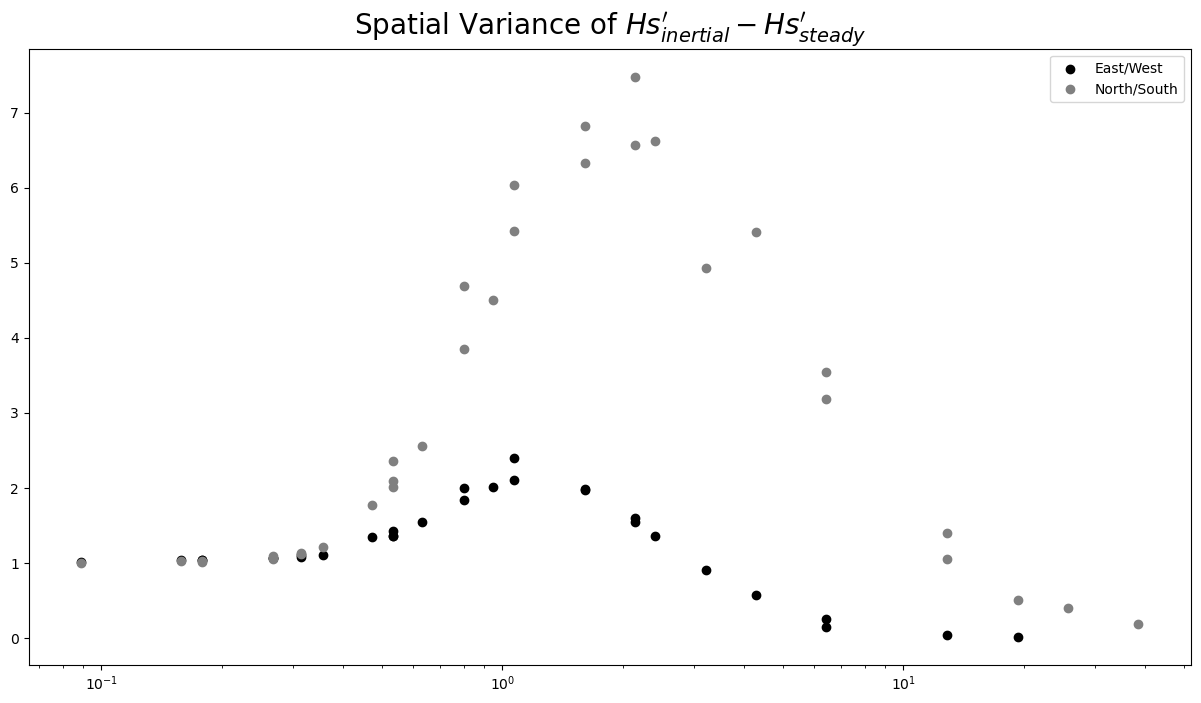

In [198]:
fig, ax = plt.subplots(1, 1, figsize=(15, 8))
#ax[0].scatter(impact_df['cgT/L']*0.19, impact_df['max_diff'], c='k')#, c=impact_df["L"])


#ax[0].set_xlabel("$c_g$/fL", fontsize=16)
# #ax[0].set_ylabel("Max($\Delta Hs_{inertial}$) / Max($\Delta Hs_{steady}$)", fontsize=16)

# x = np.linspace(0.1, 120)
# #fx = 1/(1+np.exp(-.02867*(x-1)))
# fx = 1-np.exp(-0.08*(x))-0.02
# #ax[0].plot(x, fx)
# LU = impact_df["L"]*impact_df["U"]
# cm = ax[0].scatter(impact_df["cgT/L"]*0.19, impact_df['RMSE'], c=impact_df['cg'], cmap='cmo.haline')#*(impact_df["cg"]**2)/(LU**2), c=impact_df["U"], cmap='RdBu')
# ax[0].set_ylabel("RMSE(Inertial-Steady)", fontsize=16)
# ax[0].set_xlabel("$c_g$/fL", fontsize=16)
# #plt.colorbar(cm)

# ax[1].scatter(impact_df_north["cgT/L"]*0.19, impact_df_north['RMSE'], c=impact_df_north['cg'], cmap='cmo.haline')

plt.title("Spatial Variance of $Hs_{inertial}'-Hs_{steady}'$", fontsize=20)


#ax.scatter(impact_df["cgT/L"]*0.19, impact_df['Error Variance Normalized'], c=impact_df['cg'], cmap='cmo.haline')#, cmap='cmo.haline')#*(impact_df["cg"]**2)/(LU**2), c=impact_df["U"], cmap='RdBu')
ax.scatter(impact_df["cgT/L"]*0.1588, impact_df['Error Variance Normalized'], color='black', label='East/West')#=impact_df['cg'], cmap='cmo.haline')#, cmap='cmo.haline')#*(impact_df["cg"]**2)/(LU**2), c=impact_df["U"], cmap='RdBu')

ax.scatter(impact_df_north["cgT/L"]*0.1588, impact_df_north['Error Variance Normalized'], color='gray', label="North/South")#, cmap='cmo.haline')#*(impact_df["cg"]**2)/(LU**2), c=impact_df["U"], cmap='RdBu')
ax.set_xscale('log')

ax.legend(loc='upper right')
# cgfl_list=np.linspace(0, 120)
# f = 0.2*np.exp(-cgfl_list/31)+0.02
# fx2 =4.5*(1/(x*np.sqrt(1)))*np.exp(- (np.log(x)-4)**2/(4))
#fx2 = 1*(1/((x+10)/4))
#ax[1].plot(x,  fx2)
#ax[1].plot(x,  -2*np.log(x))

#ax[0].plot(x, 1-(1/x))
#plt.ylim([0, 0.3])
#plt.xlim([0, 5])

#ax[1].vlines(x=1, ymin=0, ymax=0.25)
#ax[0].vlines(x=1, ymin=0, ymax=1)




Text(0.45, 0.98, 'Impact of $c_{g}T/L$ on Hs anomalies during westward & eastward currents')

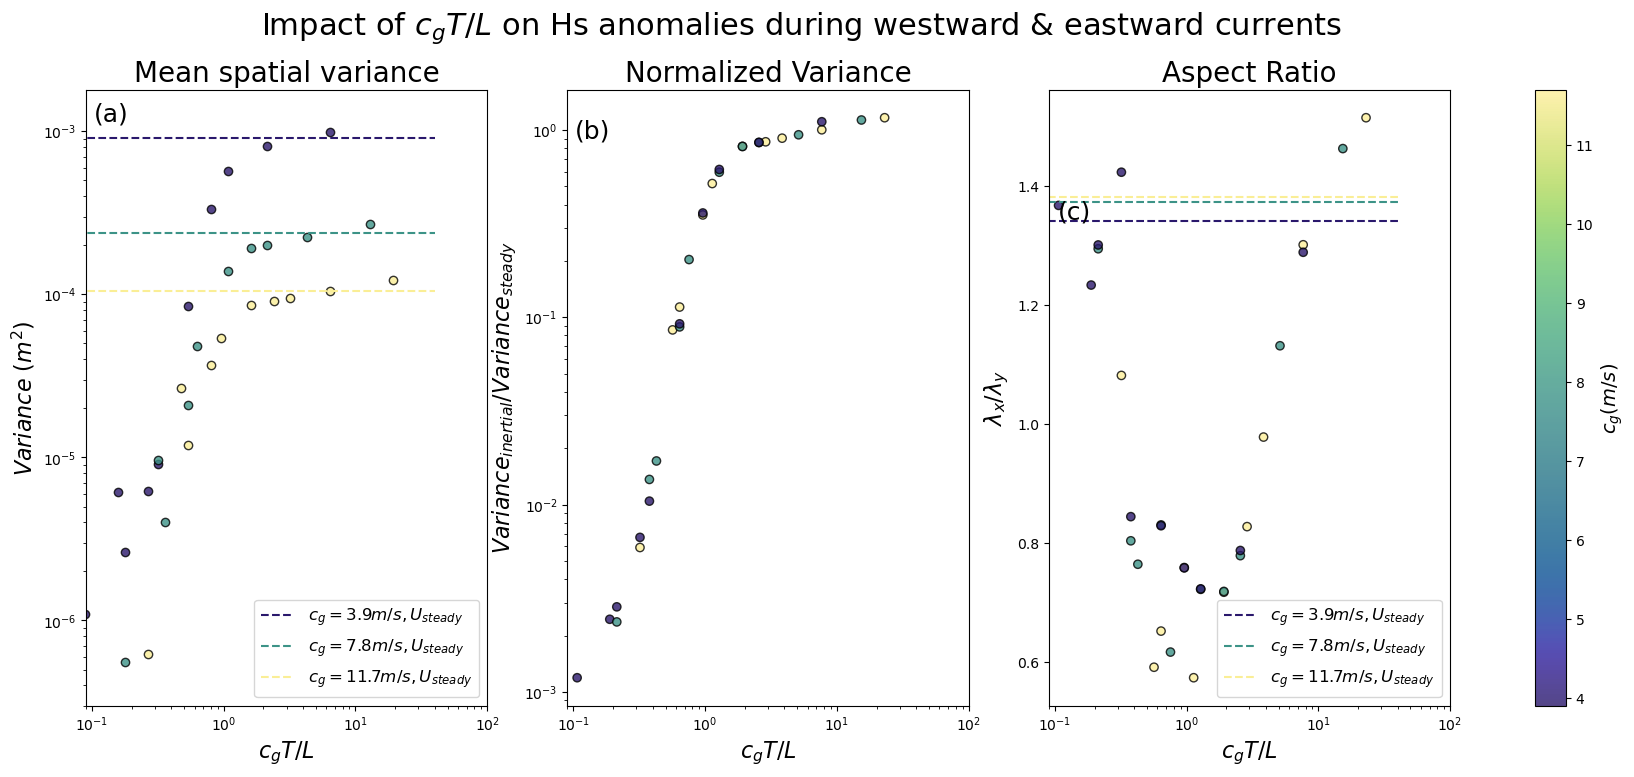

In [57]:
import cmocean
fig, ax = plt.subplots(1, 3, figsize=(22, 8))


#Get steady values

control_5 = xr.open_dataset(spath+"BC_5"+"/"+"100_288"+"/no_cur.nc")
control_10 = xr.open_dataset(spath+"BC_10"+"/"+"100_288"+"/no_cur.nc")
control_15 = xr.open_dataset(spath+"BC_15"+"/"+"100_288"+"/no_cur.nc")

steady_5 = xr.open_dataset(spath+"BC_5"+"/"+"100_steady_west/all_cur.nc")
steady_10 = xr.open_dataset(spath+"BC_10"+"/"+"100_steady_west/all_cur.nc")
steady_15 = xr.open_dataset(spath+"BC_15"+"/"+"100_steady_west/all_cur.nc")

steady_anom_5 = steady_5.hs - control_5.hs
steady_anom_10 = steady_10.hs - control_10.hs
steady_anom_15 = steady_15.hs - control_15.hs

var_steady_5 = np.nanmean(np.var(steady_anom_5[800:850, :, :], axis=(1,2)))
var_steady_10 = np.nanmean(np.var(steady_anom_10[800:850, :, :], axis=(1,2)))
var_steady_15 = np.nanmean(np.var(steady_anom_15[800:850, :, :], axis=(1,2)))

 #put in the apsect ratio calculation
dhsdy = np.gradient(steady_anom_5[-1, :, :], ykm, axis=0)
dhsdx = np.gradient(steady_anom_5[-1, :, :], xkm, axis=1)
top = np.nanmean(dhsdy[2:-2, 2:-2]**2)
bot = np.nanmean(dhsdx[2:-2, 2:-2]**2)
steady_ratio_5 = np.sqrt(top/bot)

dhsdy = np.gradient(steady_anom_10[-1, :, :], ykm, axis=0)
dhsdx = np.gradient(steady_anom_10[-1, :, :], xkm, axis=1)
top = np.nanmean(dhsdy[2:-2, 2:-2]**2)
bot = np.nanmean(dhsdx[2:-2, 2:-2]**2)
steady_ratio_10 = np.sqrt(top/bot)

dhsdy = np.gradient(steady_anom_15[-1, :, :], ykm, axis=0)
dhsdx = np.gradient(steady_anom_15[-1, :, :], xkm, axis=1)
top = np.nanmean(dhsdy[2:-2, 2:-2]**2)
bot = np.nanmean(dhsdx[2:-2, 2:-2]**2)
steady_ratio_15 = np.sqrt(top/bot)

cmap = plt.colormaps['cmo.haline']
c5 = cmap(0)
c10 = cmap(0.5)
c15 = cmap(0.99)

inds_slow = impact_df["cg"]==np.min(impact_df["cg"])
inds_mid = impact_df["cg"]==np.median(impact_df["cg"])
inds_fast = impact_df["cg"]==np.max(impact_df["cg"])


#ax[0].scatter(impact_df['cgT/L']*.190, impact_df['Variance'], c=impact_df["cg"], cmap='cmo.haline')
ax[0].scatter(impact_df['cgT/L'].values[inds_slow]*.1588, impact_df['Variance'].values[inds_slow],color=c5, alpha=0.8, edgecolors='black')
ax[0].scatter(impact_df['cgT/L'].values[inds_mid]*.1588, impact_df['Variance'].values[inds_mid], color=c10, alpha=0.8, edgecolors='black')
ax[0].scatter(impact_df['cgT/L'].values[inds_fast]*.1588, impact_df['Variance'].values[inds_fast], color=c15, alpha=0.8, edgecolors='black')


ax[0].hlines(y=var_steady_5, xmin=0, xmax=40, color=c5, linestyles='--', label='$c_g=3.9m/s, U_{steady}$')
ax[0].hlines(y=var_steady_10, xmin=0, xmax=40, color=c10, linestyles='--', label='$c_g=7.8m/s, U_{steady}$')
ax[0].hlines(y=var_steady_15, xmin=0, xmax=40, color=c15, linestyles='--', label='$c_g=11.7m/s, U_{steady}$')

ax[0].set_xlabel("$c_gT/L$", fontsize=16)
ax[0].set_ylabel("$Variance$ $(m^2)$", fontsize=16)
ax[0].legend(loc='lower right', fontsize=12)



ax[1].scatter(impact_df['cgT/L']*.19, impact_df['Normalized Variance'], c=impact_df['cg'], cmap='cmo.haline', alpha=0.8, edgecolors='black')


ax[1].set_xlabel("$c_gT/L$", fontsize=16)
ax[1].set_ylabel("$Variance_{inertial}/Variance_{steady}$", fontsize=16)
#ax[1].legend(loc='center right', fontsize=12)


cm = ax[2].scatter(impact_df["cgT/L"]*0.19, impact_df['Aspect Ratio'], c=impact_df["cg"], cmap='cmo.haline', alpha=0.8, edgecolors='black')#, c=impact_df['U'])#*(impact_df["cg"]**2)/(LU**2), c=impact_df["U"], cmap='RdBu')
ax[2].set_ylabel("$\lambda_x/\lambda_y$", fontsize=16)
ax[2].set_xlabel("$c_gT/L$", fontsize=16)
ax[2].hlines(y=steady_ratio_5, xmin=0, xmax=40, color=c5, linestyles='--', label='$c_g=3.9m/s, U_{steady}$')
ax[2].hlines(y=steady_ratio_10, xmin=0, xmax=40, color=c10, linestyles='--', label='$c_g=7.8m/s, U_{steady}$')
ax[2].hlines(y=steady_ratio_15, xmin=0, xmax=40, color=c15, linestyles='--', label='$c_g=11.7m/s, U_{steady}$')
ax[2].legend(loc='lower right', fontsize=12)



#Set limits
ax[0].set_ylim(3*10**-7, 1.8*10**-3) 
#ax[2].set_ylim(0.4, 1.4)

ax[0].set_xlim(0.09, 100)
ax[1].set_xlim(0.09, 100)
ax[2].set_xlim(0.09, 100)

#switch to log scales
ax[2].set_xscale('log')
ax[0].set_xscale('log')
ax[1].set_xscale('log')

ax[0].set_yscale('log')
ax[1].set_yscale('log')
#ax[2].set_yscale('log')

#ax[2].set_xlim(-1, 25)
#ax[0].set_xlim(-1, 25)

cbar= fig.colorbar(cm, ax=ax)
cbar.ax.set_ylabel("$c_{g} (m/s)$", fontsize=14)

fonts = 18
ax[0].annotate(text='(a)', xy=(0.14, 0.00115), fontsize=fonts, ha="center")
ax[1].annotate(text='(b)', xy=(0.14, 0.9), fontsize=fonts, ha="center")
ax[2].annotate(text='(c)', xy=(0.14, 1.345), fontsize=fonts, ha="center")


#Try plotting fx = (1/(1+e^[-x]))
x = np.linspace(0, 20, 400)
fx  = 1/(1+np.exp(-(x)))
n=3
fx = x**n/(x**n + 1)
#ax[1].plot(x, fx)

#ax[0].grid(True, which='both', linestyle='--')
#ax[1].grid(True, which='both', linestyle='--')
#ax[2].grid(True, which='both', linestyle='--')


ax[0].set_title("Mean spatial variance", fontsize=20)
ax[1].set_title("Normalized Variance", fontsize=20)
ax[2].set_title("Aspect Ratio", fontsize=20)

plt.suptitle("Impact of $c_{g}T/L$ on Hs anomalies during westward & eastward currents", fontsize=22, x=0.45, y=0.98)

#plt.savefig("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/figures/var_aspect_ratio_3panel.png", dpi = 300, bbox_inches='tight')


Text(0.45, 0.98, 'Impact of $c_{g}T/L$ on Hs anomalies during Northward & Southward currents')

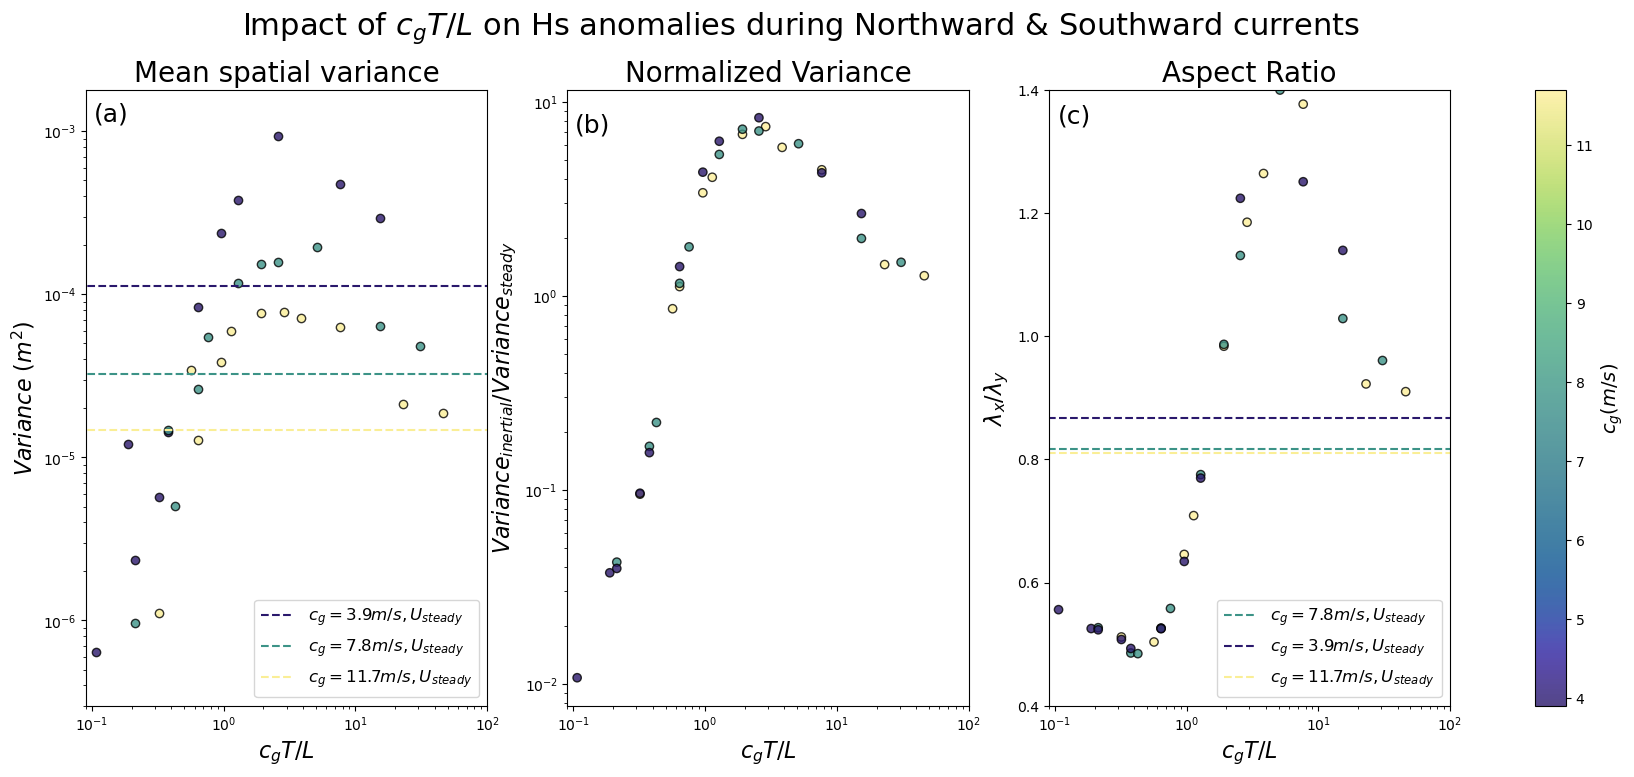

In [644]:
fig, ax = plt.subplots(1, 3, figsize=(22, 8))

control_5 = xr.open_dataset(spath+"BC_5"+"/"+"100_288"+"/no_cur.nc")
control_10 = xr.open_dataset(spath+"BC_10"+"/"+"100_288"+"/no_cur.nc")
control_15 = xr.open_dataset(spath+"BC_15"+"/"+"100_288"+"/no_cur.nc")

steady_5 = xr.open_dataset(spath+"BC_5"+"/"+"100_steady_north/all_cur.nc")
steady_10 = xr.open_dataset(spath+"BC_10"+"/"+"100_steady_north/all_cur.nc")
steady_15 = xr.open_dataset(spath+"BC_15"+"/"+"100_steady_north/all_cur.nc")

steady_anom_5 = steady_5.hs - control_5.hs
steady_anom_10 = steady_10.hs - control_10.hs
steady_anom_15 = steady_15.hs - control_15.hs

var_steady_5 = np.nanmean(np.var(steady_anom_5[800:850, :, :], axis=(1,2)))
var_steady_10 = np.nanmean(np.var(steady_anom_10[800:850, :, :], axis=(1,2)))
var_steady_15 = np.nanmean(np.var(steady_anom_15[800:850, :, :], axis=(1,2)))

 #put in the apsect ratio calculation
dhsdy = np.gradient(steady_anom_5[850, :, :], ykm, axis=0)
dhsdx = np.gradient(steady_anom_5[850, :, :], xkm, axis=1)
top = np.nanmean(dhsdy[2:-2, 2:-2]**2)
bot = np.nanmean(dhsdx[2:-2, 2:-2]**2)
steady_ratio_5 = np.sqrt(top/bot)

dhsdy = np.gradient(steady_anom_10[850, :, :], ykm, axis=0)
dhsdx = np.gradient(steady_anom_10[850, :, :], xkm, axis=1)
top = np.nanmean(dhsdy[2:-2, 2:-2]**2)
bot = np.nanmean(dhsdx[2:-2, 2:-2]**2)
steady_ratio_10 = np.sqrt(top/bot)

dhsdy = np.gradient(steady_anom_15[850, :, :], ykm, axis=0)
dhsdx = np.gradient(steady_anom_15[850, :, :], xkm, axis=1)
top = np.nanmean(dhsdy[2:-2, 2:-2]**2)
bot = np.nanmean(dhsdx[2:-2, 2:-2]**2)
steady_ratio_15 = np.sqrt(top/bot)



cmap = plt.colormaps['cmo.haline']
c5 = cmap(0)
c10 = cmap(0.5)
c15 = cmap(0.99)

inds_slow = impact_df_north["cg"]==np.min(impact_df_north["cg"])
inds_mid = impact_df_north["cg"]==np.median(impact_df_north["cg"])
inds_fast = impact_df_north["cg"]==np.max(impact_df_north["cg"])


#ax[0].scatter(impact_df['cgT/L']*.190, impact_df['Variance'], c=impact_df["cg"], cmap='cmo.haline')
ax[0].scatter(impact_df_north['cgT/L'].values[inds_slow]*.190, impact_df_north['Variance'].values[inds_slow],color=c5, alpha=0.8, edgecolors='black')
ax[0].scatter(impact_df_north['cgT/L'].values[inds_mid]*.190, impact_df_north['Variance'].values[inds_mid], color=c10, alpha=0.8, edgecolors='black')
ax[0].scatter(impact_df_north['cgT/L'].values[inds_fast]*.190, impact_df_north['Variance'].values[inds_fast], color=c15, alpha=0.8, edgecolors='black')


ax[0].hlines(y=var_steady_5, xmin=0, xmax=100, color=c5, linestyles='--', label='$c_g=3.9m/s, U_{steady}$')
ax[0].hlines(y=var_steady_10, xmin=0, xmax=100, color=c10, linestyles='--', label='$c_g=7.8m/s, U_{steady}$')
ax[0].hlines(y=var_steady_15, xmin=0, xmax=100, color=c15, linestyles='--', label='$c_g=11.7m/s, U_{steady}$')

ax[0].set_xlabel("$c_gT/L$", fontsize=16)
ax[0].set_ylabel("$Variance$ $(m^2)$", fontsize=16)
ax[0].legend(loc='lower right', fontsize=12)



ax[1].scatter(impact_df_north['cgT/L']*.190, impact_df_north['Normalized Variance'], c=impact_df_north['cg'], cmap='cmo.haline', alpha=0.8, edgecolors='black')


ax[1].set_xlabel("$c_gT/L$", fontsize=16)
ax[1].set_ylabel("$Variance_{inertial}/Variance_{steady}$", fontsize=16)
#ax[1].legend(loc='center right', fontsize=12)


cm = ax[2].scatter(impact_df_north["cgT/L"]*0.19, impact_df_north['Aspect Ratio'], c=impact_df_north["cg"], cmap='cmo.haline', alpha=0.8, edgecolors='black')#, c=impact_df['U'])#*(impact_df["cg"]**2)/(LU**2), c=impact_df["U"], cmap='RdBu')
ax[2].set_ylabel("$\lambda_x/\lambda_y$", fontsize=16)
ax[2].set_xlabel("$c_gT/L$", fontsize=16)
ax[2].hlines(y=steady_ratio_10, xmin=0, xmax=100, color=c10, linestyles='--', label='$c_g=7.8m/s, U_{steady}$')
ax[2].hlines(y=steady_ratio_5, xmin=0, xmax=100, color=c5, linestyles='--', label='$c_g=3.9m/s, U_{steady}$')
ax[2].hlines(y=steady_ratio_15, xmin=0, xmax=100, color=c15, linestyles='--', label='$c_g=11.7m/s, U_{steady}$')
ax[2].legend(loc='lower right', fontsize=12)



#Set limits
ax[0].set_ylim(3*10**-7, 1.8*10**-3) 
ax[2].set_ylim(0.4, 1.4)

ax[0].set_xlim(0.09, 100)
ax[1].set_xlim(0.09, 100)
ax[2].set_xlim(0.09, 100)

#switch to log scales
ax[2].set_xscale('log')
ax[0].set_xscale('log')
ax[1].set_xscale('log')

ax[0].set_yscale('log')
ax[1].set_yscale('log')
#ax[2].set_yscale('log')

#ax[2].set_xlim(-1, 25)
#ax[0].set_xlim(-1, 25)

cbar= fig.colorbar(cm, ax=ax)
cbar.ax.set_ylabel("$c_{g} (m/s)$", fontsize=14)

fonts = 18
ax[0].annotate(text='(a)', xy=(0.14, 0.00115), fontsize=fonts, ha="center")
ax[1].annotate(text='(b)', xy=(0.14, 7), fontsize=fonts, ha="center")
ax[2].annotate(text='(c)', xy=(0.14, 1.345), fontsize=fonts, ha="center")


#Try plotting fx = (1/(1+e^[-x]))
x = np.linspace(0, 20, 400)
fx  = 1/(1+np.exp(-(x)))
n=3
fx = x**n/(x**n + 1)
#ax[1].plot(x, fx)

#ax[0].grid(True, which='both', linestyle='--')
#ax[1].grid(True, which='both', linestyle='--')
#ax[2].grid(True, which='both', linestyle='--')


ax[0].set_title("Mean spatial variance", fontsize=20)
ax[1].set_title("Normalized Variance", fontsize=20)
ax[2].set_title("Aspect Ratio", fontsize=20)

plt.suptitle("Impact of $c_{g}T/L$ on Hs anomalies during Northward & Southward currents", fontsize=22, x=0.45, y=0.98)

#plt.savefig("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/figures/var_aspect_ratio_3panel_north.png", dpi = 300, bbox_inches='tight')


In [434]:
steady_100 = xr.open_dataset(spath+"BC_15"+"/"+"100"+"_steady_west/all_cur"+".nc")
steady_old = xr.open_dataset(spath+"BC_15"+"/"+"200"+"_steady_west_old/all_cur"+".nc")
steady_new = xr.open_dataset(spath+"BC_15"+"/"+"200"+"_steady_west/all_cur"+".nc")
control = xr.open_dataset(spath+"BC_15"+"/"+"200"+"/no_cur.nc")
i_200 = xr.open_dataset(spath+"BC_15"+"/"+"200/"+"all_cur"+".nc")
anom_old = steady_old.hs - control.hs
anom_new = steady_new.hs - control.hs
anom_100 = steady_100.hs - control.hs
anom_200_i = i_200.hs - control.hs

In [378]:
data = xr.open_dataset(spath+"BC_10"+"/"+"100_48/all_cur"+".nc")
steady = xr.open_dataset(spath+"BC_10"+"/"+"100"+"_steady_west/all_cur"+".nc")
control = xr.open_dataset(spath+"BC_10"+"/"+"100_576"+"/no_cur.nc")
anom48 = data.hs - control.hs
dhsdy_48 = np.gradient(anom[:, :, :], ykm*1000, axis=1)
dhsdx_48 = np.gradient(anom[:, :, :], xkm*1000, axis=2)
#lambday_12 = 1/np.nanmean(dhsdy[:, 2:-2, 2:-2]**2, axis=(1,2))
#lambdax_12 = 1/np.nanmean(dhsdx[:, 2:-2, 2:-2]**2, axis=(1,2))


/var/folders/77/7yfflvs902s95j6rlhb5yn9c0000gn/T/ipykernel_66791/4011450610.py:4: RuntimeWarning: divide by zero encountered in divide
  lambday_s = 1/np.nanmean(dhsdy_s[:, 2:-2, 2:-2]**2, axis=(1,2))
/var/folders/77/7yfflvs902s95j6rlhb5yn9c0000gn/T/ipykernel_66791/4011450610.py:5: RuntimeWarning: divide by zero encountered in divide
  lambdax_s = 1/np.nanmean(dhsdx_s[:, 2:-2, 2:-2]**2, axis=(1,2))


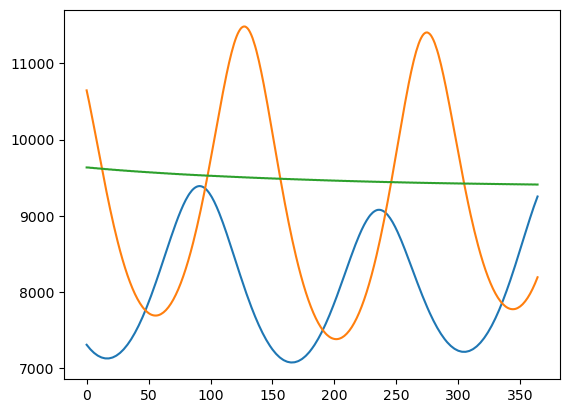

In [208]:
anom = steady.hs - control.hs
dhsdy_s = np.gradient(anom[:, :, :], ykm, axis=1)
dhsdx_s = np.gradient(anom[:, :, :], xkm, axis=2)
lambday_s = 1/np.nanmean(dhsdy_s[:, 2:-2, 2:-2]**2, axis=(1,2))
lambdax_s = 1/np.nanmean(dhsdx_s[:, 2:-2, 2:-2]**2, axis=(1,2))

#plt.plot(top[500:])
plt.plot(np.sqrt(lambdax[500:]))
plt.plot(np.sqrt(lambday[500:]))

plt.plot(np.sqrt(lambdax_s[500:]))
#plt.plot(bot_s[500:])

#plt.plot(data.ucur[500:, 40, 40]+0.7)

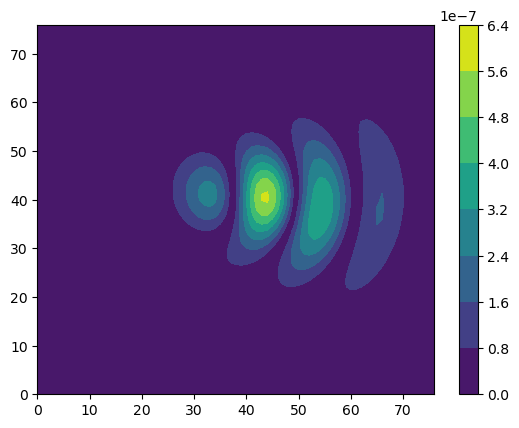

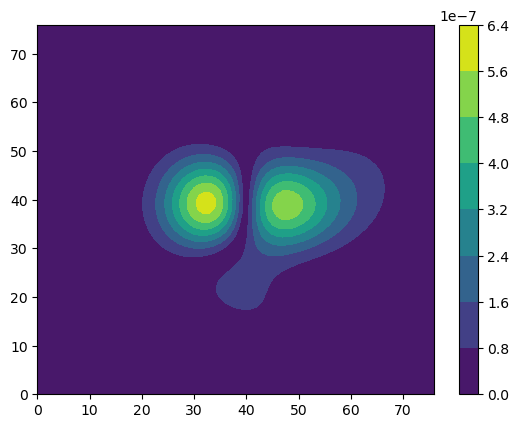

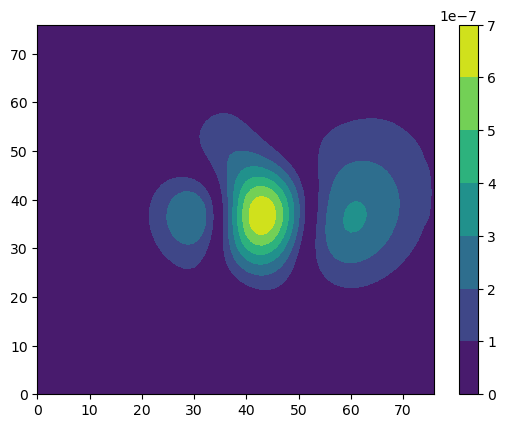

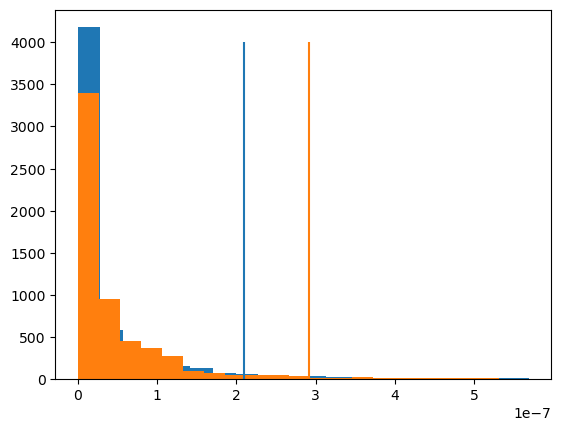

In [361]:
plt.contourf(np.sqrt(dhsdx_12[800, 2:-2, 2:-2]**2))
plt.colorbar()

plt.figure()
plt.contourf(np.sqrt(dhsdx_96[1500, 2:-2, 2:-2]**2))
plt.colorbar()

plt.figure()
plt.contourf(np.sqrt(dhsdx_48[1500, 2:-2, 2:-2]**2))
plt.colorbar()

plt.figure()
plt.hist(np.sqrt(dhsdx_12[800, 2:-2, 2:-2]**2).flatten(), bins=20)
plt.hist(np.sqrt(dhsdx_96[800, 2:-2, 2:-2]**2).flatten(), bins=20)
plt.vlines(x=np.percentile(np.sqrt(dhsdx_12[800, 2:-2, 2:-2]**2).flatten(), 95), ymin=0, ymax=4000, color='tab:blue')
plt.vlines(x=np.percentile(np.sqrt(dhsdx_96[1500, 2:-2, 2:-2]**2).flatten(), 95), ymin=0, ymax=4000, color='tab:orange')

#plt.hist(np.sqrt(dhsdy[800, 2:-2, 2:-2]**2).flatten(), bins=20)

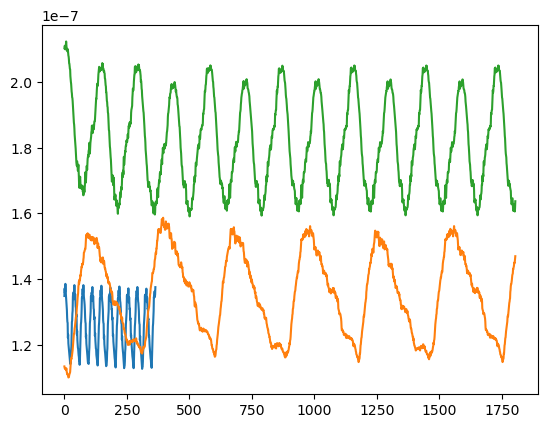

In [362]:
plt.plot(np.percentile(np.sqrt(dhsdx_12[500:, 2:-2, 2:-2]**2), 90, axis=(1,2)))
plt.plot(np.percentile(np.sqrt(dhsdx_96[500:, 2:-2, 2:-2]**2), 90, axis=(1,2)))
plt.plot(np.percentile(np.sqrt(dhsdx_48[500:, 2:-2, 2:-2]**2), 90, axis=(1,2)))


In [371]:
2* 1000*1*10**(-7)*1000*100

20.0

/var/folders/77/7yfflvs902s95j6rlhb5yn9c0000gn/T/ipykernel_66791/934790048.py:6: RuntimeWarning: divide by zero encountered in divide
  plt.loglog(1/f12, Pxx12)
/var/folders/77/7yfflvs902s95j6rlhb5yn9c0000gn/T/ipykernel_66791/934790048.py:7: RuntimeWarning: divide by zero encountered in divide
  plt.loglog(1/f96, Pxx96)
/var/folders/77/7yfflvs902s95j6rlhb5yn9c0000gn/T/ipykernel_66791/934790048.py:8: RuntimeWarning: divide by zero encountered in divide
  plt.loglog(1/f48, Pxx48)


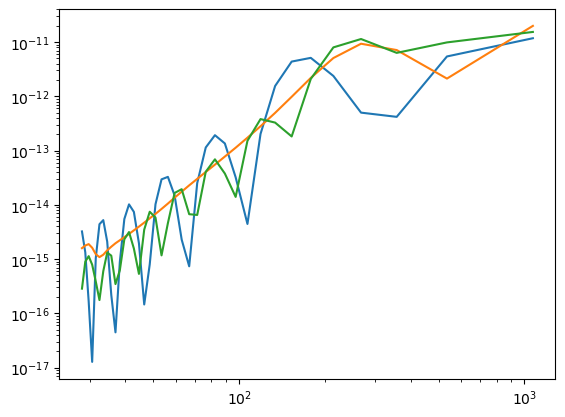

In [359]:
import scipy
f12, Pxx12 = scipy.signal.welch(np.sqrt(dhsdx_12[800, 40, 2:-2]**2), fs = 1/(xkm[2]-xkm[1]))
f96, Pxx96 = scipy.signal.welch(np.sqrt(dhsdx_96[1500, 40, 2:-2]**2), fs = 1/(xkm[2]-xkm[1]))
f48, Pxx48 = scipy.signal.welch(np.sqrt(dhsdx_48[1500, 40, 2:-2]**2), fs = 1/(xkm[2]-xkm[1]))

plt.loglog(1/f12, Pxx12)
plt.loglog(1/f96, Pxx96)
plt.loglog(1/f48, Pxx48)


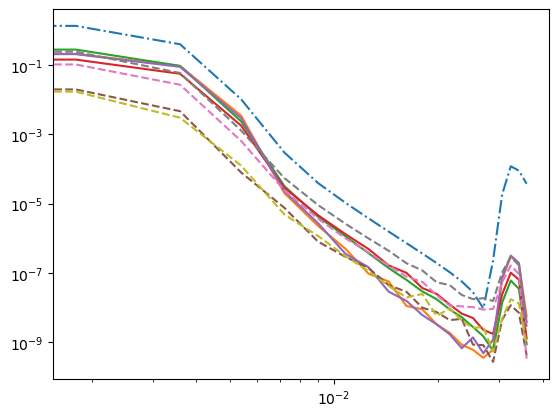

In [196]:
import scipy

#steady = xr.open_dataset(spath+"BC_10"+"/"+"100"+"_steady_west/all_cur"+".nc")
control = xr.open_dataset(spath+"BC_10"+"/"+"100_576"+"/no_cur.nc")


data12 = xr.open_dataset(spath+"BC_10"+"/"+"100_12/all_cur"+".nc")
data24 = xr.open_dataset(spath+"BC_10"+"/"+"100_24/all_cur"+".nc")
data48 = xr.open_dataset(spath+"BC_10"+"/"+"100_48/all_cur"+".nc")
data288 = xr.open_dataset(spath+"BC_10"+"/"+"100_288/all_cur"+".nc")
data576 = xr.open_dataset(spath+"BC_10"+"/"+"100_576/all_cur"+".nc")


anom12 = data12.hs - control.hs
anom24 = data24.hs - control.hs
anom48 = data48.hs - control.hs
anom288 = data288.hs - control.hs
anom576 = data576.hs - control.hs


fcur, pxxcur = scipy.signal.welch(np.sqrt(data24.ucur[2200, 40, 2:-2]**2+data24.vcur[2200, 40, 2:-2]**2), fs = 1/(xkm[2]-xkm[1]), nperseg=40)
f12, Pxx1 = scipy.signal.welch(anom24[2200, 40, 2:-2], fs = 1/(xkm[2]-xkm[1]), nperseg=40)
f12, Pxx2 = scipy.signal.welch(anom24[2224, 40, 2:-2], fs = 1/(xkm[2]-xkm[1]), nperseg=40)
f12, Pxx3 = scipy.signal.welch(anom24[2248, 40, 2:-2], fs = 1/(xkm[2]-xkm[1]), nperseg=40)
f12, Pxx4 = scipy.signal.welch(anom24[2272, 40, 2:-2], fs = 1/(xkm[2]-xkm[1]), nperseg=40)


fcur, pxxcur = scipy.signal.welch(np.sqrt(data24.ucur[2200, 40, 2:-2]**2+data24.vcur[2200, 40, 2:-2]**2), fs = 1/(xkm[2]-xkm[1]), nperseg=40)
f12, Pxx5 = scipy.signal.welch(anom576[1500, 40, 2:-2], fs = 1/(xkm[2]-xkm[1]), nperseg=40)
f12, Pxx6 = scipy.signal.welch(anom576[2000, 40, 2:-2], fs = 1/(xkm[2]-xkm[1]), nperseg=40)
f12, Pxx7 = scipy.signal.welch(anom576[2500, 40, 2:-2], fs = 1/(xkm[2]-xkm[1]), nperseg=40)
f12, Pxx8 = scipy.signal.welch(anom576[3200, 40, 2:-2], fs = 1/(xkm[2]-xkm[1]), nperseg=40)

#f24, Pxx24 = scipy.signal.welch(anom24[1500, 40, 2:-2], fs = 1/(xkm[2]-xkm[1]))
#f48, Pxx48 = scipy.signal.welch(anom48[1500, 40, 2:-2], fs = 1/(xkm[2]-xkm[1]))
#f288, Pxx288 = scipy.signal.welch(anom288[1500, 40, 2:-2], fs = 1/(xkm[2]-xkm[1]), nperseg=80)

plt.loglog(f12, pxxcur, '-.')

plt.loglog(f12, Pxx1)
plt.loglog(f12, Pxx2)
plt.loglog(f12, Pxx3)
plt.loglog(f12, Pxx4)


plt.loglog(f12, Pxx5, '--')
plt.loglog(f12, Pxx6, '--')
plt.loglog(f12, Pxx7, '--')
plt.loglog(f12, Pxx8, '--')

#plt.loglog(f24, Pxx24)
#plt.loglog(f48, Pxx48)
#plt.loglog(f288, Pxx288)


In [180]:
new_vals = np.interp(new_xs, xkm[2:-2], np.sqrt(data24.ucur[2200, 40, 2:-2]**2+data24.vcur[2200, 40, 2:-2]**2))

/var/folders/77/7yfflvs902s95j6rlhb5yn9c0000gn/T/ipykernel_40146/749404313.py:15: RuntimeWarning: divide by zero encountered in divide
  plt.plot(1/ftest, Pxxtest)
/var/folders/77/7yfflvs902s95j6rlhb5yn9c0000gn/T/ipykernel_40146/749404313.py:16: RuntimeWarning: divide by zero encountered in divide
  plt.plot(1/ftest, Pxxtest5)
/var/folders/77/7yfflvs902s95j6rlhb5yn9c0000gn/T/ipykernel_40146/749404313.py:17: RuntimeWarning: divide by zero encountered in divide
  plt.plot(1/ftest_cur, Pxxtest_cur, '--')


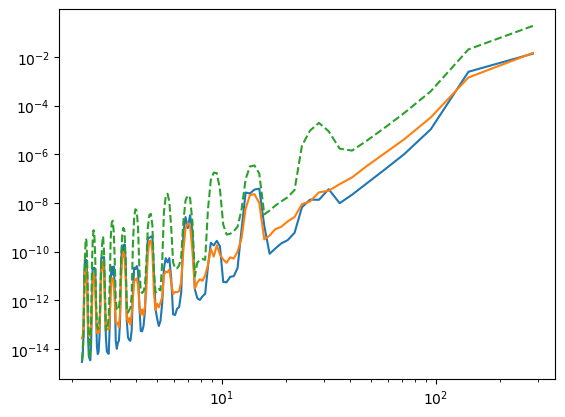

In [279]:
new_lons = np.linspace(data.longitude[0], data.longitude[-1], 1000)
out = anom12[1500, 40, :].interp(longitude=new_lons)
out2 = anom12[1524, 40, :].interp(longitude=new_lons)
out5 = anom576[2000, 40, :].interp(longitude=new_lons)

out_cur = data12.vcur[1800, 40, :].interp(longitude=new_lons)
new_xs = np.linspace(xkm[0], xkm[-1], 1000)
ftest, Pxxtest = scipy.signal.welch(out, fs = 1/(new_xs[2]-new_xs[1]), nperseg=256, noverlap=128)
ftest2, Pxxtest2 = scipy.signal.welch(out2, fs = 1/(new_xs[2]-new_xs[1]), nperseg=256, noverlap=128)
ftest3, Pxxtest3 = scipy.signal.welch(out2, fs = 1/(new_xs[2]-new_xs[1]), nperseg=256, noverlap=128)
ftest5, Pxxtest5 = scipy.signal.welch(out5, fs = 1/(new_xs[2]-new_xs[1]), nperseg=256, noverlap=128)

ftest_cur, Pxxtest_cur = scipy.signal.welch(out_cur, fs = 1/(new_xs[2]-new_xs[1]), nperseg=256, noverlap=128)

plt.plot(1/ftest, Pxxtest)
plt.plot(1/ftest, Pxxtest5)
plt.plot(1/ftest_cur, Pxxtest_cur, '--')
#plt.xlim(1, 500)
#plt.ylim(0, 0.001)
plt.yscale('log')
plt.xscale('log')

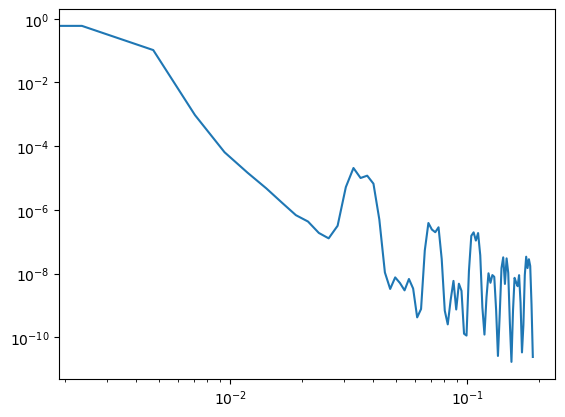

In [199]:
fxx, pxxNew = scipy.signal.welch(new_vals, fs = 1/(new_xs[2]-new_xs[1]), nperseg=160)
plt.loglog(fxx, pxxNew)

In [576]:
data = xr.open_dataset(spath+"BC_15"+"/"+"100_576/all_cur"+".nc")
steady = xr.open_dataset(spath+"BC_15"+"/"+"100"+"_steady_west/all_cur"+".nc")
control = xr.open_dataset(spath+"BC_15"+"/"+"100_576"+"/no_cur.nc")
anom = data.hs - control.hs
dhsdy = np.gradient(anom[:, :, :], ykm, axis=1)
dhsdx = np.gradient(anom[:, :, :], xkm, axis=2)
top = np.nanmean(dhsdy[:, 2:-2, 2:-2]**2, axis=(1,2))
bot = np.nanmean(dhsdx[:, 2:-2, 2:-2]**2, axis=(1,2))
ratio = np.sqrt(top/bot)

/var/folders/77/7yfflvs902s95j6rlhb5yn9c0000gn/T/ipykernel_67604/2806267965.py:9: RuntimeWarning: invalid value encountered in divide
  ratio = np.sqrt(top/bot)


In [331]:
"""
Calculate phase difference between max variance

The 100, 200 current ones are left-rotating which fucks everything up, so need to ignore them
"""

#Make Dataframe for Hs impacts
spath = "/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/"
columns = ["cgT/L","cg", "Ti", "L", "U", "Phase", "Max Var", "Min Var", "Phase Ratio", "Max Ratio", "Min Ratio", "Max Anom", "RMS Grad"]
control = xr.open_dataset(spath+"BC_10"+"/"+"100_576"+"/no_cur.nc")

phase_info_df = pd.DataFrame(columns=columns)
start_date = control.time[800] #This is not 6/6, 6/6 is 720

# #params
#folders = ["BC_15", "BC_10", "BC_5"] #Boundary Conditions (for different peak frequencies
#cur_files = ["100", "200"] #Current Widths
# #cur_files = ["100_4", "100_8", "100_12", "100_24", "100_36", "100_48", "100_96", "100_288", "100_steady_west"] #Current Widths
# runs = ["all_cur"] #Different physics parameters
# #start_ind = 800 #This should be a start date not an index
# control = xr.open_dataset(spath+bc+"/"+"100_576"+"/no_cur.nc")
# for bc in folders:
#     for cur in cur_files:
#         data = xr.open_dataset(spath+bc+"/"+cur+"/"+"all_cur"+".nc")
#         control = xr.open_dataset(spath+bc+"/"+cur+"/no_cur.nc")
#         anom = data.hs-control.hs
      

#         phase = np.arctan2(data.vcur[:, 40, 40], data.ucur[:, 40, 40])
#         phase = -1*(phase-np.pi)/np.pi
#         var = np.var(anom[:, :, :], axis=(1,2))

#         start_ind = np.where(anom.time>=start_date)[0][0]
#         #print(start_ind)

#         phase_max, max_amp = get_phase_peak(phase[start_ind:], var[start_ind:])
#         phase_max = np.nanmean(phase_max)
#         max_amp = np.nanmax(max_amp)
#         phase_max_i = np.argmax(var[start_ind:].values)
#         phase_max = phase[start_ind:][phase_max_i]
        
#         #Calcualte non-dim params
#         Tp = int(bc.split('_')[1])
#         cg = 9.8*Tp/(4*np.pi)
#         L = int(cur)*1000
#         Ti = 14.15*60*60
#         cgt_l = cg*Ti/L
#         U = np.nanmax(data.ucur.values)
        
#         #row = pd.DataFrame([[cgt_l, cg, Ti, L, U, NRMSE, RMSE, RMS, RMS_s, max_diff, max_val, var, nvar, np.nanmax(ratio[400:]), error_var, error_nvar]], columns=columns)
#         row = pd.DataFrame([[cgt_l, cg, Ti, L, U, phase_max, max_amp]], columns=columns)

#         phase_info_df = pd.concat([phase_info_df, row], ignore_index=True)

# #

folders = ["BC_15", "BC_10"] #Boundary Conditions (for different peak frequencies
#bc = "BC_10"
cur_files = ["100_4", "100_8", "100_12", "100_24", "100_36", "100_48", "100_96", "100_288", "100_576"]
for bc in folders:
    for cur in cur_files:
        data = xr.open_dataset(spath+bc+"/"+cur+"/"+"all_cur"+".nc")
        control = xr.open_dataset(spath+bc+"/"+"100_576"+"/no_cur.nc")
       
        anom = data.hs-control.hs
        var = np.var(anom[:, :, :], axis=(1,2))
       
        phase = np.arctan2(data.vcur[:, 40, 40], data.ucur[:, 40, 40])
        phase = -1*(phase-np.pi)/np.pi

        var = np.var(anom[:, :, :], axis=(1,2))

        start_ind = np.where(anom.time>=start_date)[0][0]
        #print(start_ind)

        x = np.linspace(0, 2*np.pi, 1000)
        x_unique, indicies = np.unique(phase[start_ind:], return_inverse=True)
        var_avg = np.bincount(indicies, weights=var[start_ind:]) / np.bincount(indicies)
        f= scipy.interpolate.interp1d(x_unique, var_avg, kind='slinear')
        x_new = np.linspace(x_unique.min(), x_unique.max(), 100)
        phase_max, max_amp = get_phase_peak(x_new, f(x_new))
        phase_min, min_amp = get_phase_min(x_new, f(x_new))
        min_amp = np.nanmin(min_amp)

        
        phase_max = np.nanmean(phase_max)
        max_amp = np.nanmax(max_amp)

        max_anom = np.nanmax(np.sqrt(anom[start_ind:, :, :]**2))


        
        #Do the same for aspect ratio
        dhsdy = np.gradient(anom[:, :, :], ykm, axis=1)
        dhsdx = np.gradient(anom[:, :, :], xkm, axis=2)
        top = np.nanmean(dhsdy[:, 2:-2, 2:-2]**2, axis=(1,2))
        bot = np.nanmean(dhsdx[:, 2:-2, 2:-2]**2, axis=(1,2))
        ratio = np.sqrt(top/bot)
        
        var_avg = np.bincount(indicies, weights=ratio[start_ind:]) / np.bincount(indicies)
        f= scipy.interpolate.interp1d(x_unique, var_avg, kind='slinear')
        x_new = np.linspace(x_unique.min(), x_unique.max(), 100)
        phase_max_ratio, max_ratio = get_phase_peak(x_new, f(x_new))
        phase_min_ratio, min_ratio = get_phase_min(x_new, f(x_new))
        min_ratio = np.nanmin(min_ratio)
        
        phase_max_ratio = np.nanmean(phase_max_ratio)
        max_ratio = np.nanmax(max_ratio)
        max_ratio = np.nanmax(ratio[start_ind:])
        min_ratio = np.nanmin(ratio[start_ind:])

        grad_mag = np.sqrt(np.nanmean(dhsdx[:, 2:-2, 2:-2].flatten()**2 + dhsdy[:, 2:-2, 2:-2].flatten()**2))
       # grad_mag = np.nanmax(np.sqrt(np.nanmean(dhsdx[:, 2:-2, 2:-2]**2 + dhsdy[:, 2:-2, 2:-2]**2, axis=(1,2))))

####WHICH OF THESE SHOULD I BE USING??
        #phase_max_i = np.argmax(var[start_ind:].values)
        #phase_max = phase[start_ind:][phase_max_i]
        #max_amp = phase[start_ind:][phase_max_i]
        #Calcualte non-dim params
        Tp = int(bc.split('_')[1])
        cg = 9.8*Tp/(4*np.pi)
        L = int(cur.split('_')[0])*1000
        Ti = int(cur.split('_')[1])*60*60
        cgt_l = cg*Ti/L
        U = np.nanmax(data.ucur.values)
        
        row = pd.DataFrame([[cgt_l, cg, Ti, L, U, phase_max, max_amp, min_amp, phase_max_ratio, max_ratio, min_ratio, max_anom, grad_mag]], columns=columns)

        phase_info_df = pd.concat([phase_info_df, row], ignore_index=True)

start_date = control.time[2000] #This is not 6/6, 6/6 is 720

folders = ["BC_5"] #Boundary Conditions (for different peak frequencies
#bc = "BC_10"
cur_files = ["100_4", "100_8", "100_12", "100_24", "100_36", "100_48", "100_96", "100_288"]
for bc in folders:
    for cur in cur_files:
        data = xr.open_dataset(spath+bc+"/"+cur+"/"+"all_cur"+".nc")
        control = xr.open_dataset(spath+bc+"/"+"100_576"+"/no_cur.nc")
       
        anom = data.hs-control.hs
        var = np.var(anom[:, :, :], axis=(1,2))
       
        phase = np.arctan2(data.vcur[:, 40, 40], data.ucur[:, 40, 40])
        phase = -1*(phase-np.pi)/np.pi

        var = np.var(anom[:, :, :], axis=(1,2))

        start_ind = np.where(anom.time>=start_date)[0][0]
        #print(start_ind)
        x = np.linspace(0, 2*np.pi, 1000)

        #Fit a curve to the phase relationship -- fixes problems with the fast Ti peak finding
        x_unique, indicies = np.unique(phase[start_ind:], return_inverse=True)
        var_avg = np.bincount(indicies, weights=var[start_ind:]) / np.bincount(indicies)
        f= scipy.interpolate.interp1d(x_unique, var_avg, kind='slinear')
        x_new = np.linspace(x_unique.min(), x_unique.max(), 100)
        phase_max, max_amp = get_phase_peak(x_new, f(x_new))
        phase_min, min_amp = get_phase_min(x_new, f(x_new))
        min_amp = np.nanmin(min_amp)
        
        phase_max = np.nanmean(phase_max)
        max_amp = np.nanmax(max_amp)

        max_anom = np.nanmax(np.sqrt(anom[start_ind:, :, :]**2))

        #Do the same for aspect ratio
        dhsdy = np.gradient(anom[:, :, :], ykm, axis=1)
        dhsdx = np.gradient(anom[:, :, :], xkm, axis=2)
        top = np.nanmean(dhsdy[:, 2:-2, 2:-2]**2, axis=(1,2))
        bot = np.nanmean(dhsdx[:, 2:-2, 2:-2]**2, axis=(1,2))
        ratio = np.sqrt(top/bot)
        
        var_avg = np.bincount(indicies, weights=ratio[start_ind:]) / np.bincount(indicies)
        f= scipy.interpolate.interp1d(x_unique, var_avg, kind='slinear')
        x_new = np.linspace(x_unique.min(), x_unique.max(), 100)
        phase_max_ratio, max_ratio = get_phase_peak(x_new, f(x_new))
        phase_min_ratio, min_ratio = get_phase_min(x_new, f(x_new))
        min_ratio = np.nanmin(min_ratio)


        #Some issue with this averaging between the two peaks
        phase_max_ratio = np.nanmean(phase_max_ratio)
        max_ratio = np.nanmax(max_ratio)

        max_ratio = np.nanmax(ratio[start_ind:])
        min_ratio = np.nanmin(ratio[start_ind:])

        grad_mag = np.sqrt(np.nanmean(dhsdx[:, 2:-2, 2:-2].flatten()**2 + dhsdy[:, 2:-2, 2:-2].flatten()**2))
        #grad_mag = np.nanmax(np.sqrt(np.nanmean(dhsdx[:, 2:-2, 2:-2]**2 + dhsdy[:, 2:-2, 2:-2]**2, axis=(1,2))))

####WHICH OF THESE SHOULD I BE USING??
        #phase_max_i = np.argmax(var[start_ind:].values)
        #phase_max = phase[start_ind:][phase_max_i]
        #max_amp = phase[start_ind:][phase_max_i]
        #Calcualte non-dim params
        Tp = int(bc.split('_')[1])
        cg = 9.8*Tp/(4*np.pi)
        L = int(cur.split('_')[0])*1000
        Ti = int(cur.split('_')[1])*60*60
        cgt_l = cg*Ti/L
        U = np.nanmax(data.ucur.values)
        
        row = pd.DataFrame([[cgt_l, cg, Ti, L, U, phase_max, max_amp, min_amp, phase_max_ratio, max_ratio, min_ratio, max_anom, grad_mag]], columns=columns)

        phase_info_df = pd.concat([phase_info_df, row], ignore_index=True)
# folders = ["BC_10"] #Boundary Conditions (for different peak frequencies
# # #bc = "BC_10"
# cur_files = ["100_12_05", "100_24_05", "100_36_05", "100_48_05", "100_96_05"]
# for bc in folders:
#     for cur in cur_files:
#         data = xr.open_dataset(spath+bc+"/"+cur+"/"+"all_cur"+".nc")
#         control = xr.open_dataset(spath+bc+"/"+"100_576"+"/no_cur.nc")
       
#         anom = data.hs-control.hs
#         var = np.var(anom[:, :, :], axis=(1,2))
       
#         phase = np.arctan2(data.vcur[:, 40, 40], data.ucur[:, 40, 40])
#         phase = -1*(phase-np.pi)/np.pi

#         var = np.var(anom[:, :, :], axis=(1,2))

#         start_ind = np.where(anom.time>=start_date)[0][0]
#         #print(start_ind)

#         x = np.linspace(0, 2*np.pi, 1000)
#         x_unique, indicies = np.unique(phase[start_ind:], return_inverse=True)
#         var_avg = np.bincount(indicies, weights=var[start_ind:]) / np.bincount(indicies)
#         f= scipy.interpolate.interp1d(x_unique, var_avg, kind='slinear')
#         x_new = np.linspace(x_unique.min(), x_unique.max(), 100)
#         phase_max, max_amp = get_phase_peak(x_new, f(x_new))
#         phase_min, min_amp = get_phase_min(x_new, f(x_new))
#         min_amp = np.nanmin(min_amp)

        
#         phase_max = np.nanmean(phase_max)
#         max_amp = np.nanmax(max_amp)
# ####WHICH OF THESE SHOULD I BE USING??
#         #phase_max_i = np.argmax(var[start_ind:].values)
#         #phase_max = phase[start_ind:][phase_max_i]
#         #max_amp = phase[start_ind:][phase_max_i]
#         #Calcualte non-dim params
#         Tp = int(bc.split('_')[1])
#         cg = 9.8*Tp/(4*np.pi)
#         L = int(cur.split('_')[0])*1000
#         Ti = int(cur.split('_')[1])*60*60
#         cgt_l = cg*Ti/L
#         U = np.nanmax(data.ucur.values)
        
#         row = pd.DataFrame([[cgt_l, cg, Ti, L, U, phase_max, max_amp, min_amp]], columns=columns)

#         phase_info_df = pd.concat([phase_info_df, row], ignore_index=True)

/var/folders/77/7yfflvs902s95j6rlhb5yn9c0000gn/T/ipykernel_40146/1243812965.py:98: RuntimeWarning: invalid value encountered in divide
  ratio = np.sqrt(top/bot)
/var/folders/77/7yfflvs902s95j6rlhb5yn9c0000gn/T/ipykernel_40146/1243812965.py:129: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  phase_info_df = pd.concat([phase_info_df, row], ignore_index=True)
/var/folders/77/7yfflvs902s95j6rlhb5yn9c0000gn/T/ipykernel_40146/1243812965.py:98: RuntimeWarning: invalid value encountered in divide
  ratio = np.sqrt(top/bot)
/var/folders/77/7yfflvs902s95j6rlhb5yn9c0000gn/T/ipykernel_40146/1243812965.py:98: RuntimeWarning: invalid value encountered in divide
  ratio = np.sqrt(top/bot)
/var/folders/77/7yfflvs902s95j6rlhb5yn9c0000gn/T/ipykernel_40146/12

<xarray.DataArray 'vcur' ()>
array(0.00057874)
Coordinates:
    longitude  float32 215.0
    latitude   float32 0.0


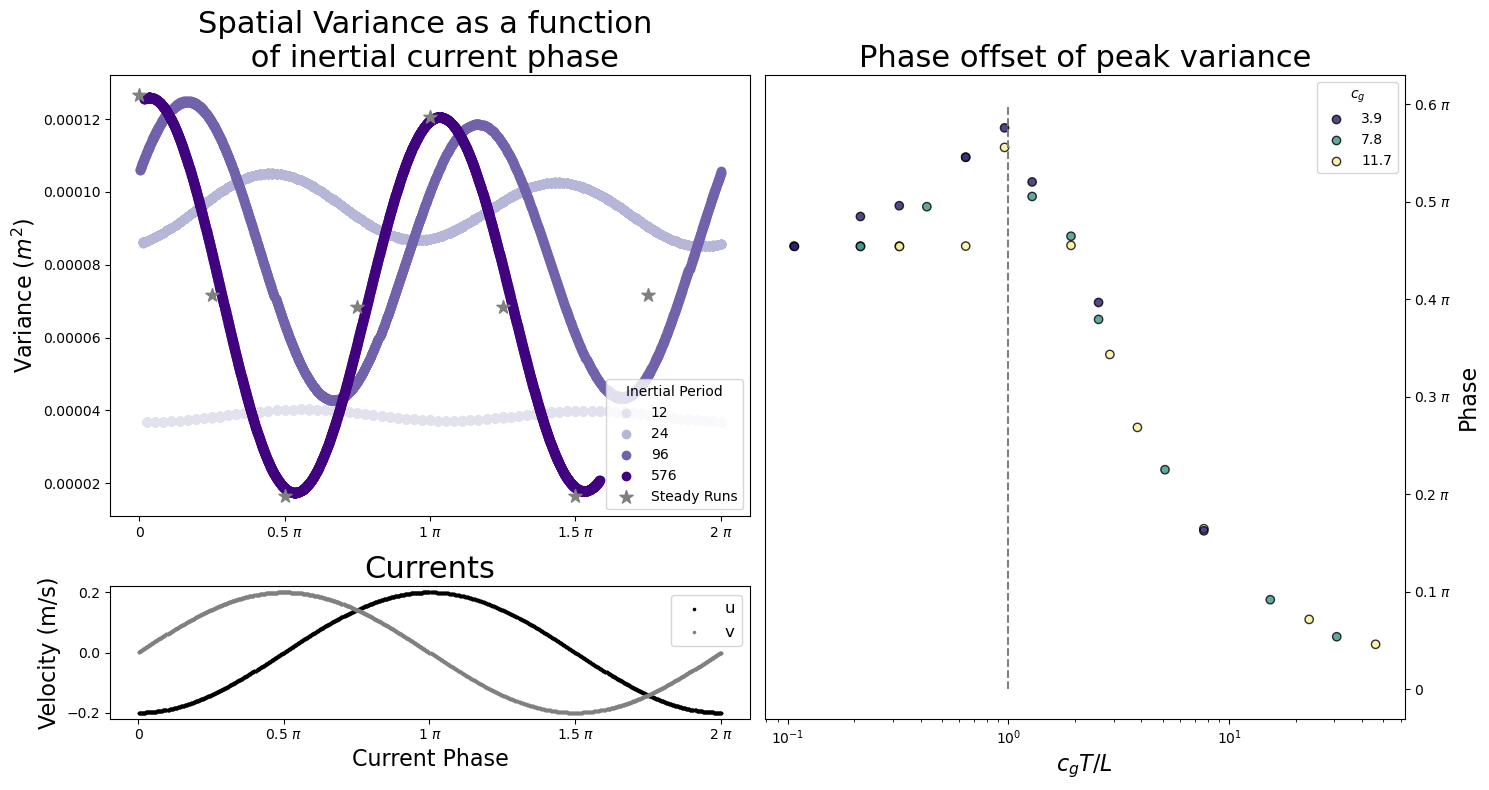

In [13]:
"""
Make a figure showing time series of variance

"""
import matplotlib.ticker as ticker

spath = "/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/"


cur_files = ["100_4", "100_8", "100_24", "100_36", "100_48", "100_96", "100_288", "100_576"]
cur_files = ["100_12", "100_24", "100_96", "100_576"]#, "100_96", "100_288"]#, "100_576"]#, "100_12", "100_24"]
#bc_list = ["BC_5", "BC_10", "BC_15"]
bc_list = ["BC_15"]
#cur_files = ["100_24", "100_36", "100_48"]

cmap = plt.colormaps['Purples']
c1 = cmap(0.2)
c2 = cmap(0.4)
c3 = cmap(0.7)
c4 = cmap(0.99)

# c1 = '#A3BCF9'
# c2 = '#C9CAD9'
# c3 = '#D1D2F9'
# c4 = '#6B4E71'
cs = np.array([c1, c2, c3, c4])
#fig, ax = plt.subplots(1,2, figsize=(15,5))
# Define the layout: 'A' spans two rows on the left
# 'B' is on top right, 'C' is a small axis below it
fig, ax = plt.subplot_mosaic(
    [['A', 'B'],
     ['C', 'B']],
    gridspec_kw={'height_ratios': [1, 0.3]},
    figsize = (15, 8)# Makes bottom row (C) small
)





start_ind = 750
for cur_i in range(len(cur_files)):
    cur = cur_files[cur_i]
    for bc in bc_list: 

        data = xr.open_dataset(spath+bc+"/"+cur+"/all_cur"+".nc")
        #steady = xr.open_dataset(spath+"BC_10"+"/"+"100"+"_steady_west/all_cur"+".nc")
        control = xr.open_dataset(spath+bc+"/"+"100_576"+"/no_cur.nc")
        phase = np.arctan2(data.vcur[start_ind:, 40, 40], data.ucur[start_ind:, 40, 40])
        anom = data.hs[start_ind:, :]-control.hs[start_ind:, :]
        var = np.var(anom, axis=(1,2))
        phase = -1*(phase-np.pi)
        max_anom = np.nanmax(np.abs(anom), axis=(1,2))
        #Do some interpolation to fix the smaller Ti's
        x = np.linspace(0, 2*np.pi, 1000)
        x_unique, indicies = np.unique(phase, return_inverse=True)
        var_avg = np.bincount(indicies, weights=var) / np.bincount(indicies)
        f= scipy.interpolate.interp1d(x_unique, var_avg, kind='slinear')
        x_new = np.linspace(x_unique.min(), x_unique.max(), 100)
        phase_max, max_amp = get_phase_peak(x_new, f(x_new))
        phase_min, min_amp = get_phase_min(x_new, f(x_new))

        avg_height = (np.nanmax(max_amp) + np.nanmin(min_amp))/2
        ax['A'].scatter(phase, var, label=cur.split("_")[1], color=cs[cur_i])
       # ax['A'].hlines(y=avg_height, xmin=0, xmax=2*np.pi, color = cs[cur_i])
        #ax['A'].scatter(np.nanmean(phase_max), np.nanmean(max_amp), marker='*')
    #plt.scatter(cur, -1*(phase_max-np.pi)/np.pi)


print(phase[-1]/np.pi-phase[-2]/np.pi)
#ax['A'].set_yscale('log')
#ax3 = ax[0].twinx()
data = xr.open_dataset(spath+bc+"/"+"100_96"+"/all_cur"+".nc")
#steady = xr.open_dataset(spath+"BC_10"+"/"+"100"+"_steady_west/all_cur"+".nc")
control = xr.open_dataset(spath+bc+"/"+"100_576"+"/no_cur.nc")
phase = np.arctan2(data.vcur[start_ind:, 40, 40], data.ucur[start_ind:, 40, 40])
phase = -1*(phase-np.pi)

ax['C'].scatter(phase, data.ucur[start_ind:, 40, 40], color='black', marker='.', s=10, label='u')
ax['C'].scatter(phase, data.vcur[start_ind:, 40, 40], color='gray', marker='.', s=10, label='v')
ax['C'].legend(fontsize=12)

control = xr.open_dataset(spath+bc+"/"+"100_576"+"/no_cur.nc")

steadyw = xr.open_dataset(spath+bc+"/"+"100"+"_steady_west/all_cur"+".nc")
steadyn = xr.open_dataset(spath+bc+"/"+"100"+"_steady_north/all_cur"+".nc")
steadye = xr.open_dataset(spath+bc+"/"+"100"+"_steady_east/all_cur"+".nc")
steadys = xr.open_dataset(spath+bc+"/"+"100"+"_steady_south/all_cur"+".nc")

steadynw = xr.open_dataset(spath+bc+"/"+"100"+"_steady_northwest/all_cur_full"+".nc")
steadyne = xr.open_dataset(spath+bc+"/"+"100"+"_steady_northeast/all_cur_full"+".nc")
steadyse = xr.open_dataset(spath+bc+"/"+"100"+"_steady_southeast/all_cur_full"+".nc")
steadysw = xr.open_dataset(spath+bc+"/"+"100"+"_steady_southwest/all_cur_full"+".nc")

varw = np.nanmean(np.nanvar(steadyw.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
varn = np.nanmean(np.nanvar(steadyn.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
vare = np.nanmean(np.nanvar(steadye.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
vars = np.nanmean(np.nanvar(steadys.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
#print(varw)
varnw = np.nanmean(np.nanvar(steadynw.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
varne = np.nanmean(np.nanvar(steadyne.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
varse = np.nanmean(np.nanvar(steadyse.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
varsw = np.nanmean(np.nanvar(steadysw.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))


ax['B'].vlines(x=1, ymin=0, ymax=0.6*np.pi, linestyle='--', color='gray')#, edgecolor='tab:orange')
ax['A'].scatter(0, varw, s=100, marker='*',  color='gray')#, edgecolor='tab:orange')
ax['A'].scatter(np.pi/2, varn, s=100, marker='*',  color='gray')#, edgecolor='tab:orange')
ax['A'].scatter(np.pi, vare, s=100, marker='*',  color='gray')#, edgecolor='tab:orange')
ax['A'].scatter(3*np.pi/2, vars, s=100, marker='*',  color='gray', label="Steady Runs")#, edgecolor='tab:orange', label="Steady Runs")

ax['A'].scatter(np.pi/4, varnw, s=100, marker='*',  color='gray')#, edgecolor='tab:orange')
ax['A'].scatter(3*np.pi/4, varne, s=100, marker='*',  color='gray')#, edgecolor='tab:orange')
ax['A'].scatter(5*np.pi/4, varse, s=100, marker='*',  color='gray')#, edgecolor='tab:orange')
ax['A'].scatter(7*np.pi/4, varsw, s=100, marker='*',  color='gray')#, edgecolor='tab:orange')

# (varw-vare)/varw
#plt.scatter(phase_max,max_amp, marker='*')
#ax['A'].set_yscale('log')
ax['A'].legend(loc='lower right', title="Inertial Period")

#get Axis in terms of 0-2pi
ax['A'].xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 2))
ax['A'].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda val, pos: '{:.2g} $\pi$'.format(val / np.pi) if val != 0 else '0'
))

ax['C'].xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 2))
ax['C'].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda val, pos: '{:.2g} $\pi$'.format(val / np.pi) if val != 0 else '0'
))


## Second panel (b)

for row_i in range(len(phase_info_df['Phase'])):
    if phase_info_df['Phase'].values[row_i] > 1:
        phase_info_df['Phase'].values[row_i] = phase_info_df['Phase'].values[row_i] - 1

ax['B'].scatter(phase_info_df['cgT/L']*0.19, phase_info_df['Phase']*np.pi, c=phase_info_df['cg'], cmap = 'cmo.haline', alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])
ax['B'].set_xscale('log')

ax['B'].yaxis.set_major_locator(ticker.MultipleLocator(np.pi / 10))
ax['B'].yaxis.set_major_formatter(ticker.FuncFormatter(
    lambda val, pos: '{:.2g} $\pi$'.format(val / np.pi) if val != 0 else '0'
))

#plt.colorbar()

#Put all the titles etc.
fs = 16
fs_title = 22
ax['A'].set_ylabel("Variance $(m^2)$", fontsize=fs)

ax['B'].set_xlabel("$c_{g}T/L$", fontsize=fs)
ax['B'].yaxis.tick_right()              # Moves ticks and tick labels to the right
ax['B'].yaxis.set_label_position("right")
ax['B'].set_ylabel('Phase', fontsize=fs)

ax['C'].set_ylabel("Velocity (m/s)", fontsize=fs)
ax['C'].set_xlabel("Current Phase", fontsize=fs)


#ax['B'].set_ylabel("Phase of first peak")
#ax['B'].set_title("Current Phase during peak variance")
#ax['B'].legend()

ax['A'].set_title('Spatial Variance as a function \n of inertial current phase', fontsize=fs_title)
ax['B'].set_title('Phase offset of peak variance', fontsize=fs_title)
ax['C'].set_title('Currents', fontsize=fs_title)


cmap = plt.colormaps['cmo.haline']
c5 = cmap(0)
c10 = cmap(0.5)
c15 = cmap(0.99)

cgi= np.where(phase_info_df['cg']<4)[0][0]
ax['B'].scatter(phase_info_df['cgT/L'][cgi]*0.19, phase_info_df['Phase'][cgi]*np.pi, color=c5, label=f"{phase_info_df['cg'][cgi]:0.1f}", alpha=0.8, edgecolors='black')

cgi= np.intersect1d(np.where(phase_info_df['cg']<10)[0], np.where(phase_info_df['cg']>4)[0])
#print(cgi)
cgi = cgi[0]
#print(phase_info_df['cg'][cgi])
ax['B'].scatter(phase_info_df['cgT/L'][cgi]*0.19, phase_info_df['Phase'][cgi]*np.pi, color=c10, label=f"{phase_info_df['cg'][cgi]:0.1f}", alpha=0.8, edgecolors='black')

cgi= np.where(phase_info_df['cg']>10)[0][0]
ax['B'].scatter(phase_info_df['cgT/L'][cgi]*0.19, phase_info_df['Phase'][cgi]*np.pi, color=c15, label=f"{phase_info_df['cg'][cgi]:0.1f}", alpha=0.8, edgecolors='black')



ax['B'].legend(title="$c_g$")


x = np.linspace(0, 2*np.pi)
a = (varw - varn)/2
#ax['A'].plot(x, a*np.cos(2*x)+varn+0.000042)

plt.tight_layout()

#plt.savefig("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/figures/variance_timeseries.png", dpi = 300, bbox_inches='tight')
plt.show()

In [164]:
#In order to get back aroudn to zero phase I need another 
tstamps = 0.5/0.00057874
print(tstamps, "timestamps")
#Which is 
print(tstamps/6/24, "days")

#So i need to run the model at least until July 1 for BC_5 cur and no_cur for 100_576

863.9458133185886 timestamps
5.999623703601309 days


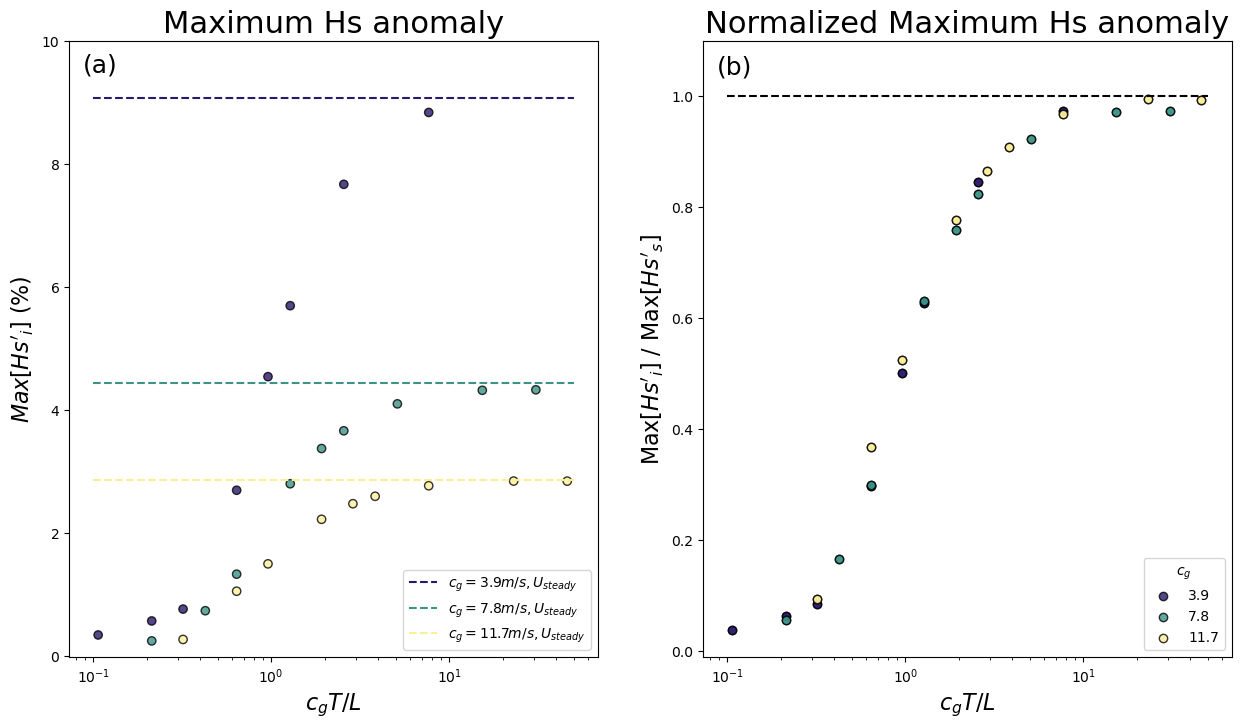

In [268]:
spath = "/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/"

fig, ax= plt.subplots(1,2, figsize=(15, 8))


steadyw5 = xr.open_dataset(spath+"BC_5"+"/"+"100"+"_steady_west/all_cur"+".nc")
steadyw10 = xr.open_dataset(spath+"BC_10"+"/"+"100"+"_steady_west/all_cur"+".nc")
steadyw15 = xr.open_dataset(spath+"BC_15"+"/"+"100"+"_steady_west/all_cur"+".nc")
control = xr.open_dataset(spath+"BC_5"+"/"+"100_576"+"/no_cur.nc")
varw5 = np.nanmean(np.nanvar(steadyw5.hs[2200:, :, :]-control.hs[2200:, :, :], axis=(1,2)))
control = xr.open_dataset(spath+"BC_10"+"/"+"100_576"+"/no_cur.nc")
varw10 = np.nanmean(np.nanvar(steadyw10.hs[800:, :, :]-control.hs[800:, :, :], axis=(1,2)))
control = xr.open_dataset(spath+"BC_15"+"/"+"100_576"+"/no_cur.nc")
varw15 = np.nanmean(np.nanvar(steadyw15.hs[800:, :, :]-control.hs[800:, :, :], axis=(1,2)))

maxanom5 = 100*np.nanmax(steadyw5.hs[2200:, :, :]-control.hs[2200:, :, :])/2.5
maxanom10 = 100*np.nanmax(steadyw10.hs[2200:, :, :]-control.hs[2200:, :, :])/2.5
maxanom15 = 100*np.nanmax(steadyw15.hs[2200:, :, :]-control.hs[2200:, :, :])/2.5


# ax[0].scatter(phase_info_df['cgT/L'].values*0.19, phase_info_df['Max Var'].values, c=phase_info_df['cg'], cmap = 'cmo.haline', alpha=0.8, edgecolors='black')
# ax[0].hlines(y=varw5, xmin=0.1, xmax=50, color=c5, linestyle='--')
# ax[0].hlines(y=varw10, xmin=0.1, xmax=50, color=c10, linestyle='--')
# ax[0].hlines(y=varw15, xmin=0.1, xmax=50, color=c15, linestyle='--')

# ax[0].set_xscale('log')

ax[0].scatter(phase_info_df['cgT/L'].values*0.19, 100*phase_info_df['Max Anom'].values/2.5, c=phase_info_df['cg'], cmap = 'cmo.haline', alpha=0.8, edgecolors='black')
ax[0].hlines(y=maxanom5, xmin=0.1, xmax=50, color=c5, linestyle='--', label='$c_g=3.9m/s, U_{steady}$')
ax[0].hlines(y=maxanom10, xmin=0.1, xmax=50, color=c10, linestyle='--', label='$c_g=7.8m/s, U_{steady}$')
ax[0].hlines(y=maxanom15, xmin=0.1, xmax=50, color=c15, linestyle='--', label='$c_g=11.7m/s, U_{steady}$')
ax[0].set_xscale('log')
ax[0].legend(loc = 'lower right')
cgi= np.where(phase_info_df['cg']<4)[0]
ax[1].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, 100*phase_info_df['Max Anom'].values[cgi]/maxanom5/2.5, color=c5, alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])
ax[1].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, 100*phase_info_df['Max Anom'].values[cgi]/maxanom5/2.5, color=c5, alpha=0.8, edgecolors='black', label=f"{phase_info_df['cg'][cgi[0]]:0.1f}")#, label=phase_info_df['cg'])

cgi= np.intersect1d(np.where(phase_info_df['cg']<10)[0], np.where(phase_info_df['cg']>4)[0])
ax[1].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, 100*phase_info_df['Max Anom'].values[cgi]/maxanom10/2.5, color=c10, alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])
ax[1].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, 100*phase_info_df['Max Anom'].values[cgi]/maxanom10/2.5, color=c10, alpha=0.8, edgecolors='black', label=f"{phase_info_df['cg'][cgi[0]]:0.1f}")#, label=phase_info_df['cg'])

control = xr.open_dataset(spath+"BC_15"+"/"+"100_576"+"/no_cur.nc")
cgi= np.where(phase_info_df['cg']>10)[0]
ax[1].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, 100*phase_info_df['Max Anom'].values[cgi]/maxanom15/2.5, color=c15, alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])
ax[1].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, 100*phase_info_df['Max Anom'].values[cgi]/maxanom15/2.5, color=c15, alpha=0.8, edgecolors='black', label=f"{phase_info_df['cg'][cgi[0]]:0.1f}")#, label=phase_info_df['cg'])

ax[1].hlines(y=1, xmin=0.1, xmax=50, color='k', linestyle='--')
ax[1].set_xscale('log')
ax[1].legend(loc='lower right', title='$c_g$')
#plt.hlines(y=varw10, xmin=0, xmax=50)
#plt.hlines(y=varw15, xmin=0, xmax=50)

#ax[0].set_title("Maximum Variance ($m^2$)")
#ax[0].set_yscale('log')
#ax[1].set_title("Normalized Variance")
#ax[0].set_ylabel("Variance ($m^2$)")
ax[0].set_title("Maximum Hs anomaly", fontsize=fs_title)
ax[0].set_ylabel("$Max[Hs'_{i}]$ (%)", fontsize=fs)

ax[1].set_title("Normalized Maximum Hs anomaly", fontsize=fs_title)
ax[1].set_ylabel("Max[$Hs'_{i}$] $/$ Max[$Hs'_{s}$]", fontsize=fs)
ax[0].set_xlabel("$c_{g}T/L$", fontsize=fs)
ax[1].set_xlabel("$c_{g}T/L$", fontsize=fs)

ax[0].set_ylim(-0.01, 10)
ax[1].set_ylim(-0.01, 1.1)
ax[0].annotate(text='(a)', xy=(0.11, 9.5), fontsize=fonts, ha="center")
ax[1].annotate(text='(b)', xy=(0.11, 1.04), fontsize=fonts, ha="center")
plt.savefig("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/figures/MaxHs.png", dpi = 300, bbox_inches='tight')


Text(0, 0.5, '$Variance_{inertial}/Variance_{steady}$')

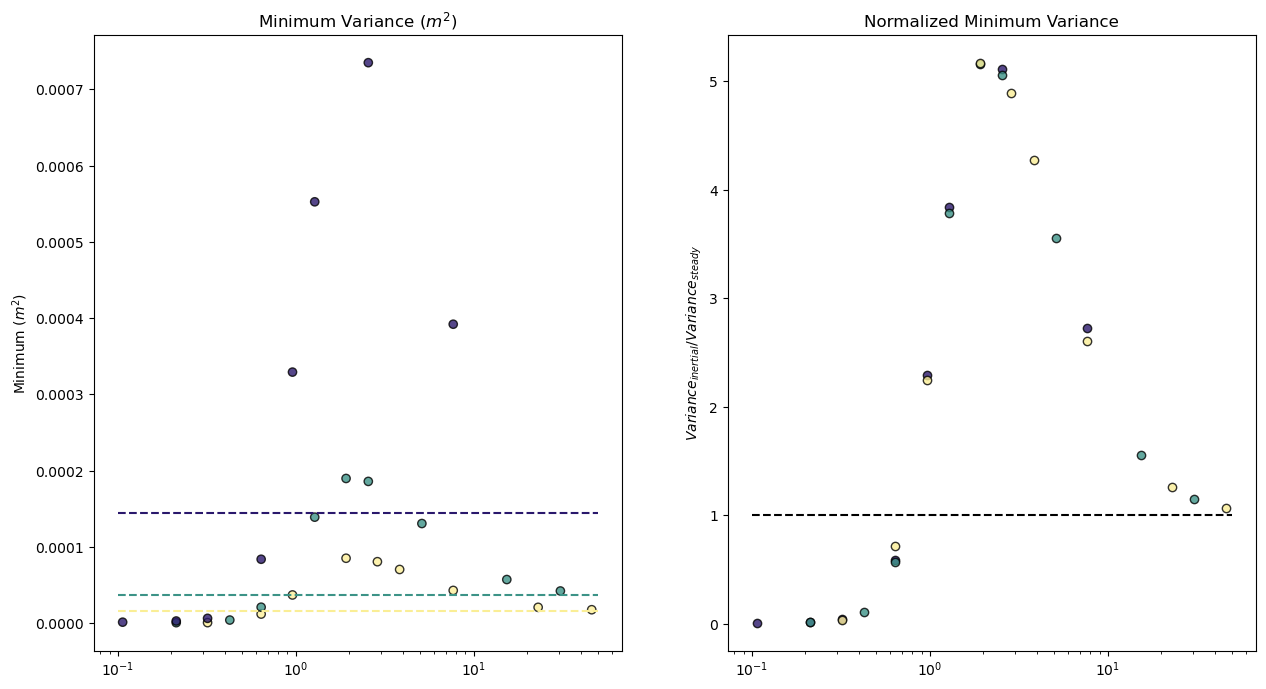

In [30]:
fig, ax= plt.subplots(1,2, figsize=(15, 8))


steadys5 = xr.open_dataset(spath+"BC_5"+"/"+"100"+"_steady_south/all_cur"+".nc")
steadys10 = xr.open_dataset(spath+"BC_10"+"/"+"100"+"_steady_south/all_cur"+".nc")
steadys15 = xr.open_dataset(spath+"BC_15"+"/"+"100"+"_steady_south/all_cur"+".nc")
control = xr.open_dataset(spath+"BC_5"+"/"+"100_576"+"/no_cur.nc")
vars5 = np.nanmean(np.nanvar(steadys5.hs[2200:, :, :]-control.hs[2200:, :, :], axis=(1,2)))
control = xr.open_dataset(spath+"BC_10"+"/"+"100_576"+"/no_cur.nc")
vars10 = np.nanmean(np.nanvar(steadys10.hs[800:, :, :]-control.hs[800:, :, :], axis=(1,2)))
control = xr.open_dataset(spath+"BC_15"+"/"+"100_576"+"/no_cur.nc")
vars15 = np.nanmean(np.nanvar(steadys15.hs[800:, :, :]-control.hs[800:, :, :], axis=(1,2)))



ax[0].scatter(phase_info_df['cgT/L'].values*0.19, phase_info_df['Min Var'].values, c=phase_info_df['cg'], cmap = 'cmo.haline', alpha=0.8, edgecolors='black')
ax[0].hlines(y=vars5, xmin=0.1, xmax=50, color=c5, linestyle='--')
ax[0].hlines(y=vars10, xmin=0.1, xmax=50, color=c10, linestyle='--')
ax[0].hlines(y=vars15, xmin=0.1, xmax=50, color=c15, linestyle='--')

ax[0].set_xscale('log')


cgi= np.where(phase_info_df['cg']<4)[0]
ax[1].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, phase_info_df['Min Var'].values[cgi]/vars5, color=c5, alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])
ax[1].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, phase_info_df['Min Var'].values[cgi]/vars5, color=c5, alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])

cgi= np.intersect1d(np.where(phase_info_df['cg']<10)[0], np.where(phase_info_df['cg']>4)[0])
ax[1].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, phase_info_df['Min Var'].values[cgi]/vars10, color=c10, alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])

control = xr.open_dataset(spath+"BC_15"+"/"+"100_576"+"/no_cur.nc")
cgi= np.where(phase_info_df['cg']>10)[0]
ax[1].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, phase_info_df['Min Var'].values[cgi]/vars15, color=c15, alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])

ax[1].hlines(y=1, xmin=0.1, xmax=50, color='k', linestyle='--')
ax[1].set_xscale('log')
#plt.hlines(y=varw10, xmin=0, xmax=50)
#plt.hlines(y=varw15, xmin=0, xmax=50)

ax[0].set_title("Minimum Variance ($m^2$)")
ax[1].set_title("Normalized Minimum Variance")
ax[0].set_ylabel("Minimum ($m^2$)")
ax[1].set_ylabel("$Variance_{inertial}/Variance_{steady}$")

In [102]:
phase_info_df['Max Anom']

0     0.006764
1     0.026363
2     0.037478
3     0.055580
4     0.061907
5     0.064931
6     0.069205
7     0.071109
8     0.071084
9     0.006179
10    0.018439
11    0.033290
12    0.070011
13    0.084324
14    0.091537
15    0.102479
16    0.107982
17    0.108200
18    0.008589
19    0.014282
20    0.019106
21    0.067376
22    0.113528
23    0.142356
24    0.191664
25    0.220857
Name: Max Anom, dtype: float32

FileNotFoundError: [Errno 2] No such file or directory: b'/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/hyak_output/outputs_100_long/outputs/BC_10/BC_5/100_steady_west/all_cur.nc'

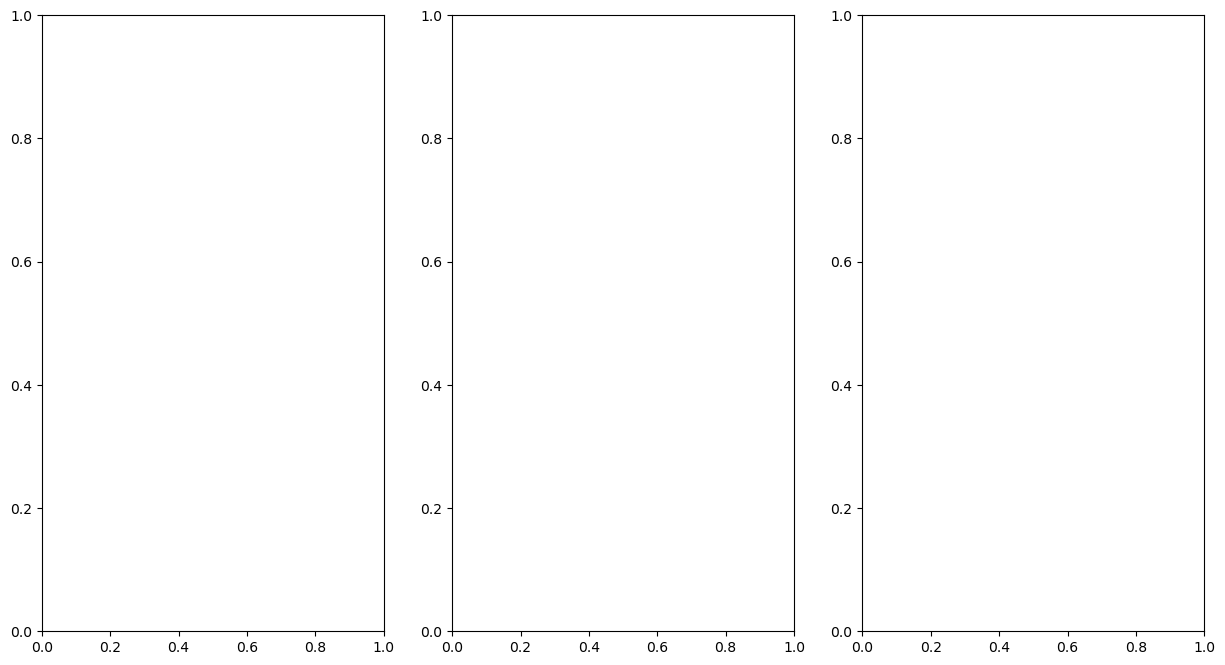

In [38]:
phase_info_df['Mean Amp'] = (phase_info_df['Max Var'].values+phase_info_df['Min Var'].values)/2

fig, ax= plt.subplots(1,3, figsize=(15, 8))


steadyw5 = xr.open_dataset(spath+"BC_5"+"/"+"100"+"_steady_west/all_cur"+".nc")
steadyw10 = xr.open_dataset(spath+"BC_10"+"/"+"100"+"_steady_west/all_cur"+".nc")
steadyw15 = xr.open_dataset(spath+"BC_15"+"/"+"100"+"_steady_west/all_cur"+".nc")

control = xr.open_dataset(spath+"BC_5"+"/"+"100_576"+"/no_cur.nc")
varw5 = np.nanmean(np.nanvar(steadyw5.hs[2200:, :, :]-control.hs[2200:, :, :], axis=(1,2)))
control = xr.open_dataset(spath+"BC_10"+"/"+"100_576"+"/no_cur.nc")
varw10 = np.nanmean(np.nanvar(steadyw10.hs[800:, :, :]-control.hs[800:, :, :], axis=(1,2)))
control = xr.open_dataset(spath+"BC_15"+"/"+"100_576"+"/no_cur.nc")
varw15 = np.nanmean(np.nanvar(steadyw15.hs[800:, :, :]-control.hs[800:, :, :], axis=(1,2)))

steadys5 = xr.open_dataset(spath+"BC_5"+"/"+"100"+"_steady_south/all_cur"+".nc")
steadys10 = xr.open_dataset(spath+"BC_10"+"/"+"100"+"_steady_south/all_cur"+".nc")
steadys15 = xr.open_dataset(spath+"BC_15"+"/"+"100"+"_steady_south/all_cur"+".nc")
control = xr.open_dataset(spath+"BC_5"+"/"+"100_576"+"/no_cur.nc")
vars5 = np.nanmean(np.nanvar(steadys5.hs[2200:, :, :]-control.hs[2200:, :, :], axis=(1,2)))
control = xr.open_dataset(spath+"BC_10"+"/"+"100_576"+"/no_cur.nc")
vars10 = np.nanmean(np.nanvar(steadys10.hs[800:, :, :]-control.hs[800:, :, :], axis=(1,2)))
control = xr.open_dataset(spath+"BC_15"+"/"+"100_576"+"/no_cur.nc")
vars15 = np.nanmean(np.nanvar(steadys15.hs[800:, :, :]-control.hs[800:, :, :], axis=(1,2)))

amp5 = (varw5 + vars5)/2
amp10 = (varw10 + vars10)/2
amp15 = (varw15 + vars15)/2


ax[0].scatter(phase_info_df['cgT/L'].values*0.19, phase_info_df['Max Var'], c=phase_info_df['cg'], cmap = 'cmo.haline', alpha=0.8, edgecolors='black')
ax[0].hlines(y=(varw5+vars5)/2, xmin=0.1, xmax=50, color=c5, linestyle='--')
ax[0].hlines(y=(varw10+vars10)/2, xmin=0.1, xmax=50, color=c10, linestyle='--')
ax[0].hlines(y=(varw15+vars15)/2, xmin=0.1, xmax=50, color=c15, linestyle='--')

ax[0].set_xscale('log')


cgi= np.where(phase_info_df['cg']<4)[0]
ax[1].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, phase_info_df['Mean Amp'].values[cgi]/amp5, color=c5, alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])

cgi= np.intersect1d(np.where(phase_info_df['cg']<10)[0], np.where(phase_info_df['cg']>4)[0])
ax[1].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, phase_info_df['Mean Amp'].values[cgi]/amp10, color=c10, alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])

control = xr.open_dataset(spath+"BC_15"+"/"+"100_576"+"/no_cur.nc")
cgi= np.where(phase_info_df['cg']>10)[0]
ax[1].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, phase_info_df['Mean Amp'].values[cgi]/amp15, color=c15, alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])

ax[1].hlines(y=1, xmin=0.1, xmax=50, color='k', linestyle='--')
ax[1].set_xscale('log')
#plt.hlines(y=varw10, xmin=0, xmax=50)
#plt.hlines(y=varw15, xmin=0, xmax=50)

ax[0].set_title("Peak Variance ($m^2$)")
ax[1].set_title("Normalized Average Variance")
ax[0].set_ylabel("Variance ($m^2$)")
ax[1].set_ylabel("$\overline{Var_{i}}/\overline{Var_{s}}$")



cgi= np.where(phase_info_df['cg']<4)[0]
ax[2].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, (phase_info_df['Max Var'].values[cgi]-phase_info_df['Mean Amp'].values[cgi])/(varw5-amp5), color=c5, alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])
#Put label
ax[2].scatter(phase_info_df['cgT/L'].values[cgi[0]]*0.19, (phase_info_df['Max Var'].values[cgi[0]]-phase_info_df['Mean Amp'].values[cgi[0]])/(varw5-amp5), color=c5, alpha=0.8, edgecolors='black', label=f"{phase_info_df['cg'][cgi[0]]:0.1f}")


cgi= np.intersect1d(np.where(phase_info_df['cg']<10)[0], np.where(phase_info_df['cg']>4)[0])
ax[2].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, (phase_info_df['Max Var'].values[cgi]-phase_info_df['Mean Amp'].values[cgi])/(varw10-amp10), color=c10, alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])
ax[2].scatter(phase_info_df['cgT/L'].values[cgi[0]]*0.19, (phase_info_df['Max Var'].values[cgi[0]]-phase_info_df['Mean Amp'].values[cgi[0]])/(varw10-amp10), color=c10, alpha=0.8, edgecolors='black', label=f"{phase_info_df['cg'][cgi[0]]:0.1f}")


control = xr.open_dataset(spath+"BC_15"+"/"+"100_576"+"/no_cur.nc")
cgi= np.where(phase_info_df['cg']>10)[0]
ax[2].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, (phase_info_df['Max Var'].values[cgi]-phase_info_df['Mean Amp'].values[cgi])/(varw15-amp15), color=c15, alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])
ax[2].scatter(phase_info_df['cgT/L'].values[cgi[0]]*0.19, (phase_info_df['Max Var'].values[cgi[0]]-phase_info_df['Mean Amp'].values[cgi[0]])/(varw15-amp15), color=c15, alpha=0.8, edgecolors='black', label=f"{phase_info_df['cg'][cgi[0]]:0.1f}")



ax[2].hlines(y=1, xmin=0.1, xmax=50, color='k', linestyle='--')
ax[2].set_xscale('log')
#plt.hlines(y=varw10, xmin=0, xmax=50)
#plt.hlines(y=varw15, xmin=0, xmax=50)

ax[2].set_title("Normalized Amplitude")
ax[2].set_ylabel(r" Max[$Var_{i}$] / Max[$Var_{s}$] ")
ax[2].legend(loc='lower right', title="$c_g$")

#ax[1].vlines(x=3, ymin=-0.01, ymax=1.5, linestyle='--', color='gray')
#ax[2].vlines(x=1, ymin=-0.01, ymax=1.1, linestyle='--', color='gray')

<xarray.DataArray 'vcur' ()>
array(0.00057874)
Coordinates:
    longitude  float32 215.0
    latitude   float32 0.0


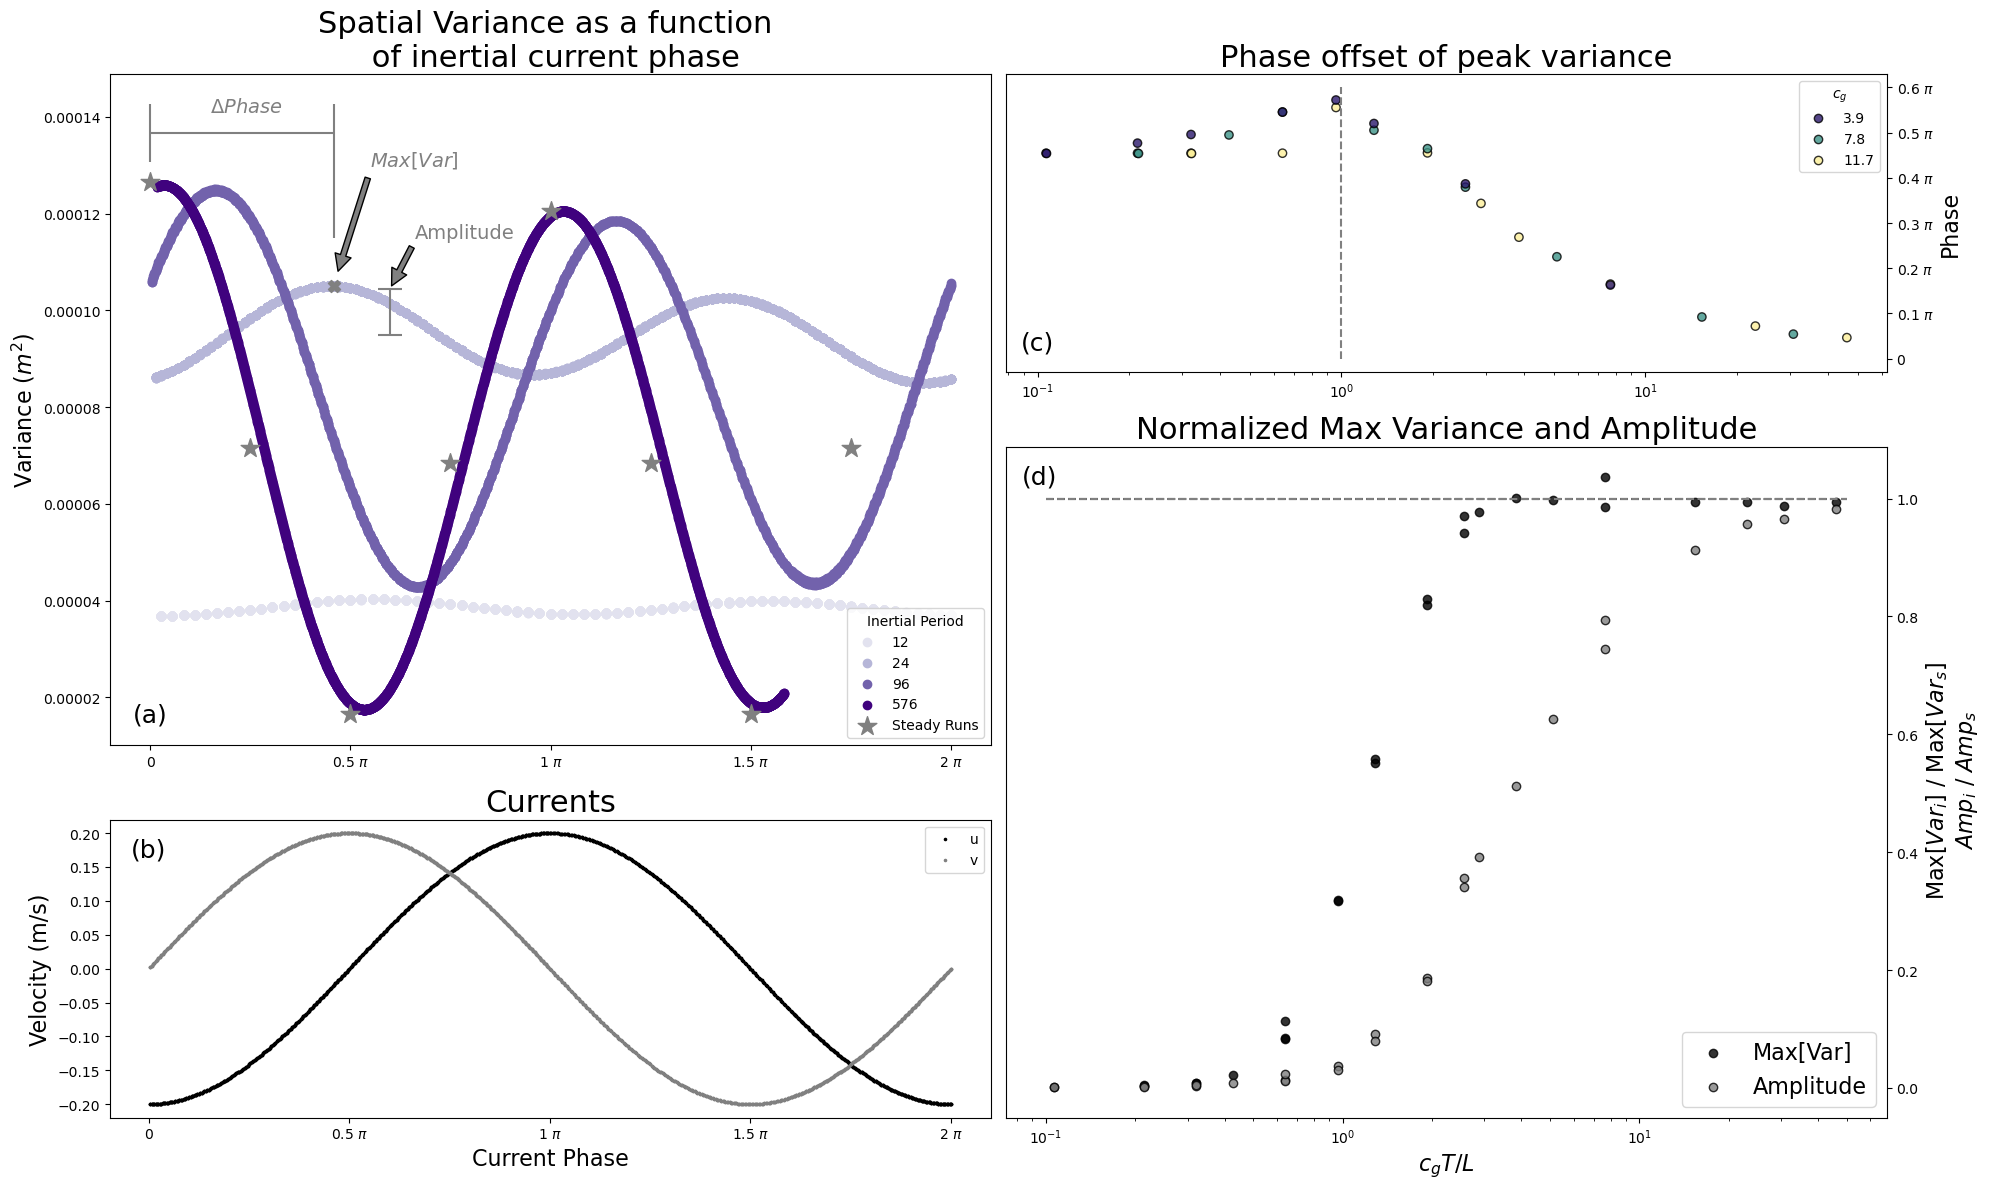

In [260]:
"""
Make a figure showing time series of variance

"""
import matplotlib.ticker as ticker

spath = "/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/"


cur_files = ["100_4", "100_8", "100_24", "100_36", "100_48", "100_96", "100_288", "100_576"]
cur_files = ["100_12", "100_24", "100_96", "100_576"]#, "100_96", "100_288"]#, "100_576"]#, "100_12", "100_24"]
#bc_list = ["BC_5", "BC_10", "BC_15"]
bc_list = ["BC_15"]
#cur_files = ["100_24", "100_36", "100_48"]

cmap = plt.colormaps['Purples']
c1 = cmap(0.2)
c2 = cmap(0.4)
c3 = cmap(0.7)
c4 = cmap(0.99)

# c1 = '#A3BCF9'
# c2 = '#C9CAD9'
# c3 = '#D1D2F9'
# c4 = '#6B4E71'
cs = np.array([c1, c2, c3, c4])
#fig, ax = plt.subplots(1,2, figsize=(15,5))
# Define the layout: 'A' spans two rows on the left
# 'B' is on top right, 'C' is a small axis below it
fig, ax = plt.subplot_mosaic(
    [['A', 'C'],
     ['A', 'D'],
     ['B', 'D']],
    gridspec_kw={'height_ratios': [1, 1, 1]},
    figsize = (20, 12)# Makes bottom row (C) small
)





start_ind = 750
for cur_i in range(len(cur_files)):
    cur = cur_files[cur_i]
    for bc in bc_list: 

        data = xr.open_dataset(spath+bc+"/"+cur+"/all_cur"+".nc")
        #steady = xr.open_dataset(spath+"BC_10"+"/"+"100"+"_steady_west/all_cur"+".nc")
        control = xr.open_dataset(spath+bc+"/"+"100_576"+"/no_cur.nc")
        phase = np.arctan2(data.vcur[start_ind:, 40, 40], data.ucur[start_ind:, 40, 40])
        anom = data.hs[start_ind:, :]-control.hs[start_ind:, :]
        var = np.var(anom, axis=(1,2))
        phase = -1*(phase-np.pi)
        max_anom = np.nanmax(np.abs(anom), axis=(1,2))
        #Do some interpolation to fix the smaller Ti's
        x = np.linspace(0, 2*np.pi, 1000)
        x_unique, indicies = np.unique(phase, return_inverse=True)
        var_avg = np.bincount(indicies, weights=var) / np.bincount(indicies)
        f= scipy.interpolate.interp1d(x_unique, var_avg, kind='slinear')
        x_new = np.linspace(x_unique.min(), x_unique.max(), 100)
        phase_max, max_amp = get_phase_peak(x_new, f(x_new))
        phase_min, min_amp = get_phase_min(x_new, f(x_new))

        avg_height = (np.nanmax(max_amp) + np.nanmin(min_amp))/2
        ax['A'].scatter(phase, var, label=cur.split("_")[1], color=cs[cur_i])
       # ax['A'].hlines(y=avg_height, xmin=0, xmax=2*np.pi, color = cs[cur_i])
        #ax['A'].scatter(np.nanmean(phase_max), np.nanmean(max_amp), marker='*')
    #plt.scatter(cur, -1*(phase_max-np.pi)/np.pi)


print(phase[-1]/np.pi-phase[-2]/np.pi)
#ax['A'].set_yscale('log')
#ax3 = ax[0].twinx()
data = xr.open_dataset(spath+bc+"/"+"100_96"+"/all_cur"+".nc")
#steady = xr.open_dataset(spath+"BC_10"+"/"+"100"+"_steady_west/all_cur"+".nc")
control = xr.open_dataset(spath+bc+"/"+"100_576"+"/no_cur.nc")
phase = np.arctan2(data.vcur[start_ind:, 40, 40], data.ucur[start_ind:, 40, 40])
phase = -1*(phase-np.pi)

ax['B'].scatter(phase, data.ucur[start_ind:, 40, 40], color='black', marker='.', s=10, label='u')
ax['B'].scatter(phase, data.vcur[start_ind:, 40, 40], color='gray', marker='.', s=10, label='v')
ax['B'].legend()

control = xr.open_dataset(spath+bc+"/"+"100_576"+"/no_cur.nc")

steadyw = xr.open_dataset(spath+bc+"/"+"100"+"_steady_west/all_cur"+".nc")
steadyn = xr.open_dataset(spath+bc+"/"+"100"+"_steady_north/all_cur"+".nc")
steadye = xr.open_dataset(spath+bc+"/"+"100"+"_steady_east/all_cur"+".nc")
steadys = xr.open_dataset(spath+bc+"/"+"100"+"_steady_south/all_cur"+".nc")

steadynw = xr.open_dataset(spath+bc+"/"+"100"+"_steady_northwest/all_cur_full"+".nc")
steadyne = xr.open_dataset(spath+bc+"/"+"100"+"_steady_northeast/all_cur_full"+".nc")
steadyse = xr.open_dataset(spath+bc+"/"+"100"+"_steady_southeast/all_cur_full"+".nc")
steadysw = xr.open_dataset(spath+bc+"/"+"100"+"_steady_southwest/all_cur_full"+".nc")

varw = np.nanmean(np.nanvar(steadyw.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
varn = np.nanmean(np.nanvar(steadyn.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
vare = np.nanmean(np.nanvar(steadye.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
varso = np.nanmean(np.nanvar(steadys.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
varnw = np.nanmean(np.nanvar(steadynw.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
varne = np.nanmean(np.nanvar(steadyne.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
varse = np.nanmean(np.nanvar(steadyse.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
varsw = np.nanmean(np.nanvar(steadysw.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))


markerSize = 200
ax['C'].vlines(x=1, ymin=0, ymax=0.6*np.pi, linestyle='--', color='gray')#, edgecolor='tab:orange')
ax['A'].scatter(0, varw, s=markerSize, marker='*',  color='gray')#, edgecolor='tab:orange')
ax['A'].scatter(np.pi/2, varn, s=markerSize, marker='*',  color='gray')#, edgecolor='tab:orange')
ax['A'].scatter(np.pi, vare, s=markerSize, marker='*',  color='gray')#, edgecolor='tab:orange')
ax['A'].scatter(3*np.pi/2, varso, s=markerSize, marker='*',  color='gray', label="Steady Runs")#, edgecolor='tab:orange', label="Steady Runs")

ax['A'].scatter(np.pi/4, varnw, s=markerSize, marker='*',  color='gray')#, edgecolor='tab:orange')
ax['A'].scatter(3*np.pi/4, varne, s=markerSize, marker='*',  color='gray')#, edgecolor='tab:orange')
ax['A'].scatter(5*np.pi/4, varse, s=markerSize, marker='*',  color='gray')#, edgecolor='tab:orange')
ax['A'].scatter(7*np.pi/4, varsw, s=markerSize, marker='*',  color='gray')#, edgecolor='tab:orange')

# (varw-vare)/varw
#plt.scatter(phase_max,max_amp, marker='*')
#ax['A'].set_yscale('log')
ax['A'].legend(loc='lower right', title="Inertial Period")

#get Axis in terms of 0-2pi
ax['A'].xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 2))
ax['A'].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda val, pos: '{:.2g} $\pi$'.format(val / np.pi) if val != 0 else '0'
))

ax['B'].xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 2))
ax['B'].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda val, pos: '{:.2g} $\pi$'.format(val / np.pi) if val != 0 else '0'
))


## Second panel (b)

for row_i in range(len(phase_info_df['Phase'])):
    if phase_info_df['Phase'].values[row_i] > 1:
        phase_info_df['Phase'].values[row_i] = phase_info_df['Phase'].values[row_i] - 1

ax['C'].scatter(phase_info_df['cgT/L']*0.19, phase_info_df['Phase']*np.pi, c=phase_info_df['cg'], cmap = 'cmo.haline', alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])
ax['C'].set_xscale('log')

ax['C'].yaxis.set_major_locator(ticker.MultipleLocator(np.pi / 10))
ax['C'].yaxis.set_major_formatter(ticker.FuncFormatter(
    lambda val, pos: '{:.2g} $\pi$'.format(val / np.pi) if val != 0 else '0'
))

#plt.colorbar()

#Put all the titles etc.
fs = 16
fs_title = 22
ax['A'].set_ylabel("Variance $(m^2)$", fontsize=fs)

#ax['C'].set_xlabel("$c_{g}T/L$", fontsize=fs)
ax['C'].yaxis.tick_right()              # Moves ticks and tick labels to the right
ax['C'].yaxis.set_label_position("right")
ax['C'].set_ylabel('Phase', fontsize=fs)

ax['B'].set_ylabel("Velocity (m/s)", fontsize=fs)
ax['B'].set_xlabel("Current Phase", fontsize=fs)


#ax['B'].set_ylabel("Phase of first peak")
#ax['B'].set_title("Current Phase during peak variance")
#ax['B'].legend()

ax['A'].set_title('Spatial Variance as a function \n of inertial current phase', fontsize=fs_title)
ax['C'].set_title('Phase offset of peak variance', fontsize=fs_title)
ax['B'].set_title('Currents', fontsize=fs_title)


cmap = plt.colormaps['cmo.haline']
c5 = cmap(0)
c10 = cmap(0.5)
c15 = cmap(0.99)

cgi= np.where(phase_info_df['cg']<4)[0][0]
ax['C'].scatter(phase_info_df['cgT/L'][cgi]*0.19, phase_info_df['Phase'][cgi]*np.pi, color=c5, label=f"{phase_info_df['cg'][cgi]:0.1f}", alpha=0.8, edgecolors='black')

cgi= np.intersect1d(np.where(phase_info_df['cg']<10)[0], np.where(phase_info_df['cg']>4)[0])
#print(cgi)
cgi = cgi[0]
#print(phase_info_df['cg'][cgi])
ax['C'].scatter(phase_info_df['cgT/L'][cgi]*0.19, phase_info_df['Phase'][cgi]*np.pi, color=c10, label=f"{phase_info_df['cg'][cgi]:0.1f}", alpha=0.8, edgecolors='black')

cgi= np.where(phase_info_df['cg']>10)[0][0]
ax['C'].scatter(phase_info_df['cgT/L'][cgi]*0.19, phase_info_df['Phase'][cgi]*np.pi, color=c15, label=f"{phase_info_df['cg'][cgi]:0.1f}", alpha=0.8, edgecolors='black')

ax['C'].legend(title="$c_g$")



"""
D & E
"""

phase_info_df['Mean Amp'] = (phase_info_df['Max Var'].values+phase_info_df['Min Var'].values)/2



steadyw5 = xr.open_dataset(spath+"BC_5"+"/"+"100"+"_steady_west/all_cur"+".nc")
steadyw10 = xr.open_dataset(spath+"BC_10"+"/"+"100"+"_steady_west/all_cur"+".nc")
steadyw15 = xr.open_dataset(spath+"BC_15"+"/"+"100"+"_steady_west/all_cur"+".nc")

control = xr.open_dataset(spath+"BC_5"+"/"+"100_576"+"/no_cur.nc")
varw5 = np.nanmean(np.nanvar(steadyw5.hs[2200:, :, :]-control.hs[2200:, :, :], axis=(1,2)))
control = xr.open_dataset(spath+"BC_10"+"/"+"100_576"+"/no_cur.nc")
varw10 = np.nanmean(np.nanvar(steadyw10.hs[800:, :, :]-control.hs[800:, :, :], axis=(1,2)))
control = xr.open_dataset(spath+"BC_15"+"/"+"100_576"+"/no_cur.nc")
varw15 = np.nanmean(np.nanvar(steadyw15.hs[800:, :, :]-control.hs[800:, :, :], axis=(1,2)))

steadys5 = xr.open_dataset(spath+"BC_5"+"/"+"100"+"_steady_south/all_cur"+".nc")
steadys10 = xr.open_dataset(spath+"BC_10"+"/"+"100"+"_steady_south/all_cur"+".nc")
steadys15 = xr.open_dataset(spath+"BC_15"+"/"+"100"+"_steady_south/all_cur"+".nc")
control = xr.open_dataset(spath+"BC_5"+"/"+"100_576"+"/no_cur.nc")
vars5 = np.nanmean(np.nanvar(steadys5.hs[2200:, :, :]-control.hs[2200:, :, :], axis=(1,2)))
control = xr.open_dataset(spath+"BC_10"+"/"+"100_576"+"/no_cur.nc")
vars10 = np.nanmean(np.nanvar(steadys10.hs[800:, :, :]-control.hs[800:, :, :], axis=(1,2)))
control = xr.open_dataset(spath+"BC_15"+"/"+"100_576"+"/no_cur.nc")
vars15 = np.nanmean(np.nanvar(steadys15.hs[800:, :, :]-control.hs[800:, :, :], axis=(1,2)))

amp5 = (varw5 + vars5)/2
amp10 = (varw10 + vars10)/2
amp15 = (varw15 + vars15)/2





cgi= np.where(phase_info_df['cg']<4)[0]
ax['D'].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, phase_info_df['Max Var'].values[cgi]/varw5, color='black', alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])

cgi= np.intersect1d(np.where(phase_info_df['cg']<10)[0], np.where(phase_info_df['cg']>4)[0])
ax['D'].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, phase_info_df['Max Var'].values[cgi]/varw10, color='black', alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])

control = xr.open_dataset(spath+"BC_15"+"/"+"100_576"+"/no_cur.nc")
cgi= np.where(phase_info_df['cg']>10)[0]
ax['D'].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, phase_info_df['Max Var'].values[cgi]/varw15, color='black', alpha=0.8, edgecolors='black', label='Max[Var]')#, label=phase_info_df['cg'])

ax['D'].hlines(y=1, xmin=0.1, xmax=50, color='k', linestyle='--')
ax['D'].set_xscale('log')
#plt.hlines(y=varw10, xmin=0, xmax=50)
#plt.hlines(y=varw15, xmin=0, xmax=50)

ax['D'].set_title("Normalized Max Variance and Amplitude", fontsize= fs_title)
ax['D'].set_ylabel(" Max[$Var_{i}$] / Max[$Var_{s}$] \n $Amp_{i}$ / $Amp_{s}$", fontsize=fs)



cgi= np.where(phase_info_df['cg']<4)[0]
ax['D'].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, (phase_info_df['Max Var'].values[cgi]-phase_info_df['Mean Amp'].values[cgi])/(varw5-amp5), color='gray', alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])
#Put label
#ax['D'].scatter(phase_info_df['cgT/L'].values[cgi[0]]*0.19, (phase_info_df['Max Var'].values[cgi[0]]-phase_info_df['Mean Amp'].values[cgi[0]])/(varw5-amp5), color='gray', alpha=0.8, edgecolors='black', label=f"{phase_info_df['cg'][cgi[0]]:0.1f}")


cgi= np.intersect1d(np.where(phase_info_df['cg']<10)[0], np.where(phase_info_df['cg']>4)[0])
ax['D'].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, (phase_info_df['Max Var'].values[cgi]-phase_info_df['Mean Amp'].values[cgi])/(varw10-amp10), color='gray', alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])
#ax['D'].scatter(phase_info_df['cgT/L'].values[cgi[0]]*0.19, (phase_info_df['Max Var'].values[cgi[0]]-phase_info_df['Mean Amp'].values[cgi[0]])/(varw10-amp10), color='gray', alpha=0.8, edgecolors='black', label=f"{phase_info_df['cg'][cgi[0]]:0.1f}")


control = xr.open_dataset(spath+"BC_15"+"/"+"100_576"+"/no_cur.nc")
cgi= np.where(phase_info_df['cg']>10)[0]
ax['D'].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, (phase_info_df['Max Var'].values[cgi]-phase_info_df['Mean Amp'].values[cgi])/(varw15-amp15), color='gray', alpha=0.8, edgecolors='black', label='Amplitude')
#ax['D'].scatter(phase_info_df['cgT/L'].values[cgi[0]]*0.19, (phase_info_df['Max Var'].values[cgi[0]]-phase_info_df['Mean Amp'].values[cgi[0]])/(varw15-amp15), color='gray', alpha=0.8, edgecolors='black', label=f"{phase_info_df['cg'][cgi[0]]:0.1f}")



ax['D'].hlines(y=1, xmin=0.1, xmax=50, color='gray', linestyle='--')
ax['D'].set_xscale('log')
#plt.hlines(y=varw10, xmin=0, xmax=50)
#plt.hlines(y=varw15, xmin=0, xmax=50)

#ax['E'].set_title("Normalized Amplitude", fontsize = fs_title)
#ax['E'].set_ylabel("$Amp_{i}/Amp_{s}$", fontsize=fs)

#ax['E'].legend(loc='lower right', title="$c_g$")

ax['D'].yaxis.tick_right()              # Moves ticks and tick labels to the right
ax['D'].yaxis.set_label_position("right")
ax['D'].legend(loc = 'lower right', fontsize=fs)
#ax['E'].yaxis.tick_right()              # Moves ticks and tick labels to the right
#ax['E'].yaxis.set_label_position("right")

ax['D'].set_xlabel("$c_{g}T/L$", fontsize=fs)
"""
Put in labels for variacles
"""

ax['A'].hlines(y=varw+0.00001, xmin=0.001*np.pi, xmax=0.46*np.pi, color='gray')

ax['A'].vlines(x=0, ymin=varw+0.000004, ymax=varw+0.000016, color='gray')

ax['A'].vlines(x=0.46*np.pi, ymin=0.000115, ymax=varw+0.000016, color='gray')

ax['A'].annotate('$\Delta Phase$', (0.15*np.pi, 0.000141), fontsize=14, color='gray')


ax['A'].scatter(0.46*np.pi, 0.000105, s=75, marker='X', color='gray')
ax['A'].annotate('$Max[Var]$', (0.465*np.pi, 0.000107), xytext=(0.55*np.pi, 0.00013), arrowprops=dict(facecolor='gray', shrink=0.05), fontsize=14, color='gray')

ax['A'].vlines(x=0.6*np.pi, ymin=0.000095, ymax=0.0001045, color='gray')
ax['A'].hlines(y=0.0001045, xmin=0.57*np.pi, xmax=0.63*np.pi, color='gray')
ax['A'].hlines(y=0.000095, xmin=0.57*np.pi, xmax=0.63*np.pi, color='gray')

ax['A'].annotate('Amplitude', (0.6*np.pi, 0.0001046), xytext=(0.66*np.pi, 0.000115), arrowprops=dict(facecolor='gray', shrink=0.05), fontsize=14, color='gray')

"""
add a - e subplot labels
"""

fonts = 18
ax['A'].annotate(text='(a)', xy=(0, 0.000015), fontsize=fonts, ha="center")
ax['B'].annotate(text='(b)', xy=(0, 0.165), fontsize=fonts, ha="center")
ax['C'].annotate(text='(c)', xy=(0.1, 0.02*np.pi), fontsize=fonts, ha="center")
ax['D'].annotate(text='(d)', xy=(0.095, 1.025), fontsize=fonts, ha="center")

#ax['D'].annotate(text='(b)', xy=(0.14, 7), fontsize=fonts, ha="center")
#ax['D'].annotate(text='(b)', xy=(0.14, 7), fontsize=fonts, ha="center")


plt.tight_layout()

plt.savefig("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/figures/variance_timeseries_5panel.png", dpi = 300, bbox_inches='tight')
plt.show()

<xarray.DataArray 'vcur' ()>
array(0.00057874)
Coordinates:
    longitude  float32 215.0
    latitude   float32 0.0


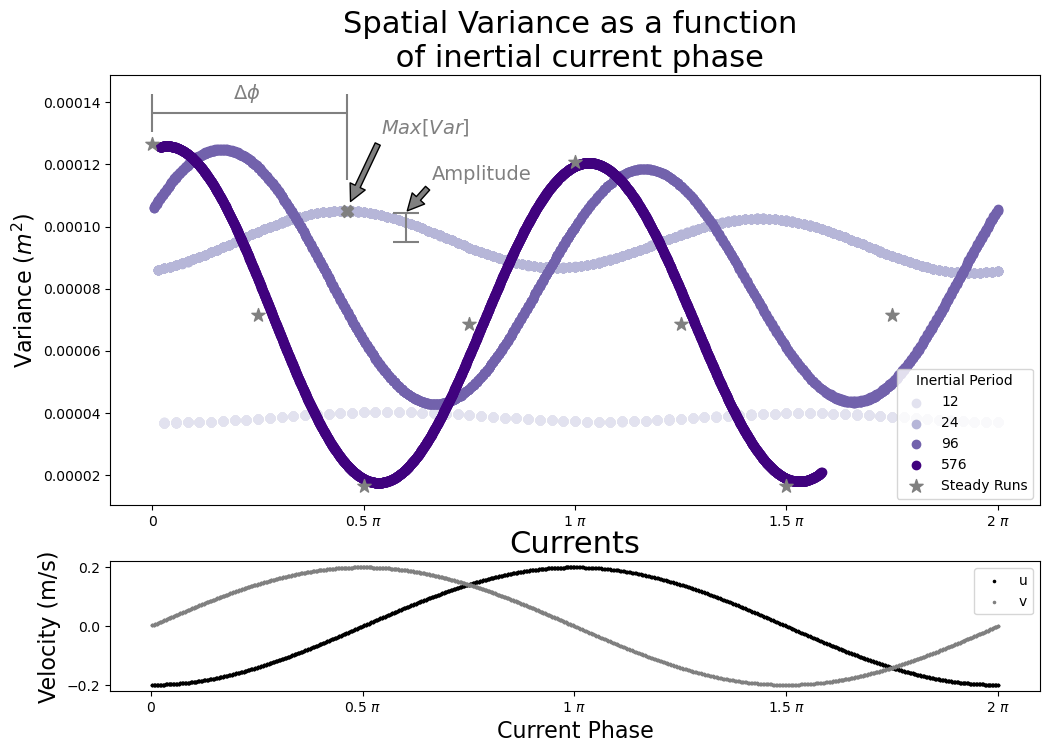

In [118]:
"""
Make a figure showing time series of variance

"""
import matplotlib.ticker as ticker

spath = "/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/"


cur_files = ["100_4", "100_8", "100_24", "100_36", "100_48", "100_96", "100_288", "100_576"]
cur_files = ["100_12", "100_24", "100_96", "100_576"]#, "100_96", "100_288"]#, "100_576"]#, "100_12", "100_24"]
#bc_list = ["BC_5", "BC_10", "BC_15"]
bc_list = ["BC_15"]
#cur_files = ["100_24", "100_36", "100_48"]

cmap = plt.colormaps['Purples']
c1 = cmap(0.2)
c2 = cmap(0.4)
c3 = cmap(0.7)
c4 = cmap(0.99)

# c1 = '#A3BCF9'
# c2 = '#C9CAD9'
# c3 = '#D1D2F9'
# c4 = '#6B4E71'
cs = np.array([c1, c2, c3, c4])
#fig, ax = plt.subplots(1,2, figsize=(15,5))
# Define the layout: 'A' spans two rows on the left
# 'B' is on top right, 'C' is a small axis below it
fig, ax = plt.subplot_mosaic(
    [['A', 'A'],
     ['B', 'B']],
    gridspec_kw={'height_ratios': [1, 0.3]},
    figsize = (12, 8)# Makes bottom row (C) small
)





start_ind = 750
for cur_i in range(len(cur_files)):
    cur = cur_files[cur_i]
    for bc in bc_list: 

        data = xr.open_dataset(spath+bc+"/"+cur+"/all_cur"+".nc")
        #steady = xr.open_dataset(spath+"BC_10"+"/"+"100"+"_steady_west/all_cur"+".nc")
        control = xr.open_dataset(spath+bc+"/"+"100_576"+"/no_cur.nc")
        phase = np.arctan2(data.vcur[start_ind:, 40, 40], data.ucur[start_ind:, 40, 40])
        anom = data.hs[start_ind:, :]-control.hs[start_ind:, :]
        var = np.var(anom, axis=(1,2))
        phase = -1*(phase-np.pi)
        max_anom = np.nanmax(np.abs(anom), axis=(1,2))
        #Do some interpolation to fix the smaller Ti's
        x = np.linspace(0, 2*np.pi, 1000)
        x_unique, indicies = np.unique(phase, return_inverse=True)
        var_avg = np.bincount(indicies, weights=var) / np.bincount(indicies)
        f= scipy.interpolate.interp1d(x_unique, var_avg, kind='slinear')
        x_new = np.linspace(x_unique.min(), x_unique.max(), 100)
        phase_max, max_amp = get_phase_peak(x_new, f(x_new))
        phase_min, min_amp = get_phase_min(x_new, f(x_new))

        avg_height = (np.nanmax(max_amp) + np.nanmin(min_amp))/2
        ax['A'].scatter(phase, var, label=cur.split("_")[1], color=cs[cur_i])
       # ax['A'].hlines(y=avg_height, xmin=0, xmax=2*np.pi, color = cs[cur_i])
        #ax['A'].scatter(np.nanmean(phase_max), np.nanmean(max_amp), marker='*')
    #plt.scatter(cur, -1*(phase_max-np.pi)/np.pi)


print(phase[-1]/np.pi-phase[-2]/np.pi)
#ax['A'].set_yscale('log')
#ax3 = ax[0].twinx()
data = xr.open_dataset(spath+bc+"/"+"100_96"+"/all_cur"+".nc")
#steady = xr.open_dataset(spath+"BC_10"+"/"+"100"+"_steady_west/all_cur"+".nc")
control = xr.open_dataset(spath+bc+"/"+"100_576"+"/no_cur.nc")
phase = np.arctan2(data.vcur[start_ind:, 40, 40], data.ucur[start_ind:, 40, 40])
phase = -1*(phase-np.pi)

ax['B'].scatter(phase, data.ucur[start_ind:, 40, 40], color='black', marker='.', s=10, label='u')
ax['B'].scatter(phase, data.vcur[start_ind:, 40, 40], color='gray', marker='.', s=10, label='v')
ax['B'].legend()

control = xr.open_dataset(spath+bc+"/"+"100_576"+"/no_cur.nc")

steadyw = xr.open_dataset(spath+bc+"/"+"100"+"_steady_west/all_cur"+".nc")
steadyn = xr.open_dataset(spath+bc+"/"+"100"+"_steady_north/all_cur"+".nc")
steadye = xr.open_dataset(spath+bc+"/"+"100"+"_steady_east/all_cur"+".nc")
steadys = xr.open_dataset(spath+bc+"/"+"100"+"_steady_south/all_cur"+".nc")

steadynw = xr.open_dataset(spath+bc+"/"+"100"+"_steady_northwest/all_cur_full"+".nc")
steadyne = xr.open_dataset(spath+bc+"/"+"100"+"_steady_northeast/all_cur_full"+".nc")
steadyse = xr.open_dataset(spath+bc+"/"+"100"+"_steady_southeast/all_cur_full"+".nc")
steadysw = xr.open_dataset(spath+bc+"/"+"100"+"_steady_southwest/all_cur_full"+".nc")

varw = np.nanmean(np.nanvar(steadyw.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
varn = np.nanmean(np.nanvar(steadyn.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
vare = np.nanmean(np.nanvar(steadye.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
varso = np.nanmean(np.nanvar(steadys.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
varnw = np.nanmean(np.nanvar(steadynw.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
varne = np.nanmean(np.nanvar(steadyne.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
varse = np.nanmean(np.nanvar(steadyse.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
varsw = np.nanmean(np.nanvar(steadysw.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))


ax['A'].scatter(0, varw, s=100, marker='*',  color='gray')#, edgecolor='tab:orange')
ax['A'].scatter(np.pi/2, varn, s=100, marker='*',  color='gray')#, edgecolor='tab:orange')
ax['A'].scatter(np.pi, vare, s=100, marker='*',  color='gray')#, edgecolor='tab:orange')
ax['A'].scatter(3*np.pi/2, varso, s=100, marker='*',  color='gray', label="Steady Runs")#, edgecolor='tab:orange', label="Steady Runs")

ax['A'].scatter(np.pi/4, varnw, s=100, marker='*',  color='gray')#, edgecolor='tab:orange')
ax['A'].scatter(3*np.pi/4, varne, s=100, marker='*',  color='gray')#, edgecolor='tab:orange')
ax['A'].scatter(5*np.pi/4, varse, s=100, marker='*',  color='gray')#, edgecolor='tab:orange')
ax['A'].scatter(7*np.pi/4, varsw, s=100, marker='*',  color='gray')#, edgecolor='tab:orange')

# (varw-vare)/varw
#plt.scatter(phase_max,max_amp, marker='*')
#ax['A'].set_yscale('log')
ax['A'].legend(loc='lower right', title="Inertial Period")

#get Axis in terms of 0-2pi
ax['A'].xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 2))
ax['A'].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda val, pos: '{:.2g} $\pi$'.format(val / np.pi) if val != 0 else '0'
))

ax['B'].xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 2))
ax['B'].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda val, pos: '{:.2g} $\pi$'.format(val / np.pi) if val != 0 else '0'
))


## Second panel (b)

#plt.colorbar()

#Put all the titles etc.
fs = 16
fs_title = 22
ax['A'].set_ylabel("Variance $(m^2)$", fontsize=fs)


ax['B'].set_ylabel("Velocity (m/s)", fontsize=fs)
ax['B'].set_xlabel("Current Phase", fontsize=fs)


#ax['B'].set_ylabel("Phase of first peak")
#ax['B'].set_title("Current Phase during peak variance")
#ax['B'].legend()

ax['A'].set_title('Spatial Variance as a function \n of inertial current phase', fontsize=fs_title)
ax['B'].set_title('Currents', fontsize=fs_title)

"""
Put in labels for variacles
"""

ax['A'].hlines(y=varw+0.00001, xmin=0.001*np.pi, xmax=0.46*np.pi, color='gray')

ax['A'].vlines(x=0, ymin=varw+0.000004, ymax=varw+0.000016, color='gray')

ax['A'].vlines(x=0.46*np.pi, ymin=0.000115, ymax=varw+0.000016, color='gray')

ax['A'].annotate('$\Delta \phi$', (0.19*np.pi, 0.000141), fontsize=14, color='gray')


ax['A'].scatter(0.46*np.pi, 0.000105, s=75, marker='X', color='gray')
ax['A'].annotate('$Max[Var]$', (0.465*np.pi, 0.000107), xytext=(0.54*np.pi, 0.00013), arrowprops=dict(facecolor='gray', shrink=0.05), fontsize=14, color='gray')

ax['A'].vlines(x=0.6*np.pi, ymin=0.000095, ymax=0.0001045, color='gray')
ax['A'].hlines(y=0.0001045, xmin=0.57*np.pi, xmax=0.63*np.pi, color='gray')
ax['A'].hlines(y=0.000095, xmin=0.57*np.pi, xmax=0.63*np.pi, color='gray')

ax['A'].annotate('Amplitude', (0.6*np.pi, 0.0001046), xytext=(0.66*np.pi, 0.000115), arrowprops=dict(facecolor='gray', shrink=0.05), fontsize=14, color='gray')

#ax['B'].vlines(x=0.6*np.pi, ymin=0.000095, ymax=0.0001045, color='gray')

#plt.savefig("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/figures/variance_timeseries.png", dpi = 300, bbox_inches='tight')
plt.show()

### How much does domain size impact imbalance between East and West current variances?

<xarray.DataArray 'vcur' ()>
array(0.00057874)
Coordinates:
    longitude  float32 215.0
    latitude   float32 0.0


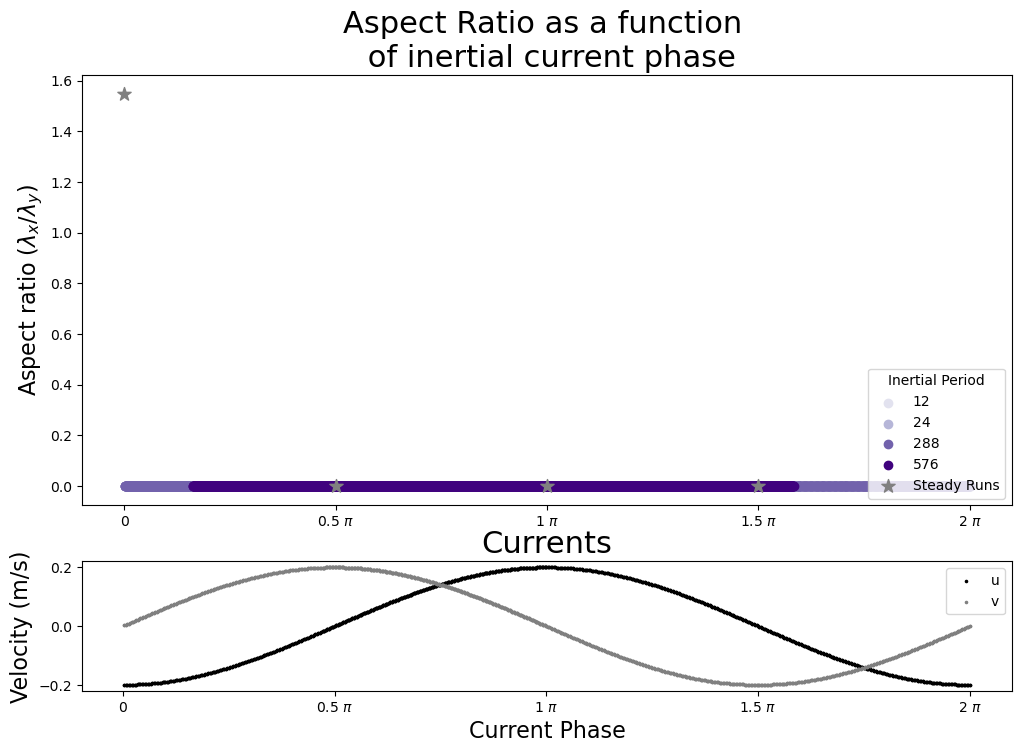

In [307]:

"""
Make a figure showing time series of variance

"""
import matplotlib.ticker as ticker

spath = "/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/"


cur_files = ["100_4", "100_8", "100_24", "100_36", "100_48", "100_96", "100_288", "100_576"]
cur_files = ["100_12", "100_24", "100_288", "100_576"]#, "100_96", "100_288"]#, "100_576"]#, "100_12", "100_24"]
#bc_list = ["BC_5", "BC_10", "BC_15"]
bc_list = ["BC_10"]
#cur_files = ["100_24", "100_36", "100_48"]

cmap = plt.colormaps['Purples']
c1 = cmap(0.2)
c2 = cmap(0.4)
c3 = cmap(0.7)
c4 = cmap(0.99)

# c1 = '#A3BCF9'
# c2 = '#C9CAD9'
# c3 = '#D1D2F9'
# c4 = '#6B4E71'
cs = np.array([c1, c2, c3, c4])
#fig, ax = plt.subplots(1,2, figsize=(15,5))
# Define the layout: 'A' spans two rows on the left
# 'B' is on top right, 'C' is a small axis below it
fig, ax = plt.subplot_mosaic(
    [['A', 'A'],
     ['B', 'B']],
    gridspec_kw={'height_ratios': [1, 0.3]},
    figsize = (12, 8)# Makes bottom row (C) small
)





start_ind = 1000
for cur_i in range(len(cur_files)):
    cur = cur_files[cur_i]
    for bc in bc_list: 

        data = xr.open_dataset(spath+bc+"/"+cur+"/all_cur"+".nc")
        #steady = xr.open_dataset(spath+"BC_10"+"/"+"100"+"_steady_west/all_cur"+".nc")
        control = xr.open_dataset(spath+bc+"/"+"100_576"+"/no_cur.nc")
        phase = np.arctan2(data.vcur[start_ind:, 40, 40], data.ucur[start_ind:, 40, 40])

        
        anom = data.hs[start_ind:, :]-control.hs[start_ind:, :]


        dhsdy = np.gradient(anom[:, :, :], ykm, axis=1)
        dhsdx = np.gradient(anom[:, :, :], xkm, axis=2)
        top = np.nanmean(dhsdy[:, 2:-2, 2:-2]**2, axis=(1,2))
        bot = np.nanmean(dhsdx[:, 2:-2, 2:-2]**2, axis=(1,2))
        mag = np.sqrt(np.nanmean(dhsdy[:, 10:-10, 10:-10]**2 + dhsdy[:, 10:-10, 10:-10]**2, axis=(1,2)))
        ratio = np.sqrt(top/bot)
        
        phase = -1*(phase-np.pi)
        max_anom = np.nanmax(np.abs(anom), axis=(1,2))
        #Do some interpolation to fix the smaller Ti's
        x = np.linspace(0, 2*np.pi, 1000)
        x_unique, indicies = np.unique(phase, return_inverse=True)
        ratio_avg = np.bincount(indicies, weights=ratio) / np.bincount(indicies)
        f= scipy.interpolate.interp1d(x_unique, ratio_avg, kind='slinear')
        x_new = np.linspace(x_unique.min(), x_unique.max(), 100)
        phase_max, max_amp = get_phase_peak(x_new, f(x_new))
        phase_min, min_amp = get_phase_min(x_new, f(x_new))

        avg_height = (np.nanmax(max_amp) + np.nanmin(min_amp))/2
        ax['A'].scatter(phase, mag, label=cur.split("_")[1], color=cs[cur_i])
       # ax['A'].hlines(y=avg_height, xmin=0, xmax=2*np.pi, color = cs[cur_i])
        #ax['A'].scatter(np.nanmean(phase_max), np.nanmean(max_amp), marker='*')
    #plt.scatter(cur, -1*(phase_max-np.pi)/np.pi)


print(phase[-1]/np.pi-phase[-2]/np.pi)
#ax['A'].set_yscale('log')
#ax3 = ax[0].twinx()
data = xr.open_dataset(spath+bc+"/"+"100_96"+"/all_cur"+".nc")
#steady = xr.open_dataset(spath+"BC_10"+"/"+"100"+"_steady_west/all_cur"+".nc")
control = xr.open_dataset(spath+bc+"/"+"100_576"+"/no_cur.nc")
phase = np.arctan2(data.vcur[start_ind:, 40, 40], data.ucur[start_ind:, 40, 40])
phase = -1*(phase-np.pi)

ax['B'].scatter(phase, data.ucur[start_ind:, 40, 40], color='black', marker='.', s=10, label='u')
ax['B'].scatter(phase, data.vcur[start_ind:, 40, 40], color='gray', marker='.', s=10, label='v')
ax['B'].legend()

control = xr.open_dataset(spath+bc+"/"+"100_576"+"/no_cur.nc")

steadyw = xr.open_dataset(spath+bc+"/"+"100"+"_steady_west/all_cur"+".nc")
steadyn = xr.open_dataset(spath+bc+"/"+"100"+"_steady_north/all_cur"+".nc")
steadye = xr.open_dataset(spath+bc+"/"+"100"+"_steady_east/all_cur"+".nc")
steadys = xr.open_dataset(spath+bc+"/"+"100"+"_steady_south/all_cur"+".nc")

steadynw = xr.open_dataset(spath+bc+"/"+"100"+"_steady_northwest/all_cur_full"+".nc")
steadyne = xr.open_dataset(spath+bc+"/"+"100"+"_steady_northeast/all_cur_full"+".nc")
steadyse = xr.open_dataset(spath+bc+"/"+"100"+"_steady_southeast/all_cur_full"+".nc")
steadysw = xr.open_dataset(spath+bc+"/"+"100"+"_steady_southwest/all_cur_full"+".nc")

dhsdy = np.gradient(steadyw.hs[2000:, :, :]-control.hs[2000:, :, :], ykm, axis=1)
dhsdx = np.gradient(steadyw.hs[2000:, :, :]-control.hs[2000:, :, :], xkm, axis=2)
top = np.nanmean(dhsdy[:, 2:-2, 2:-2]**2, axis=(1,2))
bot = np.nanmean(dhsdx[:, 2:-2, 2:-2]**2, axis=(1,2))
ratiow = np.nanmean(np.sqrt(top/bot))
gradw = np.sqrt(np.nanmean(dhsdy[:, 2:-2, 2:-2].flatten()**2+dhsdx[:, 2:-2, 2:-2].flatten()**2))
ratiow = np.nanmean(np.sqrt(np.nanmean(dhsdy[:, 10:-10, 10:-10]**2+dhsdx[:, 10:-10, 10:-10]**2, axis=(1,2))))

dhsdy = np.gradient(steadyn.hs[2000:, :, :]-control.hs[2000:, :, :], ykm, axis=1)
dhsdx = np.gradient(steadyn.hs[2000:, :, :]-control.hs[2000:, :, :], xkm, axis=2)
top = np.nanmean(dhsdy[:, 2:-2, 2:-2]**2, axis=(1,2))
bot = np.nanmean(dhsdx[:, 2:-2, 2:-2]**2, axis=(1,2))
ration = np.nanmean(np.sqrt(top/bot))
ration = np.nanmean(np.sqrt(np.nanmean(dhsdy[:, 10:-10, 10:-10]**2+dhsdx[:,10:-10, 10:-10]**2, axis=(1,2))))

dhsdy = np.gradient(steadye.hs[2000:, :, :]-control.hs[2000:, :, :], ykm, axis=1)
dhsdx = np.gradient(steadye.hs[2000:, :, :]-control.hs[2000:, :, :], xkm, axis=2)
top = np.nanmean(dhsdy[:, 2:-2, 2:-2]**2, axis=(1,2))
bot = np.nanmean(dhsdx[:, 2:-2, 2:-2]**2, axis=(1,2))
ratioe = np.nanmean(np.sqrt(top/bot))
ratioe = np.nanmean(np.sqrt(np.nanmean(dhsdy[:, 10:-10, 10:-10]**2+dhsdx[:, 10:-10, 10:-10]**2, axis=(1,2))))

dhsdy = np.gradient(steadys.hs[2000:, :, :]-control.hs[2000:, :, :], ykm, axis=1)
dhsdx = np.gradient(steadys.hs[2000:, :, :]-control.hs[2000:, :, :], xkm, axis=2)
top = np.nanmean(dhsdy[:, 2:-2, 2:-2]**2, axis=(1,2))
bot = np.nanmean(dhsdx[:, 2:-2, 2:-2]**2, axis=(1,2))
ratios = np.nanmean(np.sqrt(top/bot))
ratios = np.nanmean(np.sqrt(np.nanmean(dhsdy[:, 10:-10, 10:-10]**2+dhsdx[:, 10:-10, 10:-10]**2, axis=(1,2))))


varnw = np.nanmean(np.nanvar(steadynw.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
varne = np.nanmean(np.nanvar(steadyne.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
varse = np.nanmean(np.nanvar(steadyse.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))
varsw = np.nanmean(np.nanvar(steadysw.hs[2000:, :, :]-control.hs[2000:, :, :], axis=(1,2)))


ax['A'].scatter(0, ratiow, s=100, marker='*',  color='gray')#, edgecolor='tab:orange')
ax['A'].scatter(np.pi/2, ration, s=100, marker='*',  color='gray')#, edgecolor='tab:orange')
ax['A'].scatter(np.pi, ratioe, s=100, marker='*',  color='gray')#, edgecolor='tab:orange')
ax['A'].scatter(3*np.pi/2, ratios, s=100, marker='*',  color='gray', label="Steady Runs")#, edgecolor='tab:orange', label="Steady Runs")

# ax['A'].scatter(np.pi/4, varnw, s=100, marker='*',  color='gray')#, edgecolor='tab:orange')
# ax['A'].scatter(3*np.pi/4, varne, s=100, marker='*',  color='gray')#, edgecolor='tab:orange')
# ax['A'].scatter(5*np.pi/4, varse, s=100, marker='*',  color='gray')#, edgecolor='tab:orange')
# ax['A'].scatter(7*np.pi/4, varsw, s=100, marker='*',  color='gray')#, edgecolor='tab:orange')

# (varw-vare)/varw
#plt.scatter(phase_max,max_amp, marker='*')
#ax['A'].set_yscale('log')
ax['A'].legend(loc='lower right', title="Inertial Period")

#get Axis in terms of 0-2pi
ax['A'].xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 2))
ax['A'].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda val, pos: '{:.2g} $\pi$'.format(val / np.pi) if val != 0 else '0'
))

ax['B'].xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 2))
ax['B'].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda val, pos: '{:.2g} $\pi$'.format(val / np.pi) if val != 0 else '0'
))


## Second panel (b)

#plt.colorbar()

#Put all the titles etc.
fs = 16
fs_title = 22
ax['A'].set_ylabel("Aspect ratio $(\lambda_{x}/\lambda_{y})$", fontsize=fs)


ax['B'].set_ylabel("Velocity (m/s)", fontsize=fs)
ax['B'].set_xlabel("Current Phase", fontsize=fs)


#ax['B'].set_ylabel("Phase of first peak")
#ax['B'].set_title("Current Phase during peak variance")
#ax['B'].legend()

ax['A'].set_title('Aspect Ratio as a function \n of inertial current phase', fontsize=fs_title)
ax['B'].set_title('Currents', fontsize=fs_title)


#ax['B'].vlines(x=0.6*np.pi, ymin=0.000095, ymax=0.0001045, color='gray')

#plt.savefig("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/figures/variance_timeseries.png", dpi = 300, bbox_inches='tight')
plt.show()


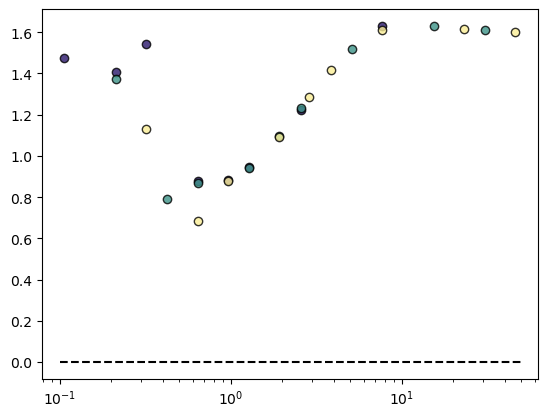

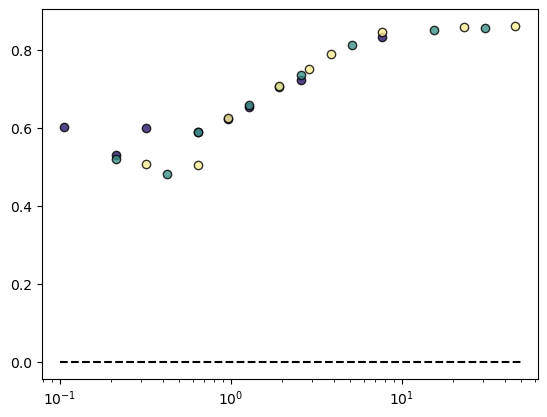

In [273]:

fig, ax = plt.subplots(1)
cgi= np.where(phase_info_df['cg']<4)[0]
ax.scatter(phase_info_df['cgT/L'].values[cgi]*0.19, phase_info_df['Max Ratio'].values[cgi], color=c5, alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])
#Put label
#ax.scatter(phase_info_df['cgT/L'].values[cgi[0]]*0.19, (phase_info_df['Max Var'].values[cgi[0]]-phase_info_df['Mean Amp'].values[cgi[0]])/(varw5-amp5), color=c5, alpha=0.8, edgecolors='black', label=f"{phase_info_df['cg'][cgi[0]]:0.1f}")


cgi= np.intersect1d(np.where(phase_info_df['cg']<10)[0], np.where(phase_info_df['cg']>4)[0])
ax.scatter(phase_info_df['cgT/L'].values[cgi]*0.19,phase_info_df['Max Ratio'].values[cgi], color=c10, alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])
#ax.scatter(phase_info_df['cgT/L'].values[cgi[0]]*0.19, (phase_info_df['Max Var'].values[cgi[0]]-phase_info_df['Mean Amp'].values[cgi[0]])/(varw10-amp10), color=c10, alpha=0.8, edgecolors='black', label=f"{phase_info_df['cg'][cgi[0]]:0.1f}")


control = xr.open_dataset(spath+"BC_15"+"/"+"100_576"+"/no_cur.nc")
cgi= np.where(phase_info_df['cg']>10)[0]
ax.scatter(phase_info_df['cgT/L'].values[cgi]*0.19, phase_info_df['Max Ratio'].values[cgi], color=c15, alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])
#ax.scatter(phase_info_df['cgT/L'].values[cgi[0]]*0.19, (phase_info_df['Max Var'].values[cgi[0]]-phase_info_df['Mean Amp'].values[cgi[0]])/(varw15-amp15), color=c15, alpha=0.8, edgecolors='black', label=f"{phase_info_df['cg'][cgi[0]]:0.1f}")
ax.set_xscale('log')

plt.hlines(y=(ratiow+ratios)/2, xmin=0.1, xmax=50, linestyle='--', color='black')

fig, ax = plt.subplots(1)
cgi= np.where(phase_info_df['cg']<4)[0]
ax.scatter(phase_info_df['cgT/L'].values[cgi]*0.19, phase_info_df['Min Ratio'].values[cgi], color=c5, alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])
#Put label
#ax.scatter(phase_info_df['cgT/L'].values[cgi[0]]*0.19, (phase_info_df['Max Var'].values[cgi[0]]-phase_info_df['Mean Amp'].values[cgi[0]])/(varw5-amp5), color=c5, alpha=0.8, edgecolors='black', label=f"{phase_info_df['cg'][cgi[0]]:0.1f}")


cgi= np.intersect1d(np.where(phase_info_df['cg']<10)[0], np.where(phase_info_df['cg']>4)[0])
ax.scatter(phase_info_df['cgT/L'].values[cgi]*0.19,phase_info_df['Min Ratio'].values[cgi], color=c10, alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])
#ax.scatter(phase_info_df['cgT/L'].values[cgi[0]]*0.19, (phase_info_df['Max Var'].values[cgi[0]]-phase_info_df['Mean Amp'].values[cgi[0]])/(varw10-amp10), color=c10, alpha=0.8, edgecolors='black', label=f"{phase_info_df['cg'][cgi[0]]:0.1f}")


control = xr.open_dataset(spath+"BC_15"+"/"+"100_576"+"/no_cur.nc")
cgi= np.where(phase_info_df['cg']>10)[0]
ax.scatter(phase_info_df['cgT/L'].values[cgi]*0.19, phase_info_df['Min Ratio'].values[cgi], color=c15, alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])
#ax.scatter(phase_info_df['cgT/L'].values[cgi[0]]*0.19, (phase_info_df['Max Var'].values[cgi[0]]-phase_info_df['Mean Amdhsdy[:, 2:-2, 2:-2]**2p'].values[cgi[0]])/(varw15-amp15), color=c15, alpha=0.8, edgecolors='black', label=f"{phase_info_df['cg'][cgi[0]]:0.1f}")
ax.set_xscale('log')

plt.hlines(y=ration, xmin=0.1, xmax=50, linestyle='--', color='black')

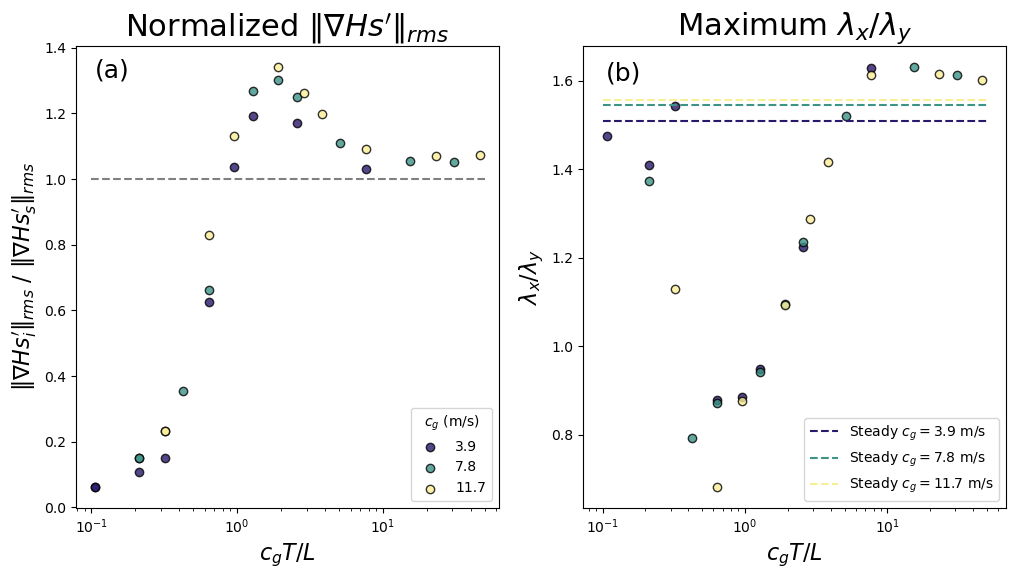

In [361]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))


steadyw5 = xr.open_dataset(spath+"BC_5"+"/"+"100"+"_steady_west/all_cur"+".nc")
steadyw10 = xr.open_dataset(spath+"BC_10"+"/"+"100"+"_steady_west/all_cur"+".nc")
steadyw15 = xr.open_dataset(spath+"BC_15"+"/"+"100"+"_steady_west/all_cur"+".nc")

steadyn5 = xr.open_dataset(spath+"BC_5"+"/"+"100"+"_steady_north/all_cur"+".nc")
steadyn10 = xr.open_dataset(spath+"BC_10"+"/"+"100"+"_steady_north/all_cur"+".nc")
steadyn15 = xr.open_dataset(spath+"BC_15"+"/"+"100"+"_steady_north/all_cur"+".nc")


control = xr.open_dataset(spath+"BC_5"+"/"+"100_576"+"/no_cur.nc")
dhsdy = np.gradient(steadyw5.hs[2000:, :, :]-control.hs[2000:, :, :], ykm, axis=1)
dhsdx = np.gradient(steadyw5.hs[2000:, :, :]-control.hs[2000:, :, :], xkm, axis=2)
top = np.nanmean(dhsdy[:, 2:-2, 2:-2]**2, axis=(1,2))
bot = np.nanmean(dhsdx[:, 2:-2, 2:-2]**2, axis=(1,2))
ratiow5 = np.nanmean(np.sqrt(top/bot))
gradw5 = np.sqrt(np.nanmean(dhsdy[:, 2:-2, 2:-2].flatten()**2 + dhsdx[:, 2:-2, 2:-2].flatten()**2))

dhsdy = np.gradient(steadyn5.hs[2000:, :, :]-control.hs[2000:, :, :], ykm, axis=1)
dhsdx = np.gradient(steadyn5.hs[2000:, :, :]-control.hs[2000:, :, :], xkm, axis=2)
gradn5 = np.sqrt(np.nanmean(dhsdy[:, 2:-2, 2:-2].flatten()**2 + dhsdx[:, 2:-2, 2:-2].flatten()**2))


control = xr.open_dataset(spath+"BC_10"+"/"+"100_576"+"/no_cur.nc")
dhsdy = np.gradient(steadyw10.hs[2000:, :, :]-control.hs[2000:, :, :], ykm, axis=1)
dhsdx = np.gradient(steadyw10.hs[2000:, :, :]-control.hs[2000:, :, :], xkm, axis=2)
gradw10 = np.sqrt(np.nanmean(dhsdy[:, 2:-2, 2:-2].flatten()**2 + dhsdx[:, 2:-2, 2:-2].flatten()**2))
top = np.nanmean(dhsdy[:, 2:-2, 2:-2]**2, axis=(1,2))
bot = np.nanmean(dhsdx[:, 2:-2, 2:-2]**2, axis=(1,2))
ratiow10 = np.nanmean(np.sqrt(top/bot))

dhsdy = np.gradient(steadyn10.hs[2000:, :, :]-control.hs[2000:, :, :], ykm, axis=1)
dhsdx = np.gradient(steadyn10.hs[2000:, :, :]-control.hs[2000:, :, :], xkm, axis=2)
gradn10 = np.sqrt(np.nanmean(dhsdy[:, 2:-2, 2:-2].flatten()**2 + dhsdx[:, 2:-2, 2:-2].flatten()**2))


control = xr.open_dataset(spath+"BC_15"+"/"+"100_576"+"/no_cur.nc")
dhsdy = np.gradient(steadyw15.hs[2000:, :, :]-control.hs[2000:, :, :], ykm, axis=1)
dhsdx = np.gradient(steadyw15.hs[2000:, :, :]-control.hs[2000:, :, :], xkm, axis=2)
gradw15 = np.sqrt(np.nanmean(dhsdy[:, 2:-2, 2:-2].flatten()**2 + dhsdx[:, 2:-2, 2:-2].flatten()**2))
top = np.nanmean(dhsdy[:, 2:-2, 2:-2]**2, axis=(1,2))
bot = np.nanmean(dhsdx[:, 2:-2, 2:-2]**2, axis=(1,2))
ratiow15 = np.nanmean(np.sqrt(top/bot))

dhsdy = np.gradient(steadyn15.hs[2000:, :, :]-control.hs[2000:, :, :], ykm, axis=1)
dhsdx = np.gradient(steadyn15.hs[2000:, :, :]-control.hs[2000:, :, :], xkm, axis=2)
gradn15 = np.sqrt(np.nanmean(dhsdy[:, 2:-2, 2:-2].flatten()**2 + dhsdx[:, 2:-2, 2:-2].flatten()**2))



cgi= np.where(phase_info_df['cg']<4)[0]
ax[1].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, phase_info_df['Max Ratio'].values[cgi], color=c5, alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])
ax[0].scatter(phase_info_df['cgT/L'].values[cgi[0]]*0.19, phase_info_df['RMS Grad'].values[cgi[0]]/((gradw5+gradn5)/2), color=c5, alpha=0.8, edgecolors='black', label=f"{phase_info_df['cg'][cgi[0]]:0.1f}")
ax[0].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, phase_info_df['RMS Grad'].values[cgi]/((gradw5+gradn5)/2), color=c5, alpha=0.8, edgecolors='black')
ax[1].hlines(y=ratiow5, xmin=0.1, xmax=50, linestyle='--', color=c5, label="Steady $c_g=$"+f"{phase_info_df['cg'][cgi[0]]:0.1f}"+" m/s")

#Put label
#ax.scatter(phase_info_df['cgT/L'].values[cgi[0]]*0.19, (phase_info_df['Max Var'].values[cgi[0]]-phase_info_df['Mean Amp'].values[cgi[0]])/(varw5-amp5), color=c5, alpha=0.8, edgecolors='black', label=f"{phase_info_df['cg'][cgi[0]]:0.1f}")


cgi= np.intersect1d(np.where(phase_info_df['cg']<10)[0], np.where(phase_info_df['cg']>4)[0])
ax[1].scatter(phase_info_df['cgT/L'].values[cgi]*0.19,phase_info_df['Max Ratio'].values[cgi], color=c10, alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])
ax[0].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, phase_info_df['RMS Grad'].values[cgi]/((gradw10+gradn10)/2), color=c10, alpha=0.8, edgecolors='black')
ax[0].scatter(phase_info_df['cgT/L'].values[cgi[0]]*0.19, phase_info_df['RMS Grad'].values[cgi[0]]/((gradw10+gradn10)/2), color=c10, alpha=0.8, edgecolors='black', label=f"{phase_info_df['cg'][cgi[0]]:0.1f}")
ax[1].hlines(y=ratiow10, xmin=0.1, xmax=50, linestyle='--', color=c10, label="Steady $c_g=$"+f"{phase_info_df['cg'][cgi[0]]:0.1f}"+" m/s")

#ax.scatter(phase_info_df['cgT/L'].values[cgi[0]]*0.19, (phase_info_df['Max Var'].values[cgi[0]]-phase_info_df['Mean Amp'].values[cgi[0]])/(varw10-amp10), color=c10, alpha=0.8, edgecolors='black', label=f"{phase_info_df['cg'][cgi[0]]:0.1f}")


control = xr.open_dataset(spath+"BC_15"+"/"+"100_576"+"/no_cur.nc")
cgi= np.where(phase_info_df['cg']>10)[0]
ax[1].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, phase_info_df['Max Ratio'].values[cgi], color=c15, alpha=0.8, edgecolors='black')#, label=phase_info_df['cg'])
ax[0].scatter(phase_info_df['cgT/L'].values[cgi[0]]*0.19, phase_info_df['RMS Grad'].values[cgi[0]]/((gradw15+gradn15)/2), color=c15, alpha=0.8, edgecolors='black', label=f"{phase_info_df['cg'][cgi[0]]:0.1f}")
ax[0].scatter(phase_info_df['cgT/L'].values[cgi]*0.19, phase_info_df['RMS Grad'].values[cgi]/((gradw15+gradn15)/2), color=c15, alpha=0.8, edgecolors='black')
ax[1].hlines(y=ratiow15, xmin=0.1, xmax=50, linestyle='--', color=c15, label="Steady $c_g=$"+f"{phase_info_df['cg'][cgi[0]]:0.1f}"+" m/s")


#ax.scatter(phase_info_df['cgT/L'].values[cgi[0]]*0.19, (phase_info_df['Max Var'].values[cgi[0]]-phase_info_df['Mean Amdhsdy[:, 2:-2, 2:-2]**2p'].values[cgi[0]])/(varw15-amp15), color=c15, alpha=0.8, edgecolors='black', label=f"{phase_info_df['cg'][cgi[0]]:0.1f}")
ax[1].set_xscale('log')
ax[0].set_xscale('log')

ax[0].hlines(y=1, xmin=0.1, xmax=50, linestyle='--', color='gray')

ax[0].legend(loc='lower right', title="$c_g$ (m/s)")
ax[1].legend(loc='lower right')
ax[0].set_title(r"Normalized $\| \nabla Hs'\|_{rms}$", fontsize=fs_title)
ax[1].set_title("Maximum $\lambda_{x}/\lambda_{y}$", fontsize=fs_title)
ax[0].set_xlabel("$c_gT/L$", fontsize=fs)
ax[1].set_xlabel("$c_gT/L$", fontsize=fs)

ax[0].set_ylabel(r"$\| \nabla Hs_{i}'\|_{rms}$ / $\| \nabla Hs_{s}'\|_{rms}$", fontsize=fs)
ax[1].set_ylabel("$\lambda_x/\lambda_y$", fontsize=fs)

ax[0].annotate(text='(a)', xy=(0.14, 1.31), fontsize=fonts, ha="center")
ax[1].annotate(text='(b)', xy=(0.14, 1.6), fontsize=fonts, ha="center")

plt.savefig("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/figures/gradients_and_aspect_ratio.png", dpi = 300, bbox_inches='tight')



array([], shape=(305, 0, 0), dtype=float32)

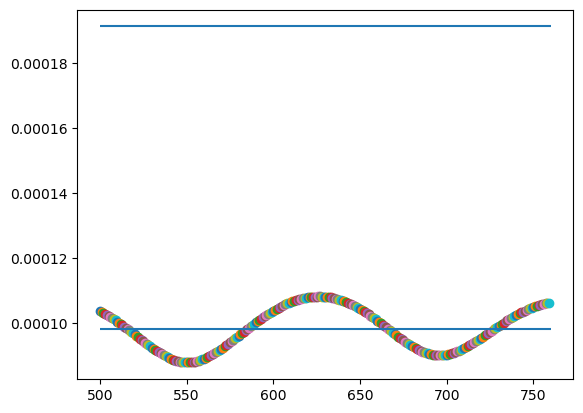

In [318]:
# plt.hist(dhsdx[100, 2:-2, 2:-2].flatten()**2, bins=50, density=True)
# plt.hist(dhsdy[100, 2:-2, 2:-2].flatten()**2, bins=50, density=True)
# print(np.nanmean(dhsdx[100, 2:-2, 2:-2].flatten()**2), np.nanmean(dhsdy[100, 2:-2, 2:-2].flatten()**2))
# print(np.nanmedian(dhsdx[100, 2:-2, 2:-2].flatten()**2), np.nanmedian(dhsdy[100, 2:-2, 2:-2].flatten()**2))
# print(np.percentile(np.sqrt(dhsdx[100, 2:-2, 2:-2].flatten()**2+dhsdy[100, 2:-2, 2:-2].flatten()**2), 90))#, np.percentile(dhsdy[100, 2:-2, 2:-2].flatten()**2, 90))

bc = 'BC_10'
cur = "100_48"
start_ind = 1500
data = xr.open_dataset(spath+bc+"/"+cur+"/all_cur"+".nc")
#steady = xr.open_dataset(spath+"BC_10"+"/"+"100"+"_steady_west/all_cur"+".nc")
control = xr.open_dataset(spath+bc+"/"+"100_576"+"/no_cur.nc")
phase = np.arctan2(data.vcur[start_ind:, 40, 40], data.ucur[start_ind:, 40, 40])


anom = data.hs[start_ind:, :]-control.hs[start_ind:, :]


dhsdy = np.gradient(anom[:, :, :], ykm, axis=1)
dhsdx = np.gradient(anom[:, :, :], xkm, axis=2)



plt.figure()
for i in range(500, 760, 1):
  

    #plt.scatter(i, np.percentile(np.sqrt(dhsdx[i, 2:-2, 2:-2].flatten()**2+dhsdy[i, 2:-2, 2:-2].flatten()**2), 90))
    plt.scatter(i, np.nanmean(np.sqrt(dhsdx[i, 2:-2, 2:-2].flatten()**2+dhsdy[i, 2:-2, 2:-2].flatten()**2)))

plt.hlines(y=np.nanmean(np.sqrt(dhsdx[500:760, 2:-2, 2:-2].flatten()**2+dhsdy[500:760, 2:-2, 2:-2].flatten()**2)), xmin=500, xmax=760)
plt.hlines(y=gradw10, xmin=500, xmax=760)
    

In [292]:
12*6

72

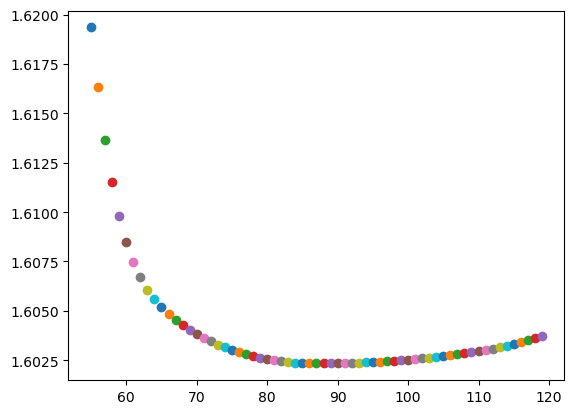

In [37]:
spath = "/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/hyak_output/outputs_100_long/outputs/BC_10/"

steadyw = xr.open_dataset(spath+"100_steady_east"+"/all_cur_full"+".nc")
control = xr.open_dataset(spath+"100_steady_west"+"/no_cur_full"+".nc")
xkm = np.linspace(-haversine((0, -150), (0, -135), unit=Unit.KILOMETERS)/2, haversine((0, -150), (0, -135), unit=Unit.KILOMETERS)/2, len(control.longitude))

plt.figure()
for i in range(55,120):
    dhsdy = np.gradient(steadyw.hs[1000:, :, :i]-control.hs[1000:, :, :i], ykm, axis=1)
    dhsdx = np.gradient(steadyw.hs[1000:, :, :i]-control.hs[1000:, :, :i], xkm[:i], axis=2)
    top = np.nanmean(dhsdy[:, 2:-2, 2:-2]**2, axis=(1,2))
    bot = np.nanmean(dhsdx[:, 2:-2, 2:-2]**2, axis=(1,2))
    ratiow = np.nanmean(np.sqrt(top/bot))
    #varw = np.nanmean(np.var(steadyw.hs[1000:, :, :i]-control.hs[1000:, :, :i], axis=(1,2)))
    #vare = np.nanmean(np.var(steadye.hs[400:, :, :i]-control.hs[400:, :, :i], axis=(1,2)))
    
    plt.scatter(i, ratiow)
    #plt.scatter(i, vare, marker='*')

#plt.scatter(120, 0.08190)
#plt.ylim(0, 0.12)

# plt.figure()
# for i in range(55,120):
#     varw = np.nanmean(np.var(steadyw.hs[1000:, :, :i]-control.hs[1000:, :, :i], axis=(1,2)))
#     vare = np.nanmean(np.var(steadye.hs[1000:, :, :i]-control.hs[1000:, :, :i], axis=(1,2)))
    
#     plt.scatter(i, (varw-vare)/varw)

# plt.figure()
# for i in range(55,120):
#     varw = np.var(steadyw.hs[-100, :, :i]-control.hs[-100, :, :i], axis=(0,1))
#     vare = np.var(steadye.hs[-100, :, :i]-control.hs[-100, :, :i], axis=(0,1))
    
#     plt.scatter(i, (varw-vare)/varw)

80

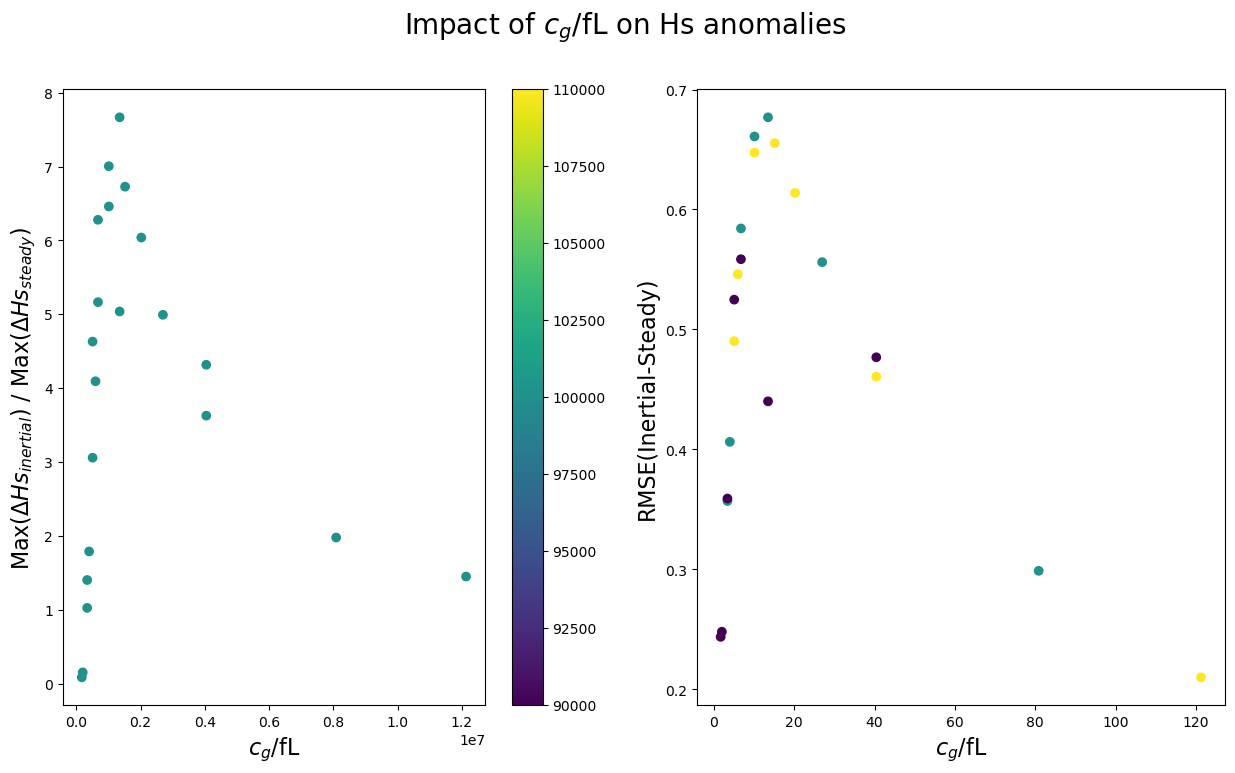

In [480]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8))
cm = ax[0].scatter(impact_df_north['Ti']*impact_df_north['cg'], impact_df_north['Normalized Variance'], c=impact_df_north["L"])


ax[0].set_xlabel("$c_g$/fL", fontsize=16)
ax[0].set_ylabel("Max($\Delta Hs_{inertial}$) / Max($\Delta Hs_{steady}$)", fontsize=16)


ax[1].scatter(impact_df_north['cgT/L'], impact_df_north['NRMSE'], c=impact_df_north["cg"])
ax[1].set_ylabel("RMSE(Inertial-Steady)", fontsize=16)
ax[1].set_xlabel("$c_g$/fL", fontsize=16)
plt.colorbar(cm)
plt.suptitle("Impact of $c_g$/fL on Hs anomalies", fontsize=20)


cgfl_list=np.linspace(0, 120)
f = 0.2*np.exp(-cgfl_list/31)+0.02



## What's the relationship between U cos theta and \Delta Hs?

### What's the 1d relationship supposed to be?

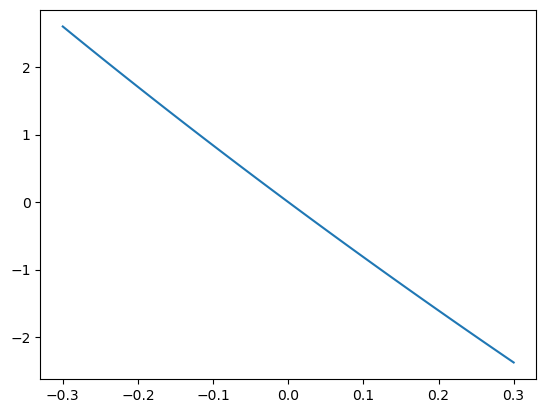

In [299]:
E1 = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/BCs_s45/BC_10/boundary_spec_bottom_0.nc")
#fs = E1.frequency.values
#Efth = E1.efth.values[0, :, :]
E1 = E1.sortby('direction')
E1['direction'] = np.pi*E1['direction']/180
E1 = E1.integrate('direction')
E10 = E1.efth[0, 0, :].values
f = E1.frequency.values

cg = (9.8)/(4*np.pi)*(1/f)
F0 = E10*cg
u_list = np.linspace(-.3, .3)
Hs_list = np.zeros(len(u_list))
mss_list = np.zeros(len(u_list))
Hs1 = 4*np.sqrt(np.trapz(E10, f))
for u_i in range(len(u_list)):
    u = u_list[u_i]
    E2 = F0 / (cg+u)
    Hs_list[u_i] = 4*np.sqrt(np.trapz(E2, f))

#plt.plot(u_list, 100*(Hs_list-Hs1)/Hs1)
theor_limit = 100*(Hs_list-Hs1)/Hs1
#plt.contourf(E1.frequency, E1.direction, E1.efth[0, 0, :, :].T)
#plt.plot(E1.frequency, E1.efth[0, 0, :])

In [282]:
bc="BC_10"
data12 = xr.open_dataset(spath+bc+"/"+"100_12"+"/"+"all_cur"+".nc")
data24 = xr.open_dataset(spath+bc+"/"+"100_24"+"/"+"all_cur"+".nc")
data48 = xr.open_dataset(spath+bc+"/"+"100_48"+"/"+"all_cur"+".nc")
data96 = xr.open_dataset(spath+bc+"/"+"100_96"+"/"+"all_cur"+".nc")
data288 = xr.open_dataset(spath+bc+"/"+"100_288"+"/"+"all_cur"+".nc")

control = xr.open_dataset(spath+bc+"/"+"100_576"+"/no_cur.nc")
steadyw =  xr.open_dataset(spath+bc+"/"+"100_steady_west"+"/all_cur.nc")
steadye =  xr.open_dataset(spath+bc+"/"+"100_steady_east"+"/all_cur.nc")
steadyn =  xr.open_dataset(spath+bc+"/"+"100_steady_north"+"/all_cur.nc")
steadys =  xr.open_dataset(spath+bc+"/"+"100_steady_south"+"/all_cur.nc")

anom12 = 100*(data12.hs - control.hs)/control.hs
anom24 = 100*(data24.hs - control.hs)/control.hs
anom48 = 100*(data48.hs - control.hs)/control.hs
anom96 = 100*(data96.hs - control.hs)/control.hs
anom288 = 100*(data288.hs - control.hs)/control.hs

steady_anomw = 100*(steadyw.hs - control.hs)/control.hs
steady_anome = 100*(steadye.hs - control.hs)/control.hs
steady_anomn = 100*(steadyn.hs - control.hs)/control.hs
steady_anoms = 100*(steadys.hs - control.hs)/control.hs

steady_anom = np.append(steady_anomw[500:, :, :].values.flatten(), steady_anome[500:, :, :].values.flatten())
steady_anom = np.append(steady_anom,  steady_anomn[500:, :, :].values.flatten())
steady_anom = np.append(steady_anom,  steady_anoms[500:, :, :].values.flatten())
ucur_steady = np.append(steadyw.ucur[500:, :, :].values.flatten(), steadye.ucur[500:, :, :].values.flatten())
ucur_steady = np.append(ucur_steady, steadyn.ucur[500:, :, :].values.flatten())
ucur_steady = np.append(ucur_steady, steadys.ucur[500:, :, :].values.flatten())

vcur_steady = np.append(steadyw.vcur[500:, :, :].values.flatten(), steadye.vcur[500:, :, :].values.flatten())
vcur_steady = np.append(vcur_steady, steadyn.vcur[500:, :, :].values.flatten())
vcur_steady = np.append(vcur_steady, steadys.vcur[500:, :, :].values.flatten())

In [283]:


anom12mss = 100*(data12.mssu - control.mssu)/control.mssu
anom24mss = 100*(data24.mssu - control.mssu)/control.mssu
anom48mss = 100*(data48.mssu - control.mssu)/control.mssu
anom96mss = 100*(data96.mssu - control.mssu)/control.mssu
anom288mss = 100*(data288.mssu - control.mssu)/control.mssu

steady_anomwmss = 100*(steadyw.mssu - control.mssu)/control.mssu
steady_anomemss = 100*(steadye.mssu - control.mssu)/control.mssu
steady_anomnmss = 100*(steadyn.mssu - control.mssu)/control.mssu
steady_anomsmss = 100*(steadys.mssu - control.mssu)/control.mssu

steady_anommss = np.append(steady_anomwmss[500:, :, :].values.flatten(), steady_anome[500:, :, :].values.flatten())
steady_anommss = np.append(steady_anommss,  steady_anomnmss[500:, :, :].values.flatten())
steady_anommss = np.append(steady_anommss,  steady_anomsmss[500:, :, :].values.flatten())


Text(0.5, 0, '[s/m]')

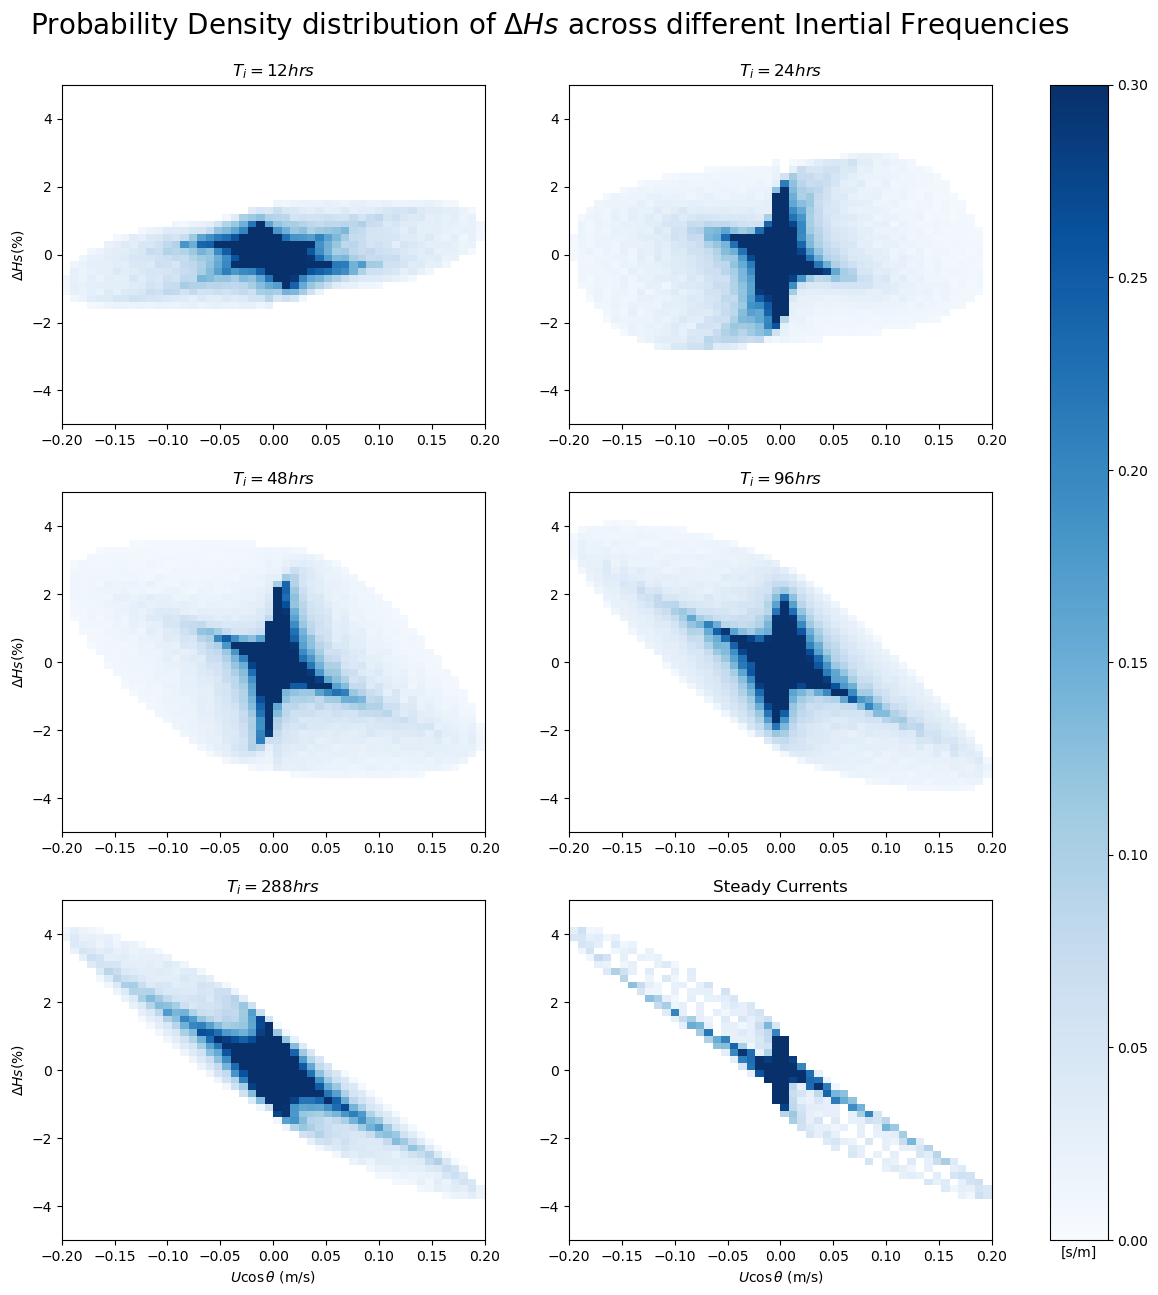

In [284]:
fig, ax = plt.subplots(3,2, figsize=(15, 15))
h, xed, yed, im = ax[0,0].hist2d(data12.ucur[500:, :, :].values.flatten(), anom12[500:, :, :].values.flatten(), density=True, bins=50, range=[[-0.2, 0.2], [-5, 5]], cmin=0.005, vmin=0, vmax=0.3, cmap='Blues')
h, xed, yed, im = ax[0,1].hist2d(data24.ucur[500:, :, :].values.flatten(), anom24[500:, :, :].values.flatten(), density=True, bins=50, range=[[-0.2, 0.2], [-5, 5]],cmin=0.005, vmin=0, vmax=0.3, cmap='Blues')
h, xed, yed, im = ax[1,0].hist2d(data48.ucur[500:, :, :].values.flatten(), anom48[500:, :, :].values.flatten(), density=True, bins=50, range=[[-0.2, 0.2], [-5, 5]], cmin=0.005, vmin=0, vmax=0.3, cmap='Blues')
h, xed, yed, im = ax[1,1].hist2d(data96.ucur[500:, :, :].values.flatten(), anom96[500:, :, :].values.flatten(), density=True, bins=50, range=[[-0.2, 0.2], [-5, 5]], cmin=0.005, vmin=0, vmax=0.3, cmap='Blues')
h, xed, yed, im = ax[2,0].hist2d(data288.ucur[500:, :, :].values.flatten(), anom288[500:, :, :].values.flatten(), density=True, bins=50, range=[[-0.2, 0.2], [-5, 5]], cmin=0.005, vmin=0, vmax=0.3, cmap='Blues')
h, xed, yed, im = ax[2,1].hist2d(ucur_steady, steady_anom, density=True, bins=50, range=[[-0.2, 0.2], [-5, 5]], cmin=0.01, vmin=0, vmax=0.3, cmap='Blues')

#Set xlabels
ax[2, 0].set_xlabel(r"$ U \cos\theta $ (m/s)")
ax[2, 1].set_xlabel(r"$ U \cos\theta $ (m/s)")
#Set ylabels
ax[0, 0].set_ylabel("$ \Delta Hs $(%)")
ax[1, 0].set_ylabel("$ \Delta Hs $(%)")
ax[2, 0].set_ylabel("$ \Delta Hs $(%)")
#set titles
ax[0,0].set_title("$T_i=12 hrs$")
ax[0,1].set_title("$T_i=24 hrs$")
ax[1,0].set_title("$T_i=48 hrs$")
ax[1,1].set_title("$T_i=96 hrs$")
ax[2,0].set_title("$T_i=288 hrs$")
ax[2,1].set_title("Steady Currents")

fig.suptitle("Probability Density distribution of $\Delta Hs$ across different Inertial Frequencies", fontsize=20, y=0.93, x=0.45)


#ax = ax.flatten()
#for i in range(len(ax)):
#    ax[i].plot(u_list, 2*theor_limit, '--r')
cbar= fig.colorbar(im, ax=ax)
cbar.ax.set_xlabel("[s/m]")


Text(0.5, 0, '[s/m]')

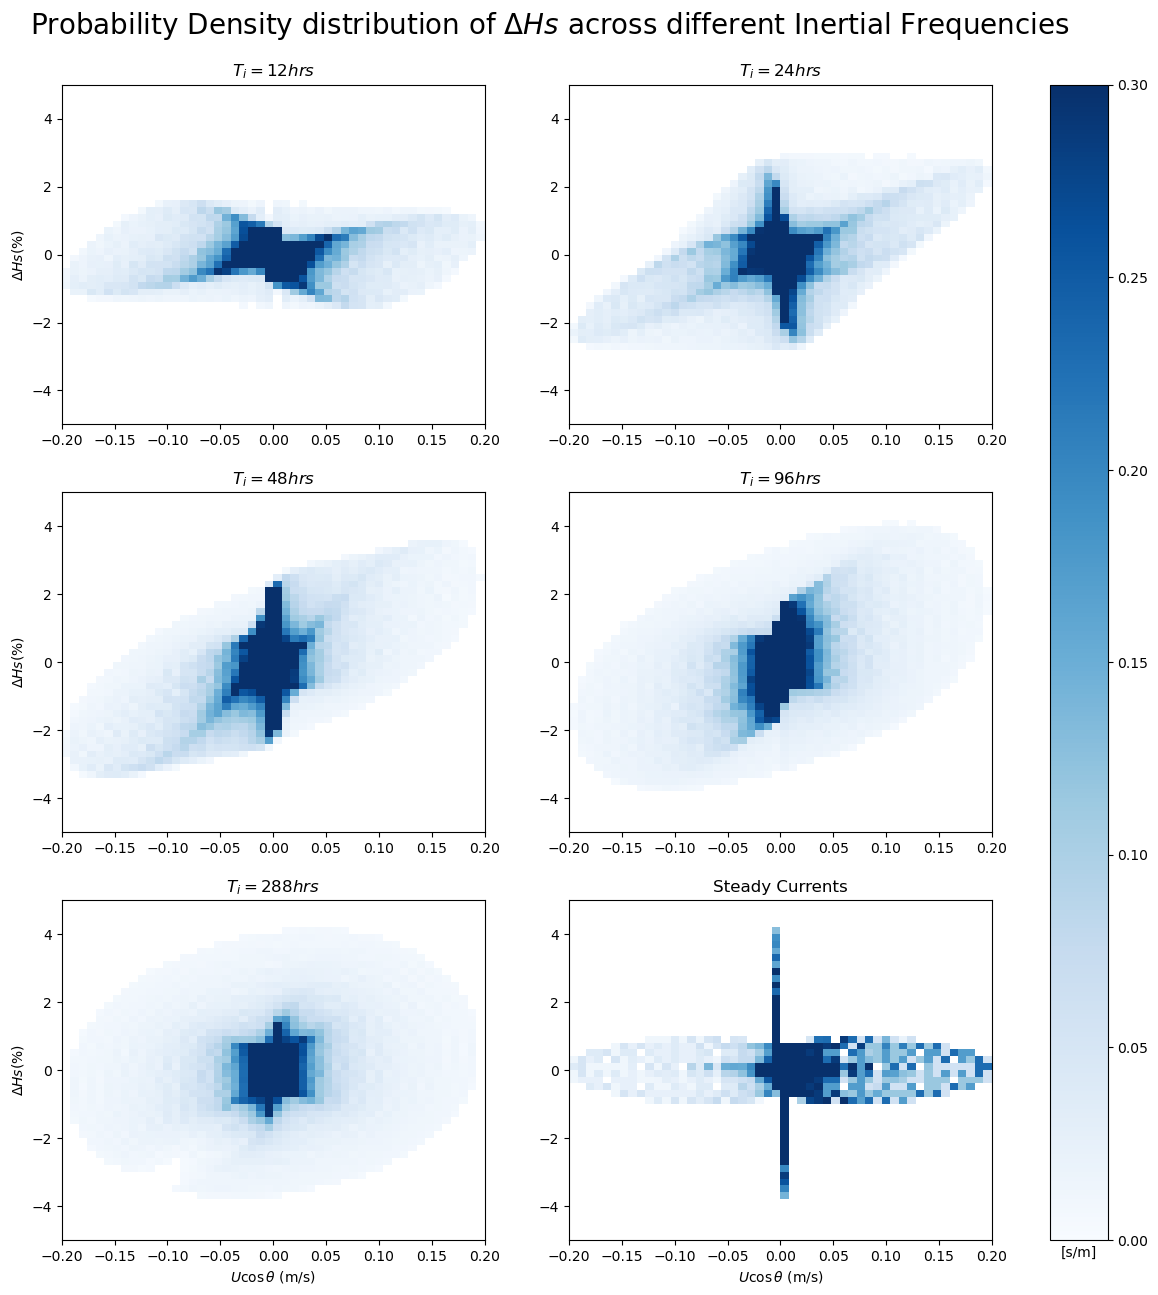

In [285]:
fig, ax = plt.subplots(3,2, figsize=(15, 15))
h, xed, yed, im = ax[0,0].hist2d(data12.vcur[500:, :, :].values.flatten(), anom12[500:, :, :].values.flatten(), density=True, bins=50, range=[[-0.2, 0.2], [-5, 5]], cmin=0.005, vmin=0, vmax=0.3, cmap='Blues')
h, xed, yed, im = ax[0,1].hist2d(data24.vcur[500:, :, :].values.flatten(), anom24[500:, :, :].values.flatten(), density=True, bins=50, range=[[-0.2, 0.2], [-5, 5]],cmin=0.005, vmin=0, vmax=0.3, cmap='Blues')
h, xed, yed, im = ax[1,0].hist2d(data48.vcur[500:, :, :].values.flatten(), anom48[500:, :, :].values.flatten(), density=True, bins=50, range=[[-0.2, 0.2], [-5, 5]], cmin=0.005, vmin=0, vmax=0.3, cmap='Blues')
h, xed, yed, im = ax[1,1].hist2d(data96.vcur[500:, :, :].values.flatten(), anom96[500:, :, :].values.flatten(), density=True, bins=50, range=[[-0.2, 0.2], [-5, 5]], cmin=0.005, vmin=0, vmax=0.3, cmap='Blues')
h, xed, yed, im = ax[2,0].hist2d(data288.vcur[500:, :, :].values.flatten(), anom288[500:, :, :].values.flatten(), density=True, bins=50, range=[[-0.2, 0.2], [-5, 5]], cmin=0.005, vmin=0, vmax=0.3, cmap='Blues')
h, xed, yed, im = ax[2,1].hist2d(vcur_steady, steady_anom, density=True, bins=50, range=[[-0.2, 0.2], [-5, 5]], cmin=0.01, vmin=0, vmax=0.3, cmap='Blues')

#Set xlabels
ax[2, 0].set_xlabel(r"$ U \cos\theta $ (m/s)")
ax[2, 1].set_xlabel(r"$ U \cos\theta $ (m/s)")
#Set ylabels
ax[0, 0].set_ylabel("$ \Delta Hs $(%)")
ax[1, 0].set_ylabel("$ \Delta Hs $(%)")
ax[2, 0].set_ylabel("$ \Delta Hs $(%)")
#set titles
ax[0,0].set_title("$T_i=12 hrs$")
ax[0,1].set_title("$T_i=24 hrs$")
ax[1,0].set_title("$T_i=48 hrs$")
ax[1,1].set_title("$T_i=96 hrs$")
ax[2,0].set_title("$T_i=288 hrs$")
ax[2,1].set_title("Steady Currents")

fig.suptitle("Probability Density distribution of $\Delta Hs$ across different Inertial Frequencies", fontsize=20, y=0.93, x=0.45)


#ax = ax.flatten()
#for i in range(len(ax)):
#    ax[i].plot(u_list, 2*theor_limit, '--r')
cbar= fig.colorbar(im, ax=ax)
cbar.ax.set_xlabel("[s/m]")


Text(0.5, 0, '[s/m]')

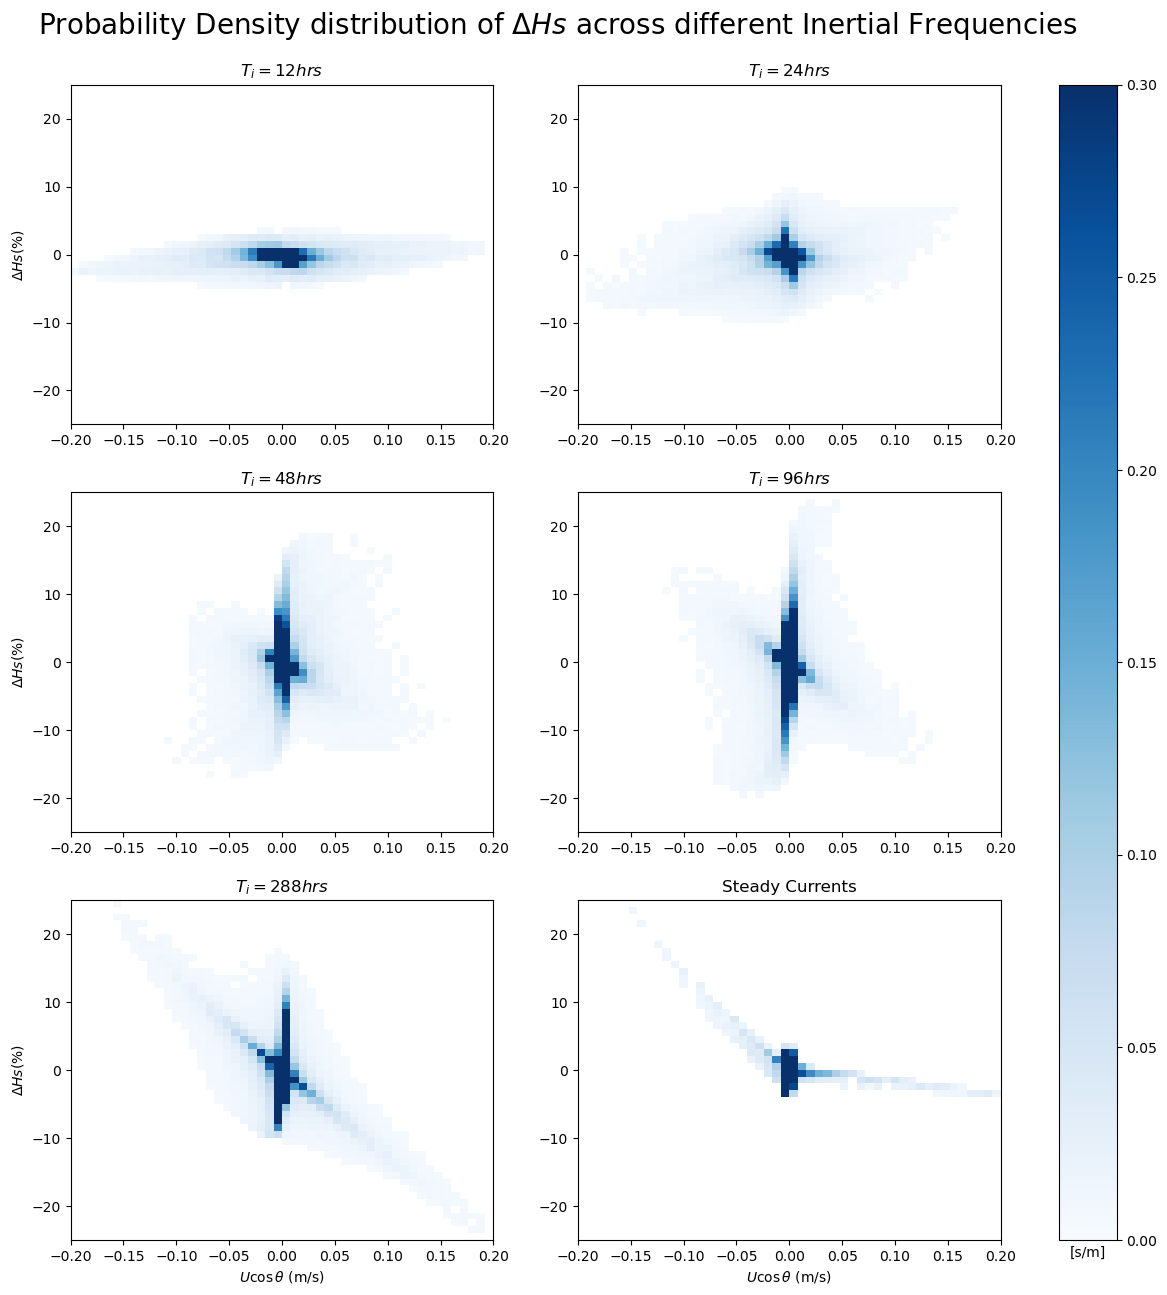

In [688]:
#Same but for mss
fig, ax = plt.subplots(3,2, figsize=(15, 15))
h, xed, yed, im = ax[0,0].hist2d(data12.ucur[500:, :, :].values.flatten(), anom12mss[500:, :, :].values.flatten(), density=True, bins=50, range=[[-0.2, 0.2], [-25, 25]], cmin=0.005, vmin=0, vmax=0.3, cmap='Blues')
h, xed, yed, im = ax[0,1].hist2d(data24.ucur[500:, :, :].values.flatten(), anom24mss[500:, :, :].values.flatten(), density=True, bins=50, range=[[-0.2, 0.2], [-25, 25]],cmin=0.005, vmin=0, vmax=0.3, cmap='Blues')
h, xed, yed, im = ax[1,0].hist2d(data48.ucur[500:, :, :].values.flatten(), anom48mss[500:, :, :].values.flatten(), density=True, bins=50, range=[[-0.2, 0.2], [-25, 25]], cmin=0.005, vmin=0, vmax=0.3, cmap='Blues')
h, xed, yed, im = ax[1,1].hist2d(data96.ucur[500:, :, :].values.flatten(), anom96mss[500:, :, :].values.flatten(), density=True, bins=50, range=[[-0.2, 0.2], [-25,25]], cmin=0.005, vmin=0, vmax=0.3, cmap='Blues')
h, xed, yed, im = ax[2,0].hist2d(data288.ucur[500:, :, :].values.flatten(), anom288mss[500:, :, :].values.flatten(), density=True, bins=50, range=[[-0.2, 0.2], [-25, 25]], cmin=0.005, vmin=0, vmax=0.3, cmap='Blues')
h, xed, yed, im = ax[2,1].hist2d(ucur_steady, steady_anommss, density=True, bins=50, range=[[-0.2, 0.2], [-25, 25]], cmin=0.01, vmin=0, vmax=0.3, cmap='Blues')

#Set xlabels
ax[2, 0].set_xlabel(r"$ U \cos\theta $ (m/s)")
ax[2, 1].set_xlabel(r"$ U \cos\theta $ (m/s)")
#Set ylabels
ax[0, 0].set_ylabel("$ \Delta Hs $(%)")
ax[1, 0].set_ylabel("$ \Delta Hs $(%)")
ax[2, 0].set_ylabel("$ \Delta Hs $(%)")
#set titles
ax[0,0].set_title("$T_i=12 hrs$")
ax[0,1].set_title("$T_i=24 hrs$")
ax[1,0].set_title("$T_i=48 hrs$")
ax[1,1].set_title("$T_i=96 hrs$")
ax[2,0].set_title("$T_i=288 hrs$")
ax[2,1].set_title("Steady Currents")

fig.suptitle("Probability Density distribution of $\Delta Hs$ across different Inertial Frequencies", fontsize=20, y=0.93, x=0.45)


#ax = ax.flatten()
#for i in range(len(ax)):
#    ax[i].plot(u_list, 2*theor_limit, '--r')
cbar= fig.colorbar(im, ax=ax)
cbar.ax.set_xlabel("[s/m]")


Text(0.5, 0, '[s/m]')

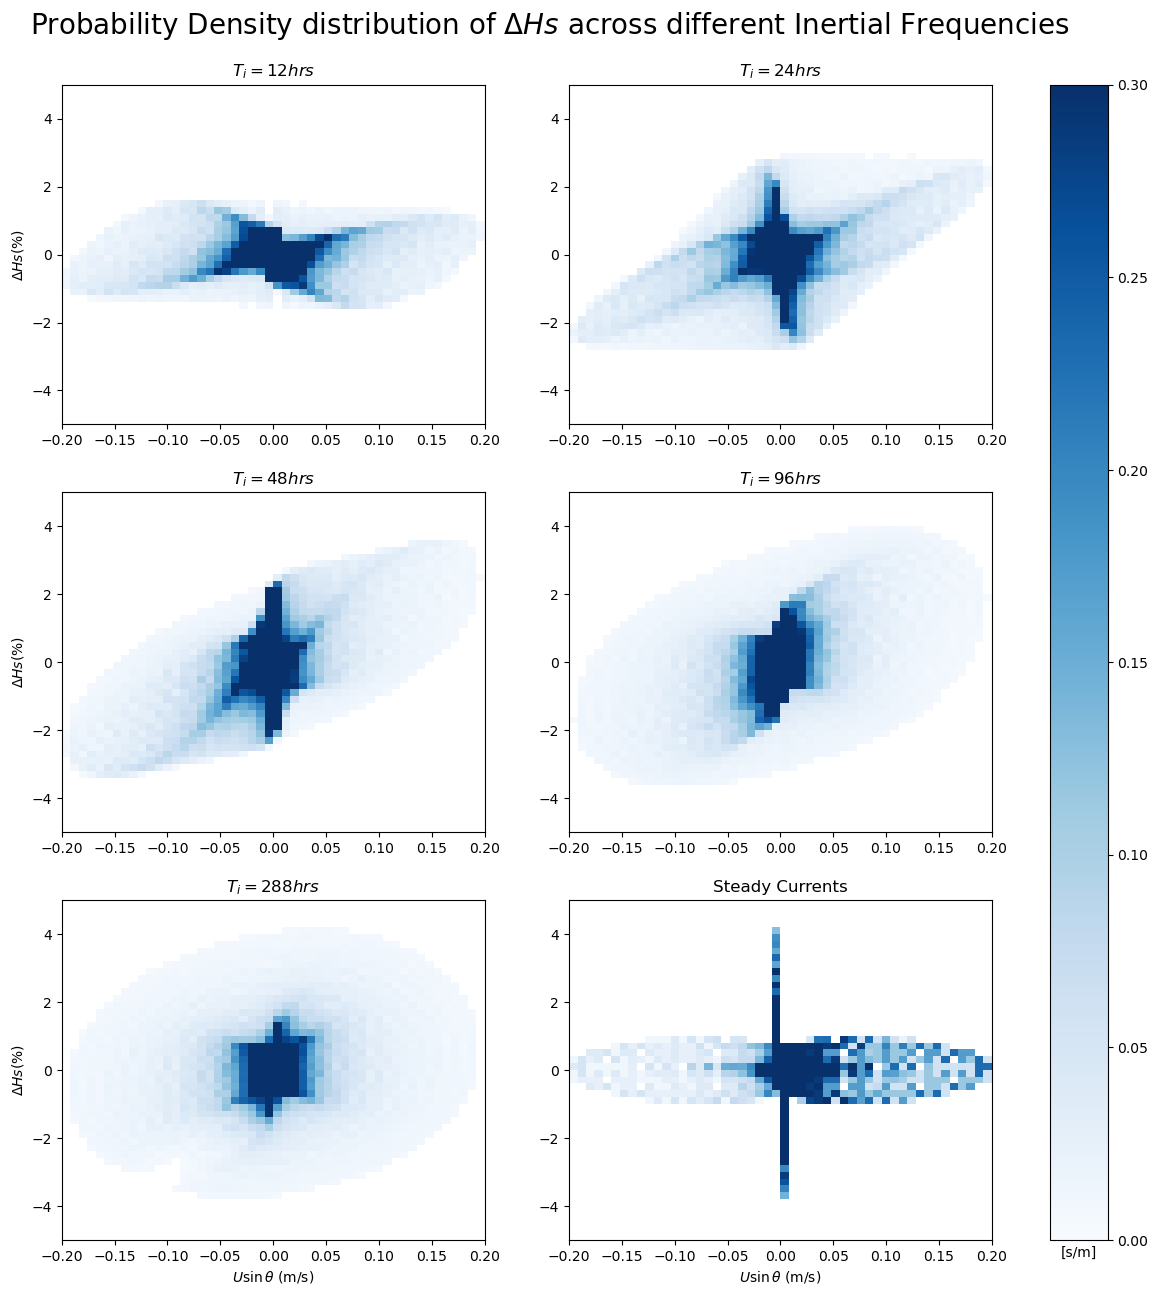

In [680]:
#Now for vcur?
fig, ax = plt.subplots(3,2, figsize=(15, 15))
h, xed, yed, im = ax[0,0].hist2d(data12.vcur[500:, :, :].values.flatten(), anom12[500:, :, :].values.flatten(), density=True, bins=50, range=[[-0.2, 0.2], [-5, 5]], cmin=0.005, vmin=0, vmax=0.3, cmap='Blues')
h, xed, yed, im = ax[0,1].hist2d(data24.vcur[500:, :, :].values.flatten(), anom24[500:, :, :].values.flatten(), density=True, bins=50, range=[[-0.2, 0.2], [-5, 5]],cmin=0.005, vmin=0, vmax=0.3, cmap='Blues')
h, xed, yed, im = ax[1,0].hist2d(data48.vcur[500:, :, :].values.flatten(), anom48[500:, :, :].values.flatten(), density=True, bins=50, range=[[-0.2, 0.2], [-5, 5]], cmin=0.005, vmin=0, vmax=0.3, cmap='Blues')
h, xed, yed, im = ax[1,1].hist2d(data96.vcur[500:, :, :].values.flatten(), anom96[500:, :, :].values.flatten(), density=True, bins=50, range=[[-0.2, 0.2], [-5, 5]], cmin=0.005, vmin=0, vmax=0.3, cmap='Blues')
h, xed, yed, im = ax[2,0].hist2d(data288.vcur[500:, :, :].values.flatten(), anom288[500:, :, :].values.flatten(), density=True, bins=50, range=[[-0.2, 0.2], [-5, 5]], cmin=0.005, vmin=0, vmax=0.3, cmap='Blues')
h, xed, yed, im = ax[2,1].hist2d(vcur_steady, steady_anom, density=True, bins=50, range=[[-0.2, 0.2], [-5, 5]], cmin=0.01, vmin=0, vmax=0.3, cmap='Blues')

#Set xlabels
ax[2, 0].set_xlabel(r"$ U \sin\theta $ (m/s)")
ax[2, 1].set_xlabel(r"$ U \sin\theta $ (m/s)")
#Set ylabels
ax[0, 0].set_ylabel("$ \Delta Hs $(%)")
ax[1, 0].set_ylabel("$ \Delta Hs $(%)")
ax[2, 0].set_ylabel("$ \Delta Hs $(%)")
#set titles
ax[0,0].set_title("$T_i=12 hrs$")
ax[0,1].set_title("$T_i=24 hrs$")
ax[1,0].set_title("$T_i=48 hrs$")
ax[1,1].set_title("$T_i=96 hrs$")
ax[2,0].set_title("$T_i=288 hrs$")
ax[2,1].set_title("Steady Currents")

fig.suptitle("Probability Density distribution of $\Delta Hs$ across different Inertial Frequencies", fontsize=20, y=0.93, x=0.45)


#ax = ax.flatten()
#for i in range(len(ax)):
#    ax[i].plot(u_list, 2*theor_limit, '--r')
cbar= fig.colorbar(im, ax=ax)
cbar.ax.set_xlabel("[s/m]")


## Do the same except for current gradients

Where du/dx < 0, the currents are increasingly against the waves as they move to the east

In [418]:
#Need to get xkm, ykm to get gradients
xm = np.linspace(-haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, haversine((0, -150), (0, -140), unit=Unit.METERS)/2, len(data12.longitude))
ym = np.linspace(-haversine((-5, -145), (5, -145), unit=Unit.KILOMETERS)/2, haversine((-5, -145), (5, -140), unit=Unit.METERS)/2, len(data12.latitude))

wgradw = 1*np.gradient(steadyw.ucur[500:, :, :].values, xm, axis=2)
wgrade = 1*np.gradient(steadye.ucur[500:, :, :].values, xm, axis=2)
wgradn = 1*np.gradient(steadyn.ucur[500:, :, :].values, xm, axis=2)
wgrads = 1*np.gradient(steadys.ucur[500:, :, :].values, xm, axis=2)

data12_ux = 1*np.gradient(data12.ucur[500:, :, :].values, xm, axis=2)
data24_ux = 1*np.gradient(data24.ucur[500:, :, :].values, xm, axis=2)
data48_ux = 1*np.gradient(data48.ucur[500:, :, :].values, xm, axis=2)
data96_ux = 1*np.gradient(data96.ucur[500:, :, :].values, xm, axis=2)
data288_ux = 1*np.gradient(data288.ucur[500:, :, :].values, xm, axis=2)

ux_steady = np.append(wgradw.flatten(),wgrade.flatten())
ux_steady = np.append(ux_steady, wgradn.flatten())
ux_steady = np.append(ux_steady, wgrads.flatten())

Text(0.5, 0, '[s/m]')

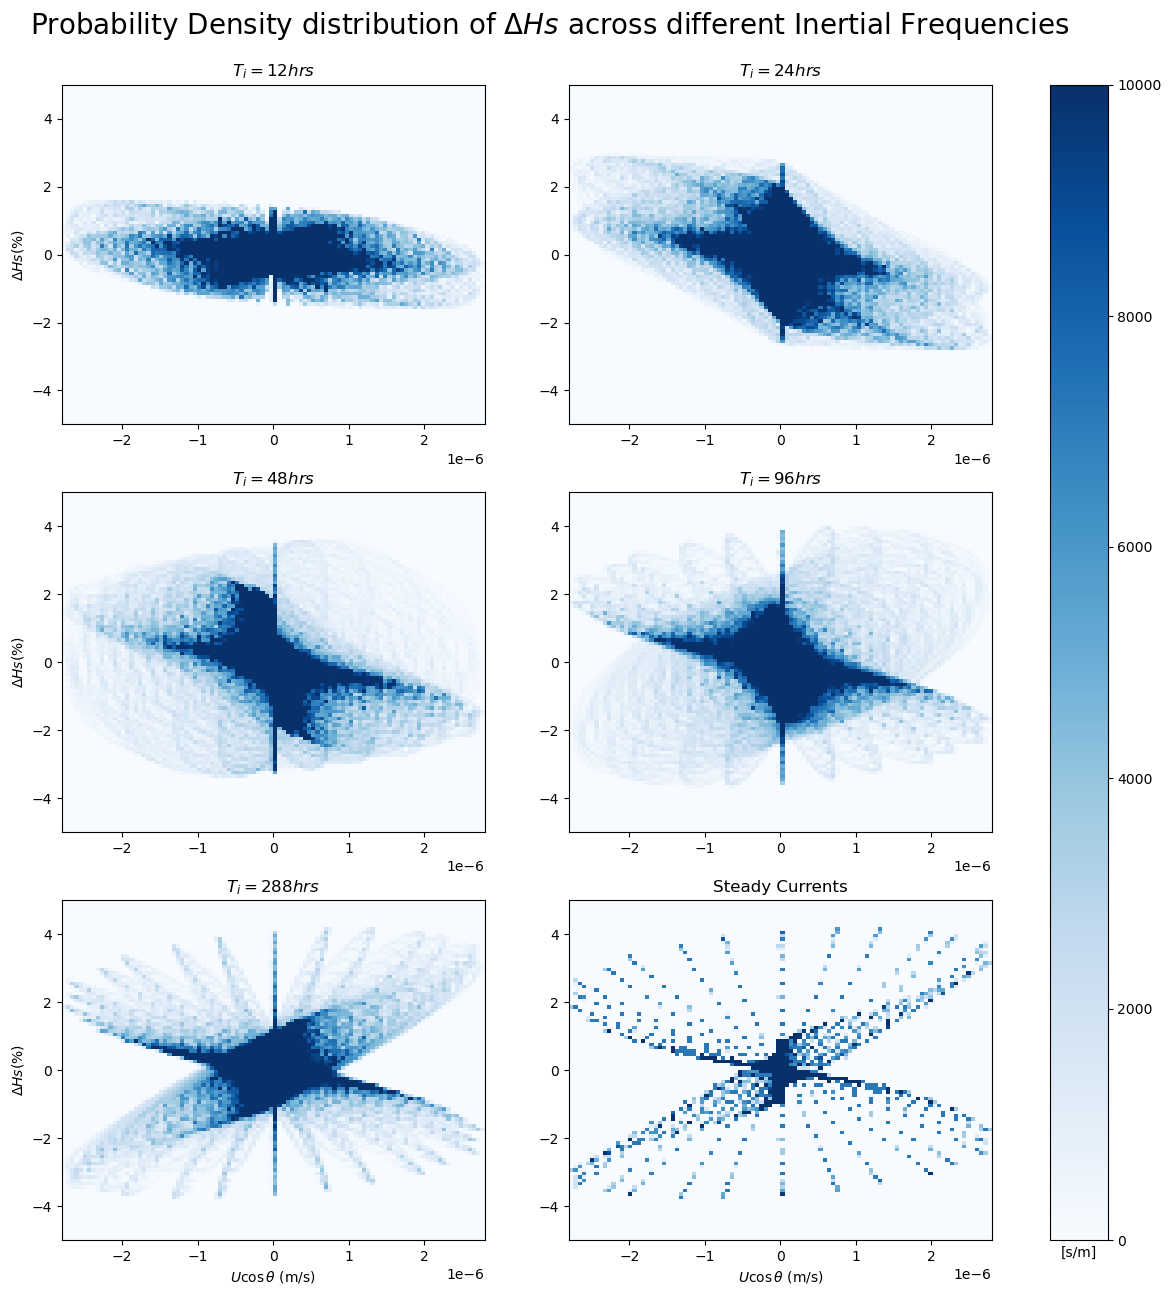

In [419]:
fig, ax = plt.subplots(3,2, figsize=(15, 15))
h, xed, yed, im = ax[0,0].hist2d(data12_ux.flatten(), anom12[500:, :, :].values.flatten(), density=True, bins=100, range=[[-2.8*10**-6, 2.8*10**-6], [-5, 5]], vmin=0, vmax=0.1*10**5, cmap='Blues')
h, xed, yed, im = ax[0,1].hist2d(data24_ux.flatten(), anom24[500:, :, :].values.flatten(), density=True, bins=100, range=[[-2.8*10**-6, 2.8*10**-6], [-5, 5]], vmin=0, vmax=0.1*10**5, cmap='Blues')
h, xed, yed, im = ax[1,0].hist2d(data48_ux.flatten(), anom48[500:, :, :].values.flatten(), density=True, bins=100, range=[[-2.8*10**-6, 2.8*10**-6], [-5, 5]], vmin=0, vmax=0.1*10**5, cmap='Blues')
h, xed, yed, im = ax[1,1].hist2d(data96_ux.flatten(), anom96[500:, :, :].values.flatten(), density=True, bins=100, range=[[-2.8*10**-6, 2.8*10**-6], [-5, 5]], vmin=0, vmax=0.1*10**5, cmap='Blues')
h, xed, yed, im = ax[2,0].hist2d(data288_ux.flatten(), anom288[500:, :, :].values.flatten(), density=True, bins=100, range=[[-2.8*10**-6, 2.8*10**-6], [-5, 5]], vmin=0, vmax=0.1*10**5, cmap='Blues')
h, xed, yed, im = ax[2,1].hist2d(ux_steady, steady_anom, density=True, bins=100, range=[[-2.8*10**-6, 2.8*10**-6], [-5, 5]], vmin=0, vmax=0.1*10**5, cmap='Blues')

#Set xlabels
ax[2, 0].set_xlabel(r"$ U \cos\theta $ (m/s)")
ax[2, 1].set_xlabel(r"$ U \cos\theta $ (m/s)")
#Set ylabels
ax[0, 0].set_ylabel("$ \Delta Hs $(%)")
ax[1, 0].set_ylabel("$ \Delta Hs $(%)")
ax[2, 0].set_ylabel("$ \Delta Hs $(%)")
#set titles
ax[0,0].set_title("$T_i=12 hrs$")
ax[0,1].set_title("$T_i=24 hrs$")
ax[1,0].set_title("$T_i=48 hrs$")
ax[1,1].set_title("$T_i=96 hrs$")
ax[2,0].set_title("$T_i=288 hrs$")
ax[2,1].set_title("Steady Currents")

fig.suptitle("Probability Density distribution of $\Delta Hs$ across different Inertial Frequencies", fontsize=20, y=0.93, x=0.45)


#ax = ax.flatten()
#for i in range(len(ax)):
#    ax[i].plot(u_list, 2*theor_limit, '--r')
cbar= fig.colorbar(im, ax=ax)
cbar.ax.set_xlabel("[s/m]")


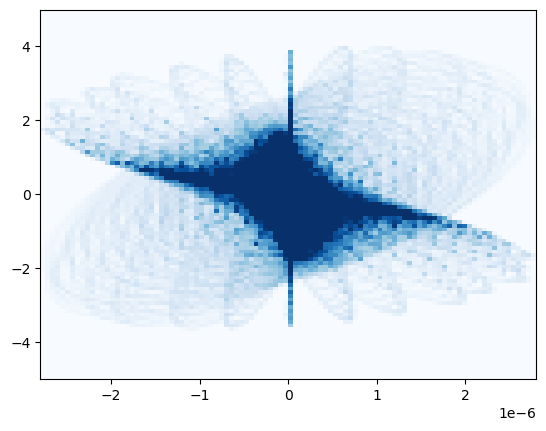

In [414]:
h, xed, yed, im = plt.hist2d(data96_ux.flatten(), anom96[500:, :, :].values.flatten(), density=True, bins=100, range=[[-2.8*10**-6, 2.8*10**-6], [-5, 5]], vmin=0, vmax=0.1*10**5, cmap='Blues')